<a href="https://colab.research.google.com/github/hawa1983/Capstone-Final-Modeling-and-Data/blob/main/dow_ridership_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond the Weekday/Weekend Binary
## Day-of-Week Demand Regimes in the Post-Telework Era: Evidence from NYC Subway Turnstile Data

**Author:** Fomba Kassoh  
**Target Journal:** Transportation Research Record (TRR)  
**Date:** 2026

### Project Overview

This notebook implements the full analytical pipeline for the TRR publication examining how telework-driven behavioral change has disrupted the traditional weekday/weekend demand binary in the NYC subway system. The analysis proceeds in five stages:

1. **Data Acquisition** — MTA Turnstile data (2019, 2022, 2024) + built environment variables
2. **Data Processing** — Cleaning, aggregation, and 7-day ridership vector construction
3. **Exploratory Analysis** — Descriptive statistics and day-of-week profile visualization
4. **Cluster Analysis** — K-means typology of station demand regimes
5. **Regression Analysis** — Multinomial logistic regression explaining cluster membership

### Research Objectives
- Empirically characterize 7-day ridership profiles at NYC subway stations across three temporal periods
- Identify K-means demand regime clusters that transcend the weekday/weekend binary
- Explain cluster membership using built environment and land use variables
- Derive scheduling implications for MTA service planning

---
## SECTION 0: Environment Setup
Install all required libraries and configure global settings.

In [147]:
# ==============================================================
# Section 0.1 — Install Dependencies
# ==============================================================
# Run this cell once if working in Google Colab or a fresh environment.
# Comment out if packages are already installed.

!pip install pandas numpy scikit-learn matplotlib seaborn geopandas \
             scipy statsmodels requests tqdm plotly --quiet

In [148]:
# ==============================================================
# Section 0.2 — Import Libraries
# ==============================================================

from __future__ import annotations

import os
import re
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [149]:
# ==============================================================
# Section 0.2b — Google Colab: Mount Google Drive
# ==============================================================

from pathlib import Path

USE_DRIVE = True        # Set False if running locally

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
else:
    OUT_DIR = Path("./outputs")   # local fallback

OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUT_DIR}")
print(f"Drive mounted: {USE_DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/dow_ridership_paper/outputs
Drive mounted: True


In [150]:
# ==============================================================
# Section 0.3 — Global Configuration
# ==============================================================
# Central config block — modify here, not scattered through the notebook.

import matplotlib.pyplot as plt

# ---- Study periods ----
PERIODS = {
    "precovid": {
        "label": "Pre-COVID Baseline",
        "years": [2017, 2018, 2019],
        "baseline_file": "station_daily_precovid_avg.csv",
    },
    "2022": {
        "label": "Early Recovery",
        "year": 2022,
    },
    "2024": {
        "label": "Stabilized New Normal",
        "year": 2024,
    },
}

# ---- Days of week (Mon=0, Sun=6) ----
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
DOW_MAP = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

# ---- K-means ----
K_RANGE = range(2, 9)   # sweep K=2..8
K_FINAL = 5             # update after elbow/silhouette analysis
KMEANS_SEED = 42
KMEANS_INIT = 10        # number of random initializations

# ---- Catchment radius for built environment join ----
CATCHMENT_MILES = 0.5

# ---- Plot style ----
PALETTE = ["#1F5C99", "#E8702A", "#2E9E4F", "#C03B2B", "#7B4EA0"]

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Configuration complete.")

Configuration complete.


---
## SECTION 1: Data Acquisition

### 1.1 MTA Turnstile Data

The MTA publishes weekly turnstile data at `data.ny.gov`. Each row represents cumulative entries and exits for a single turnstile unit over a ~4-hour audit interval.

**Key fields:** `C/A` (control area), `UNIT`, `SCP` (subunit/channel/position), `STATION`, `LINENAME`, `DATE`, `TIME`, `ENTRIES`, `EXITS`

**Strategy:** Download all weekly files for calendar years 2019, 2022, and 2024, compute net entries per turnstile per audit period (handling counter resets), aggregate to station-day level, and then to station × day-of-week averages.

**Note on station naming:** The MTA turnstile `STATION` field does not map 1:1 to station complexes. The crosswalk from station name → station complex ID is handled in Section 2.

In [151]:
# ==============================================================
# Replacement Section — Pre-COVID Baseline from Data.NY.gov
# Uses annual archived turnstile datasets instead of old weekly MTA files
# ==============================================================

import time
import datetime
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests
from tqdm import tqdm


# -------------------------------------------------------
# OUTPUT LOCATION
# -------------------------------------------------------

OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "raw_turnstile").mkdir(exist_ok=True)

DOW_MAP = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PRE_COVID_YEARS = [2017, 2018, 2019]

# Official Data.NY.gov annual archived datasets
DATA_NY_DATASET_IDS = {
    2017: "v5y5-mwpb",
    2018: "bjcb-yee3",
    2019: "xfn5-qji9",
}

TURNSTILE_REQUIRED_COLS = {
    "C/A",
    "Unit",
    "SCP",
    "Station",
    "Date",
    "Time",
    "Entries",
}


# -------------------------------------------------------
# DOWNLOAD ANNUAL CSV FROM DATA.NY.GOV
# -------------------------------------------------------

def download_year_csv(year: int) -> Path:
    """
    Download annual archived turnstile CSV from Data.NY.gov.
    Saves one raw file per year:
        raw_turnstile/turnstile_2017.csv
        raw_turnstile/turnstile_2018.csv
        raw_turnstile/turnstile_2019.csv
    """
    dataset_id = DATA_NY_DATASET_IDS[year]
    url = f"https://data.ny.gov/api/views/{dataset_id}/rows.csv?accessType=DOWNLOAD"

    cache_f = OUT_DIR / "raw_turnstile" / f"turnstile_{year}.csv"

    if cache_f.exists() and cache_f.stat().st_size > 1_000_000:
        print(f"  {year}: raw annual CSV already cached: {cache_f}")
        return cache_f

    print(f"\n  {year}: downloading annual CSV from Data.NY.gov...")
    print(f"  URL: {url}")

    headers = {"User-Agent": "Mozilla/5.0"}

    with requests.get(url, headers=headers, stream=True, timeout=120) as r:
        if r.status_code != 200:
            raise RuntimeError(f"{year}: download failed with HTTP {r.status_code}")

        total = int(r.headers.get("content-length", 0))

        with open(cache_f, "wb") as f:
            if total > 0:
                pbar = tqdm(total=total, unit="B", unit_scale=True, desc=f"  {year}")
            else:
                pbar = None

            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    if pbar is not None:
                        pbar.update(len(chunk))

            if pbar is not None:
                pbar.close()

    # Validate columns
    test = pd.read_csv(cache_f, nrows=5, low_memory=False)
    test.columns = test.columns.str.strip()

    missing = TURNSTILE_REQUIRED_COLS - set(test.columns)
    if missing:
        raise RuntimeError(
            f"{year}: downloaded CSV is missing required columns: {missing}\n"
            f"Columns found: {list(test.columns)}"
        )

    print(f"  {year}: download complete and validated.")
    return cache_f


# -------------------------------------------------------
# BUILD STATION-DAILY PER YEAR
# -------------------------------------------------------

def build_station_daily(year: int, chunk_size: int = 750_000) -> pd.DataFrame:
    """
    Build station × date daily entries for one year.

    Uses annual Data.NY.gov CSV instead of weekly MTA text files.
    Handles the large annual files in chunks, then sorts once before diffing.
    """
    cache_out = OUT_DIR / f"station_daily_{year}.csv"

    if cache_out.exists():
        df = pd.read_csv(cache_out, parse_dates=["date"])
        print(
            f"  {year}: loaded station_daily cache — "
            f"{df['station_name'].nunique()} stations | "
            f"{df['date'].nunique()} days | "
            f"{len(df):,} rows"
        )
        return df

    raw_csv = download_year_csv(year)

    print(f"\n  {year}: reading annual CSV in chunks...")

    keep_cols = [
        "C/A",
        "Unit",
        "SCP",
        "Station",
        "Date",
        "Time",
        "Entries",
    ]

    frames = []

    reader = pd.read_csv(
        raw_csv,
        usecols=keep_cols,
        chunksize=chunk_size,
        low_memory=False,
    )

    for chunk in tqdm(reader, desc=f"  {year} chunks"):
        chunk.columns = chunk.columns.str.strip()

        chunk["DATETIME"] = pd.to_datetime(
            chunk["Date"].astype(str).str.strip() + " " +
            chunk["Time"].astype(str).str.strip(),
            format="%m/%d/%Y %H:%M:%S",
            errors="coerce",
        )

        chunk = chunk.dropna(subset=["DATETIME"])
        chunk = chunk[chunk["DATETIME"].dt.year == year].copy()

        if len(chunk) == 0:
            continue

        chunk["Entries"] = pd.to_numeric(chunk["Entries"], errors="coerce")
        chunk = chunk.dropna(subset=["Entries"])

        frames.append(
            chunk[
                [
                    "C/A",
                    "Unit",
                    "SCP",
                    "Station",
                    "DATETIME",
                    "Entries",
                ]
            ]
        )

    if not frames:
        raise RuntimeError(f"{year}: no valid records after reading annual CSV.")

    raw = pd.concat(frames, ignore_index=True)
    print(f"    Raw rows before cleaning: {len(raw):,}")

    # Sort within each physical turnstile
    unit_key = ["C/A", "Unit", "SCP"]

    raw = raw.sort_values(unit_key + ["DATETIME"]).reset_index(drop=True)

    # Compute net entries from cumulative counter
    raw["net_entries"] = (
        raw.groupby(unit_key)["Entries"]
           .diff()
           .clip(lower=0, upper=10_000)
           .fillna(0)
    )

    # Date and DOW
    raw["date"] = raw["DATETIME"].dt.normalize()
    raw["dow"] = raw["DATETIME"].dt.dayofweek
    raw["dow_label"] = raw["dow"].map(DOW_MAP)

    # Exclusion flags from your existing code
    raw["date_str"] = raw["date"].dt.strftime("%Y-%m-%d")
    raw["month_day"] = list(zip(raw["date"].dt.month, raw["date"].dt.day))

    holiday_mask = raw["month_day"].isin(HOLIDAY_MD)
    event_mask = raw["date_str"].isin(EXCLUDE_DATES)

    excluded = int((holiday_mask | event_mask).sum())

    raw = raw[~(holiday_mask | event_mask)].drop(
        columns=["date_str", "month_day"]
    ).copy()

    print(f"    Rows removed by exclusion flags: {excluded:,}")
    print(f"    Rows after exclusions:           {len(raw):,}")

    # Aggregate to station × date
    daily = (
        raw.groupby(["Station", "date", "dow", "dow_label"])["net_entries"]
           .sum()
           .reset_index()
           .rename(columns={"Station": "station_name"})
    )

    daily.to_csv(cache_out, index=False)

    print(
        f"    Final: {daily['station_name'].nunique()} stations | "
        f"{daily['date'].nunique()} days | "
        f"{len(daily):,} rows"
    )

    return daily


# -------------------------------------------------------
# BUILD 3-YEAR PRE-COVID AVERAGE
# -------------------------------------------------------

def build_precovid_average(cleaned: dict) -> pd.DataFrame:
    """
    Build 3-year averaged pre-COVID baseline:
    station × day-of-week mean entries across 2017, 2018, 2019.
    """
    cache_out = OUT_DIR / "station_daily_precovid_avg.csv"

    if cache_out.exists():
        df = pd.read_csv(cache_out)
        print(
            f"\nPre-COVID average: loaded from cache — "
            f"{df['station_name'].nunique()} stations | "
            f"{len(df):,} rows"
        )
        return df

    frames = []

    for yr in PRE_COVID_YEARS:
        if yr not in cleaned:
            print(f"  Warning: {yr} missing from cleaned dict — skipping")
            continue

        dow_agg = (
            cleaned[yr]
            .groupby(["station_name", "dow", "dow_label"])["net_entries"]
            .mean()
            .reset_index()
            .rename(columns={"net_entries": f"mean_entries_{yr}"})
        )

        frames.append(
            dow_agg.set_index(["station_name", "dow", "dow_label"])
        )

    if not frames:
        raise RuntimeError("No pre-COVID years available.")

    combined = frames[0]

    for f in frames[1:]:
        combined = combined.join(f, how="outer")

    combined = combined.reset_index()

    yr_cols = [
        f"mean_entries_{yr}"
        for yr in PRE_COVID_YEARS
        if f"mean_entries_{yr}" in combined.columns
    ]

    combined["mean_entries_precovid"] = combined[yr_cols].mean(
        axis=1,
        skipna=True,
    )

    combined["n_years_available"] = combined[yr_cols].notna().sum(axis=1)

    n_partial = int((combined["n_years_available"] < 3).sum())

    combined.to_csv(cache_out, index=False)

    print("\nPre-COVID 3-year average built:")
    print(f"  Stations:        {combined['station_name'].nunique()}")
    print(f"  DOW rows:        {len(combined):,}")
    print(f"  Full 3-yr rows:  {(combined['n_years_available'] == 3).sum():,}")
    print(f"  Partial rows:    {n_partial:,}")

    print("\nSample Monday high-volume stations:")
    sample = (
        combined[combined["dow_label"] == "Mon"]
        .nlargest(5, "mean_entries_precovid")
        [
            [
                "station_name",
                "dow_label",
                "mean_entries_precovid",
                "n_years_available",
            ]
        ]
    )

    print(sample.to_string(index=False))

    return combined


# -------------------------------------------------------
# RUN
# -------------------------------------------------------

print("\n" + "=" * 55)
print("Building pre-COVID baseline from Data.NY.gov: 2017, 2018, 2019")
print("=" * 55)

cleaned = {}

for yr in PRE_COVID_YEARS:
    cleaned[yr] = build_station_daily(yr)

print("\n" + "=" * 55)
print("Computing 3-year pre-COVID DOW average...")
print("=" * 55)

precovid_avg = build_precovid_average(cleaned)


# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------

print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)

for yr in PRE_COVID_YEARS:
    df = cleaned[yr]

    n_st = df["station_name"].nunique()
    n_day = df["date"].nunique()
    n_rows = len(df)

    dow_counts = df.groupby("dow")["date"].nunique()
    min_days = dow_counts.min()
    max_days = dow_counts.max()

    print(f"\n  cleaned[{yr}]:")
    print(f"    Stations:          {n_st}")
    print(f"    Calendar days:     {n_day}")
    print(f"    Station-day rows:  {n_rows:,}")
    print(f"    DOW day range:     {min_days}–{max_days} days per DOW")

print("\n  precovid_avg:")
print(f"    Stations:     {precovid_avg['station_name'].nunique()}")
print(f"    Total rows:   {len(precovid_avg):,}")

print(f"\nAll files saved to: {OUT_DIR}")


Building pre-COVID baseline from Data.NY.gov: 2017, 2018, 2019
  2017: loaded station_daily cache — 380 stations | 247 days | 92,356 rows
  2018: loaded station_daily cache — 379 stations | 315 days | 117,701 rows
  2019: loaded station_daily cache — 379 stations | 285 days | 107,522 rows

Computing 3-year pre-COVID DOW average...

Pre-COVID average: loaded from cache — 381 stations | 2,662 rows

SUMMARY

  cleaned[2017]:
    Stations:          380
    Calendar days:     247
    Station-day rows:  92,356
    DOW day range:     34–36 days per DOW

  cleaned[2018]:
    Stations:          379
    Calendar days:     315
    Station-day rows:  117,701
    DOW day range:     39–48 days per DOW

  cleaned[2019]:
    Stations:          379
    Calendar days:     285
    Station-day rows:  107,522
    DOW day range:     37–44 days per DOW

  precovid_avg:
    Stations:     381
    Total rows:   2,662

All files saved to: /content/drive/MyDrive/dow_ridership_paper/outputs


### 1.2 MTA Station Complex Crosswalk

The `STATION` field in turnstile data uses MTA-internal names that do not align perfectly with official station complex IDs. We use the MTA's published station complexes file to map turnstile station names → station complex IDs, enabling consistent spatial joins with ACS and land use data.

In [152]:
# ==============================================================
# Section 1.2 — Station Complex Crosswalk
#
# Purpose:
#   Loads the MTA Subway Stations and Complexes file and
#   constructs a crosswalk between turnstile STATION names
#   and official station_complex_id values.
#
# Source: MTA Open Data / data.ny.gov
#   "MTA Subway Stations and Complexes"
#
# Output:
#   station_crosswalk_df: DataFrame with columns
#     [station_name, station_complex_id, complex_name,
#      borough, daytime_routes, complex_latitude, complex_longitude]
# ==============================================================

STATION_COMPLEX_URL = (
    "https://data.ny.gov/api/views/i9wp-a4ja/rows.csv?accessType=DOWNLOAD"
)


def load_station_complexes(url: str) -> pd.DataFrame:
    """
    Download the MTA station complexes file and return a clean DataFrame.
    """
    cache = OUT_DIR / "mta_station_complexes.csv"
    if cache.exists():
        df = pd.read_csv(cache)
    else:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        df = pd.read_csv(StringIO(resp.text))
        df.to_csv(cache, index=False)

    # Standardize column names to snake_case
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r"[\s/]+", "_", regex=True)
    )
    print(f"Station complexes loaded: {len(df):,} rows")
    print("Columns:", list(df.columns[:10]))
    return df


station_complex_df = load_station_complexes(STATION_COMPLEX_URL)

# ---- Preview ----
station_complex_df.head(3)

Station complexes loaded: 445 rows
Columns: ['complex_id', 'is_complex', 'number_of_stations_in_complex', 'stop_name', 'display_name', 'constituent_station_names', 'station_ids', 'gtfs_stop_ids', 'borough', 'cbd']


,complex_id,is_complex,number_of_stations_in_complex,stop_name,display_name,constituent_station_names,station_ids,gtfs_stop_ids,borough,cbd,daytime_routes,structure_type,latitude,longitude,ada,ada_notes
0,398,False,1,77 St,77 St (6),77 St,398,627,M,False,6,Subway,40.77,-73.96,0,NaN
1,399,False,1,68 St-Hunter College,68 St-Hunter College (6),68 St-Hunter College,399,628,M,False,6,Subway,40.77,-73.96,1,NaN
2,403,False,1,33 St,33 St (6),33 St,403,632,M,True,6,Subway,40.75,-73.98,0,NaN


### 1.3 Built Environment Data

We collect three categories of built environment variables:
- **ACS (Census):** Population density, median household income, vehicle ownership, commute mode share — aggregated to 0.5-mile station buffer
- **LEHD/LODES:** Job counts by sector (office vs. essential vs. retail) within 0.5-mile buffer
- **MTA Metadata:** ADA accessibility, structure type (elevated/underground), borough

In [153]:
# ==============================================================
# Section 1.3a — ACS Block Group Built-Environment Data
#
# Purpose:
#   Fetches ACS 5-year block group data for NYC counties.
#
# Variables:
#   total_population      — B01003_001E
#   total_households      — B25044_001E
#   no_vehicle_hh         — B25044_003E + B25044_010E
#   median_hh_income      — B19013_001E
#   total_commuters       — B08301_001E
#   transit_commuters     — B08301_010E
#
# Notes:
#   B25044 is used for vehicle availability by tenure.
#   no_vehicle_hh = owner-occupied no vehicle + renter-occupied no vehicle.
#
# Outputs:
#   acs_bg_2019.csv
#   acs_bg_2022.csv
# ==============================================================

import pandas as pd
import numpy as np
import requests
from pathlib import Path


# -------------------------------------------------------
# Required setup
# -------------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the key you already pasted earlier.
# Do not print the key.
if "CENSUS_API_KEY" not in globals():
    CENSUS_API_KEY = None


# -------------------------------------------------------
# ACS year mapping
# -------------------------------------------------------
# 2024 built-environment features use ACS 2022 because ACS 2024
# block-group 5-year data may not be available or consistent yet.

ACS_YEAR_MAP = {
    2019: 2019,
    2022: 2022,
    2024: 2022,
}

ACS_YEARS_TO_FETCH = sorted(set(ACS_YEAR_MAP.values()))


# -------------------------------------------------------
# NYC county FIPS codes
# -------------------------------------------------------

NYC_COUNTIES = {
    "061": "Manhattan",
    "005": "Bronx",
    "047": "Brooklyn",
    "081": "Queens",
    "085": "Staten Island",
}


# -------------------------------------------------------
# ACS variable mapping
# -------------------------------------------------------

ACS_VARS = {
    "B01003_001E": "total_population",
    "B25044_001E": "total_households",
    "B25044_003E": "owner_no_vehicle_hh",
    "B25044_010E": "renter_no_vehicle_hh",
    "B19013_001E": "median_hh_income",
    "B08301_001E": "total_commuters",
    "B08301_010E": "transit_commuters",
}


# -------------------------------------------------------
# Fetch function
# -------------------------------------------------------

def fetch_acs_block_groups(acs_year: int, force_refresh: bool = True) -> pd.DataFrame:
    """
    Fetch ACS 5-year block group data for NYC counties.

    Uses B25044 for household vehicle availability:
      total_households = B25044_001E
      no_vehicle_hh = B25044_003E + B25044_010E
    """

    cache = OUT_DIR / f"acs_bg_{acs_year}.csv"

    if cache.exists() and not force_refresh:
        print(f"ACS {acs_year}: loaded from cache")
        return pd.read_csv(cache, dtype={"GEOID": str})

    base_url = f"https://api.census.gov/data/{acs_year}/acs/acs5"

    var_list = ["NAME"] + list(ACS_VARS.keys())

    all_county_frames = []

    for county_fips, county_name in NYC_COUNTIES.items():
        params = {
            "get": ",".join(var_list),
            "for": "block group:*",
            "in": f"state:36 county:{county_fips} tract:*",
        }

        if CENSUS_API_KEY:
            params["key"] = CENSUS_API_KEY

        print(f"Fetching ACS {acs_year}: {county_name} county {county_fips}...")

        resp = requests.get(base_url, params=params, timeout=120)

        if resp.status_code != 200:
            raise RuntimeError(
                f"ACS request failed for {acs_year}, county {county_fips}\n"
                f"Status: {resp.status_code}\n"
                f"URL: {resp.url}\n"
                f"Response: {resp.text[:500]}"
            )

        data = resp.json()

        header = data[0]
        rows = data[1:]

        county_df = pd.DataFrame(rows, columns=header)

        county_df["county_fips"] = county_fips
        county_df["county_name"] = county_name

        all_county_frames.append(county_df)

        print(f"  {county_fips}: {len(county_df):,} block groups")

    df = pd.concat(all_county_frames, ignore_index=True)

    # Build GEOID = state + county + tract + block group
    df["GEOID"] = (
        df["state"].astype(str).str.zfill(2)
        + df["county"].astype(str).str.zfill(3)
        + df["tract"].astype(str).str.zfill(6)
        + df["block group"].astype(str).str.zfill(1)
    )

    # Rename ACS variables
    df = df.rename(columns=ACS_VARS)

    numeric_cols = list(ACS_VARS.values())

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # ACS missing-value codes should be treated as missing
        df.loc[df[col] < 0, col] = np.nan

    # Combine owner/renter no-vehicle households
    df["no_vehicle_hh"] = (
        df["owner_no_vehicle_hh"].fillna(0)
        + df["renter_no_vehicle_hh"].fillna(0)
    )

    # If total_households is missing, no_vehicle_hh should be missing too
    df.loc[df["total_households"].isna(), "no_vehicle_hh"] = np.nan

    keep_cols = [
        "GEOID",
        "NAME",
        "county_fips",
        "county_name",
        "total_population",
        "total_households",
        "no_vehicle_hh",
        "median_hh_income",
        "total_commuters",
        "transit_commuters",
    ]

    df = df[keep_cols].copy()

    df.to_csv(cache, index=False)

    print(f"\nACS {acs_year}: saved {len(df):,} block groups to {cache}")

    return df


# -------------------------------------------------------
# Fetch ACS data
# -------------------------------------------------------

acs_data = {}

for acs_year in ACS_YEARS_TO_FETCH:
    print(f"\nFetching ACS {acs_year} block group data...")
    acs_data[acs_year] = fetch_acs_block_groups(
        acs_year=acs_year,
        force_refresh=True,
    )

print("\nACS fetch complete.")

for yr, df in acs_data.items():
    print(f"  ACS {yr}: {len(df):,} block groups")


# -------------------------------------------------------
# QA checks
# -------------------------------------------------------

print("\nACS household / vehicle QA")
print("-" * 70)

for yr, df in acs_data.items():
    print(f"\nACS {yr}")
    print(f"  total_population nonzero:  {(df['total_population'] > 0).sum():,} / {len(df):,}")
    print(f"  total_households nonzero:  {(df['total_households'] > 0).sum():,} / {len(df):,}")
    print(f"  no_vehicle_hh nonzero:     {(df['no_vehicle_hh'] > 0).sum():,} / {len(df):,}")
    print(f"  total_commuters nonzero:   {(df['total_commuters'] > 0).sum():,} / {len(df):,}")
    print(f"  transit_commuters nonzero: {(df['transit_commuters'] > 0).sum():,} / {len(df):,}")

    display(
        df[
            [
                "total_population",
                "total_households",
                "no_vehicle_hh",
                "median_hh_income",
                "total_commuters",
                "transit_commuters",
            ]
        ]
        .describe()
        .round(2)
    )


Fetching ACS 2019 block group data...
Fetching ACS 2019: Manhattan county 061...
  061: 1,170 block groups
Fetching ACS 2019: Bronx county 005...
  005: 1,154 block groups
Fetching ACS 2019: Brooklyn county 047...
  047: 2,085 block groups
Fetching ACS 2019: Queens county 081...
  081: 1,746 block groups
Fetching ACS 2019: Staten Island county 085...
  085: 338 block groups

ACS 2019: saved 6,493 block groups to /content/drive/MyDrive/dow_ridership_paper/outputs/acs_bg_2019.csv

Fetching ACS 2022 block group data...
Fetching ACS 2022: Manhattan county 061...
  061: 1,292 block groups
Fetching ACS 2022: Bronx county 005...
  005: 1,182 block groups
Fetching ACS 2022: Brooklyn county 047...
  047: 2,156 block groups
Fetching ACS 2022: Queens county 081...
  081: 1,803 block groups
Fetching ACS 2022: Staten Island county 085...
  085: 374 block groups

ACS 2022: saved 6,807 block groups to /content/drive/MyDrive/dow_ridership_paper/outputs/acs_bg_2022.csv

ACS fetch complete.
  ACS 2019:

,total_population,total_households,no_vehicle_hh,median_hh_income,total_commuters,transit_commuters
count,"6,493.00","6,493.00","6,493.00","5,751.00","6,493.00","6,493.00"
mean,"1,296.68",487.76,266.55,"75,279.56",613.06,343.36
std,699.73,295.69,246.50,"41,962.85",373.24,257.64
min,0.00,0.00,0.00,"8,493.00",0.00,0.00
25%,882.00,316.00,92.00,"46,599.00",394.00,177.00
50%,"1,216.00",440.00,211.00,"68,164.00",565.00,301.00
75%,"1,617.00",611.00,375.00,"93,750.00",779.00,457.00
max,"9,963.00","4,970.00","3,939.00","250,001.00","6,739.00","5,131.00"



ACS 2022
  total_population nonzero:  6,397 / 6,807
  total_households nonzero:  6,368 / 6,807
  no_vehicle_hh nonzero:     6,244 / 6,807
  total_commuters nonzero:   6,379 / 6,807
  transit_commuters nonzero: 6,325 / 6,807


,total_population,total_households,no_vehicle_hh,median_hh_income,total_commuters,transit_commuters
count,"6,807.00","6,807.00","6,807.00","5,547.00","6,807.00","6,807.00"
mean,"1,266.71",482.27,263.82,"92,996.82",586.42,277.48
std,706.76,288.70,241.64,"50,886.04",363.18,215.86
min,0.00,0.00,0.00,"2,499.00",0.00,0.00
25%,835.00,308.00,81.00,"58,217.00",364.00,128.00
50%,"1,210.00",447.00,206.00,"83,779.00",546.00,239.00
75%,"1,633.00",622.00,380.00,"115,477.00",773.50,380.00
max,"9,578.00","4,459.00","2,948.00","250,001.00","7,191.00","4,296.00"


In [154]:
# ==============================================================
# Section 1.3b — LEHD/LODES Job Data
# ==============================================================

import pandas as pd
import requests
from io import BytesIO

LODES_BASE = "https://lehd.ces.census.gov/data/lodes/LODES8/ny/wac/"

# 2019 period uses 2019 job data.
# 2022 and 2024 periods use 2021 job data.
LODES_YEARS = {
    2019: 2019,
    2022: 2021,
    2024: 2021,
}

LODES_VARS = {
    "w_geocode": "block_fips",
    "C000": "total_jobs",
    "CNS09": "finance_jobs",
    "CNS12": "professional_jobs",
    "CNS07": "retail_jobs",
    "CNS15": "healthcare_jobs",
    "CNS18": "food_service_jobs",
}


def fetch_lodes_wac(lodes_year: int) -> pd.DataFrame:
    """
    Download and cache LODES WAC file for New York State.

    WAC = Workplace Area Characteristics.
    This gives job counts by workplace location.

    Returns:
        Block-group-level job counts.
    """
    cache = OUT_DIR / f"lodes_wac_{lodes_year}.csv"

    if cache.exists():
        print(f"  LODES {lodes_year}: loaded from cache")
        return pd.read_csv(cache, dtype={"GEOID": str})

    filename = f"ny_wac_S000_JT00_{lodes_year}.csv.gz"
    url = LODES_BASE + filename

    print(f"  Downloading: {url}")

    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    # Read compressed .csv.gz content correctly
    df = pd.read_csv(
        BytesIO(resp.content),
        compression="gzip",
        dtype={"w_geocode": str},
        low_memory=False,
    )

    # Keep only variables we need
    keep_cols = [c for c in LODES_VARS.keys() if c in df.columns]
    df = df[keep_cols].copy()

    # Rename columns
    df = df.rename(columns=LODES_VARS)

    # Make sure expected job columns exist
    required_after_rename = [
        "block_fips",
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
    ]

    missing = [c for c in required_after_rename if c not in df.columns]

    if missing:
        raise RuntimeError(
            f"LODES {lodes_year}: missing expected columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    # Convert job columns to numeric
    job_cols = [
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
    ]

    for col in job_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Derived fields
    df["office_jobs"] = df["finance_jobs"] + df["professional_jobs"]
    df["essential_jobs"] = df["healthcare_jobs"] + df["food_service_jobs"]

    # Convert 15-digit Census block FIPS to 12-digit block group GEOID
    df["GEOID"] = df["block_fips"].astype(str).str.zfill(15).str[:12]

    # Aggregate block-level jobs to block group
    agg_cols = [
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
        "office_jobs",
        "essential_jobs",
    ]

    bg = (
        df.groupby("GEOID", as_index=False)[agg_cols]
          .sum()
    )

    bg.to_csv(cache, index=False)

    print(f"  LODES {lodes_year}: saved {len(bg):,} block groups to {cache}")

    return bg


# -------------------------------------------------------
# RUN
# -------------------------------------------------------

lodes_data = {}

for lodes_yr in sorted(set(LODES_YEARS.values())):
    print(f"\nFetching LODES {lodes_yr}...")
    lodes_data[lodes_yr] = fetch_lodes_wac(lodes_yr)

print("\nLODES fetch complete.")

for yr, df in lodes_data.items():
    print(f"  LODES {yr}: {len(df):,} block groups")


Fetching LODES 2019...
  LODES 2019: loaded from cache

Fetching LODES 2021...
  LODES 2021: loaded from cache

LODES fetch complete.
  LODES 2019: 15,698 block groups
  LODES 2021: 15,678 block groups


---
## SECTION 2: Data Processing

### 2.1 Turnstile Cleaning and Net Entry Computation

Raw MTA turnstile data records **cumulative** entry/exit counts. Net entries per audit interval must be computed by differencing consecutive readings within each `(C/A, UNIT, SCP)` turnstile unit.

**Key data quality issues:**
- **Counter resets:** Turnstile counters occasionally reset to zero or roll over. Readings that produce negative differences or implausibly large jumps (>10,000 per 4-hour period) are treated as resets and capped at zero.
- **Irregular audit intervals:** Most audits occur every ~4 hours but occasionally skipped. Net entries are normalized to a per-hour rate before aggregation.
- **Station name inconsistencies:** Resolved via the crosswalk loaded in Section 1.2.

In [155]:
# ==============================================================
# Section 2.1 — FAST Post-COVID Station-Complex Daily Ridership
#
# Purpose:
#   Downloads daily post-COVID subway ridership at station-complex level
#   from the MTA Subway Hourly Ridership dataset.
#
# Extracted years:
#   2022, 2023, 2024
#
# Main analysis:
#   2022 and 2024
#
# Robustness:
#   2023
#
# Outputs saved to Google Drive / OUT_DIR:
#   station_complex_daily_2022.csv
#   station_complex_daily_2023.csv
#   station_complex_daily_2024.csv
#   station_complex_daily_main_2022_2024.csv
#   station_complex_daily_robustness_2023.csv
# ==============================================================

import time
import io
from pathlib import Path

import pandas as pd
import numpy as np
import requests


# -------------------------------------------------------
# Recover required globals
# -------------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
    print(f"OUT_DIR recovered: {OUT_DIR}")

OUT_DIR.mkdir(parents=True, exist_ok=True)

if "DOW_MAP" not in globals():
    DOW_MAP = {
        0: "Mon",
        1: "Tue",
        2: "Wed",
        3: "Thu",
        4: "Fri",
        5: "Sat",
        6: "Sun",
    }

if "DOW_LABELS" not in globals():
    DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)


SESSION = requests.Session()
SESSION.headers.update(
    {
        "User-Agent": "Mozilla/5.0",
        "Accept-Encoding": "gzip, deflate",
    }
)

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

POST_COVID_YEARS = [2022, 2023, 2024]
MAIN_MODEL_YEARS = [2022, 2024]
ROBUSTNESS_YEARS = [2023]

# -------------------------------------------------------
# One-time refresh setting
# -------------------------------------------------------
# Set True for this one run to redownload/rebuild files.
# After the files are successfully saved, change this to False
# so future notebook runs load from cache.

FORCE_REFRESH_POSTCOVID = False


# -------------------------------------------------------
# Network helper
# -------------------------------------------------------

def _request_csv(url: str, params: dict) -> pd.DataFrame:
    """
    Request a CSV from Data.NY.gov with retries.
    """

    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(
                    f"Retryable status {r.status_code}; "
                    f"sleeping {sleep_s:.1f}s"
                )
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                print("Request URL:")
                print(r.url)
                print("Response preview:")
                print(r.text[:1000])
                r.raise_for_status()

            r.raise_for_status()

            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise

        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(
                f"Request failed on attempt {attempt + 1}/{MAX_RETRIES}; "
                f"sleeping {sleep_s:.1f}s"
            )
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")


# -------------------------------------------------------
# Fetch one year
# -------------------------------------------------------

def fetch_station_complex_daily_post(year: int) -> pd.DataFrame:
    """
    Pull already-aggregated daily ridership for one year from
    the post-COVID MTA hourly ridership dataset.

    Output level:
        station_complex_id × date
    """

    cache = OUT_DIR / f"station_complex_daily_{year}.csv"

    if cache.exists() and not FORCE_REFRESH_POSTCOVID:
        print(f"  {year}: loaded station-complex daily from cache")
        return pd.read_csv(cache, parse_dates=["date"])

    if cache.exists() and FORCE_REFRESH_POSTCOVID:
        print(
            f"  {year}: cache exists, but FORCE_REFRESH_POSTCOVID=True, "
            "so redownloading..."
        )

    start_iso = f"{year}-01-01"
    end_iso = f"{year + 1}-01-01"

    params = {
        "$select": (
            "date_trunc_ymd(transit_timestamp) AS date, "
            "station_complex_id, "
            "station_complex, "
            "borough, "
            "sum(ridership) AS net_entries"
        ),
        "$where": (
            f"transit_timestamp >= '{start_iso}T00:00:00.000' "
            f"AND transit_timestamp < '{end_iso}T00:00:00.000'"
        ),
        "$group": "date, station_complex_id, station_complex, borough",
        "$limit": 500000,
    }

    _log(f"POST {year}: fetching grouped daily ridership...")

    df = _request_csv(POST_BASE_URL, params)

    if df.empty:
        raise RuntimeError(f"{year}: no post-COVID ridership rows returned.")

    # -------------------------------------------------------
    # Clean columns
    # -------------------------------------------------------

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[\s/]+", "_", regex=True)
    )

    required_cols = {
        "date",
        "station_complex_id",
        "station_complex",
        "net_entries",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{year}: missing expected columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["station_complex"] = df["station_complex"].astype(str).str.strip()

    if "borough" in df.columns:
        df["borough"] = df["borough"].astype(str).str.strip()
        df.loc[df["borough"].str.lower() == "nan", "borough"] = np.nan
        df.loc[df["borough"] == "", "borough"] = np.nan
    else:
        df["borough"] = np.nan

    df["net_entries"] = pd.to_numeric(
        df["net_entries"],
        errors="coerce"
    ).fillna(0)

    df = df.dropna(
        subset=["date", "station_complex_id", "station_complex"]
    ).copy()

    # Add day-of-week
    df["dow"] = df["date"].dt.dayofweek
    df["dow_label"] = df["dow"].map(DOW_MAP)

    # Rename for consistency with the rest of the notebook
    df = df.rename(columns={"station_complex": "complex_name"})

    # Final safety aggregation
    df = (
        df.groupby(
            [
                "station_complex_id",
                "complex_name",
                "borough",
                "date",
                "dow",
                "dow_label",
            ],
            as_index=False,
        )
        .agg(
            net_entries=("net_entries", "sum")
        )
    )

    # Save individual year file
    df.to_csv(cache, index=False)

    print(
        f"  {year}: saved {len(df):,} rows | "
        f"{df['station_complex_id'].nunique()} complexes | "
        f"{df['date'].nunique()} days"
    )
    print(f"  Saved file: {cache}")

    return df


# -------------------------------------------------------
# Run extraction for 2022, 2023, and 2024
# -------------------------------------------------------

station_complex_daily = {}

for yr in POST_COVID_YEARS:
    print(f"\nFetching post-COVID daily ridership for {yr}...")
    station_complex_daily[yr] = fetch_station_complex_daily_post(yr)

print("\nPost-COVID station-complex daily ridership extraction complete.")

for yr, df in station_complex_daily.items():
    print(
        f"  {yr}: {df['station_complex_id'].nunique()} complexes, "
        f"{df['date'].nunique()} days, {len(df):,} rows"
    )


# -------------------------------------------------------
# Save main modeling dataset: 2022 and 2024
# -------------------------------------------------------

main_model_daily = pd.concat(
    [
        station_complex_daily[yr].assign(period_year=yr)
        for yr in MAIN_MODEL_YEARS
    ],
    ignore_index=True,
)

main_model_out = OUT_DIR / "station_complex_daily_main_2022_2024.csv"

main_model_daily.to_csv(main_model_out, index=False)

print("\nMain modeling dataset saved:")
print(f"  File: {main_model_out}")
print(f"  Rows: {len(main_model_daily):,}")
print(f"  Years: {sorted(main_model_daily['period_year'].unique())}")
print(f"  Complexes: {main_model_daily['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Save robustness dataset: 2023
# -------------------------------------------------------

robustness_daily_2023 = station_complex_daily[2023].assign(period_year=2023)

robustness_out = OUT_DIR / "station_complex_daily_robustness_2023.csv"

robustness_daily_2023.to_csv(robustness_out, index=False)

print("\nRobustness dataset saved:")
print(f"  File: {robustness_out}")
print(f"  Rows: {len(robustness_daily_2023):,}")
print(f"  Years: {sorted(robustness_daily_2023['period_year'].unique())}")
print(f"  Complexes: {robustness_daily_2023['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Verify files were saved
# -------------------------------------------------------

print("\n================ POST-COVID FILE SAVE CHECK ================\n")

files_to_check = [
    OUT_DIR / "station_complex_daily_2022.csv",
    OUT_DIR / "station_complex_daily_2023.csv",
    OUT_DIR / "station_complex_daily_2024.csv",
    OUT_DIR / "station_complex_daily_main_2022_2024.csv",
    OUT_DIR / "station_complex_daily_robustness_2023.csv",
]

for path in files_to_check:
    print(f"{path.name}: exists={path.exists()} | {path}")


# -------------------------------------------------------
# Quick QA checks
# -------------------------------------------------------

print("\n================ POST-COVID QA CHECKS ================\n")

for yr, df in station_complex_daily.items():
    print(f"\nYear: {yr}")
    print("-" * 50)
    print("Rows:", len(df))
    print("Unique station complexes:", df["station_complex_id"].nunique())
    print("Unique dates:", df["date"].nunique())
    print("Date range:", df["date"].min(), "to", df["date"].max())
    print("Total net entries:", df["net_entries"].sum())

    print("\nMissing values:")
    print(
        df[
            [
                "station_complex_id",
                "complex_name",
                "borough",
                "date",
                "net_entries",
            ]
        ].isna().sum()
    )

print("\nAverage daily net entries by year:")

combined_postcovid_check = pd.concat(
    [
        station_complex_daily[yr].assign(period_year=yr)
        for yr in POST_COVID_YEARS
    ],
    ignore_index=True,
)

print(
    combined_postcovid_check
    .groupby("period_year")["net_entries"]
    .mean()
)


Fetching post-COVID daily ridership for 2022...
  2022: loaded station-complex daily from cache

Fetching post-COVID daily ridership for 2023...
  2023: loaded station-complex daily from cache

Fetching post-COVID daily ridership for 2024...
  2024: loaded station-complex daily from cache

Post-COVID station-complex daily ridership extraction complete.
  2022: 426 complexes, 365 days, 155,248 rows
  2023: 426 complexes, 365 days, 155,238 rows
  2024: 426 complexes, 366 days, 155,634 rows

Main modeling dataset saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_complex_daily_main_2022_2024.csv
  Rows: 310,882
  Years: [np.int64(2022), np.int64(2024)]
  Complexes: 426

Robustness dataset saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_complex_daily_robustness_2023.csv
  Rows: 155,238
  Years: [np.int64(2023)]
  Complexes: 426

================ POST-COVID FILE SAVE CHECK ================

station_complex_daily_2022.csv: exists=True | /cont

### 2.2 Station Complex Join

Join cleaned turnstile data to station complex IDs using the MTA crosswalk. Station names in turnstile data are fuzzy-matched to complex names where exact matches fail.

In [156]:
# ==============================================================
# Section 2.2 — Pre-COVID Station Name → Complex ID Join
#
# Purpose:
#   Converts the 2017–2019 pre-COVID station-level baseline into
#   station-complex-level baseline data.
#
# Input:
#   station_daily_precovid_avg.csv
#
# Required existing object:
#   station_complex_df
#
# Outputs:
#   station_daily_precovid_with_complex.csv
#   station_complex_precovid_avg.csv
#
# Note:
#   Post-COVID 2022, 2023, and 2024 data already comes from the
#   MTA hourly ridership dataset at station-complex level, so it
#   does not need this station-name join.
# ==============================================================

import re
import difflib
import pandas as pd
import numpy as np


# -------------------------------------------------------
# Helper: normalize station names
# -------------------------------------------------------

def normalize_name(name: str) -> str:
    """
    Lowercase, remove punctuation, collapse whitespace.
    """
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


# -------------------------------------------------------
# Build flexible crosswalk
# -------------------------------------------------------

def build_crosswalk(complex_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a flexible station-name → complex_id crosswalk from the
    station complex file.

    Compatible with columns:
      complex_id
      stop_name
      display_name
      constituent_station_names
      latitude
      longitude

    The matching keys are built from:
      1. display_name
      2. stop_name
      3. constituent_station_names
    """

    df = complex_df.copy()
    df.columns = df.columns.str.strip().str.lower()

    required = {"complex_id", "display_name", "latitude", "longitude"}
    missing = required - set(df.columns)

    if missing:
        raise RuntimeError(
            f"Missing required crosswalk columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    alias_rows = []

    for _, row in df.iterrows():
        complex_id = row.get("complex_id")
        display_name = row.get("display_name")
        stop_name = row.get("stop_name")
        constituent_names = row.get("constituent_station_names")
        lat = row.get("latitude")
        lon = row.get("longitude")

        aliases = []

        # Official display/complex name
        if pd.notna(display_name):
            aliases.append(str(display_name))

        # Stop-level name variant
        if "stop_name" in df.columns and pd.notna(stop_name):
            aliases.append(str(stop_name))

        # Additional names inside the complex
        if "constituent_station_names" in df.columns and pd.notna(constituent_names):
            parts = re.split(r"[;,/]", str(constituent_names))
            aliases.extend([p.strip() for p in parts if p.strip()])

        # Remove blanks
        aliases = [a.strip() for a in aliases if str(a).strip()]

        for alias in aliases:
            alias_rows.append(
                {
                    "station_complex_id": complex_id,
                    "complex_name": display_name,
                    "complex_lat": lat,
                    "complex_lon": lon,
                    "alias_name": alias,
                    "key": normalize_name(alias),
                }
            )

    xwalk = pd.DataFrame(alias_rows)

    if xwalk.empty:
        raise RuntimeError("Crosswalk alias table is empty. Check station_complex_df.")

    xwalk["station_complex_id"] = pd.to_numeric(
        xwalk["station_complex_id"],
        errors="coerce"
    )

    xwalk["complex_lat"] = pd.to_numeric(
        xwalk["complex_lat"],
        errors="coerce"
    )

    xwalk["complex_lon"] = pd.to_numeric(
        xwalk["complex_lon"],
        errors="coerce"
    )

    xwalk["complex_name"] = xwalk["complex_name"].astype(str).str.strip()
    xwalk["alias_name"] = xwalk["alias_name"].astype(str).str.strip()

    xwalk = xwalk.dropna(subset=["station_complex_id"])
    xwalk = xwalk[xwalk["key"].notna() & (xwalk["key"] != "")].copy()

    # Keep one row per normalized alias key
    xwalk = xwalk.drop_duplicates(subset=["key"])

    print(f"Crosswalk built: {len(xwalk):,} unique station-name keys")
    print(f"Complexes in crosswalk: {xwalk['station_complex_id'].nunique()}")

    return xwalk


# -------------------------------------------------------
# Join station-level pre-COVID baseline to complex IDs
# -------------------------------------------------------

def join_complex(
    daily_df: pd.DataFrame,
    xwalk: pd.DataFrame,
    fuzzy_cutoff: float = 0.75
) -> pd.DataFrame:
    """
    Join station-level pre-COVID baseline to station-complex crosswalk.
    Uses exact normalized-name matching first, then fuzzy matching.
    """

    daily_df = daily_df.copy()

    if "station_name" not in daily_df.columns:
        raise RuntimeError(
            "Input dataframe must contain station_name.\n"
            f"Columns found: {list(daily_df.columns)}"
        )

    daily_df["key"] = daily_df["station_name"].apply(normalize_name)

    exact_map = (
        xwalk
        .set_index("key")[["station_complex_id", "complex_name", "complex_lat", "complex_lon"]]
        .to_dict("index")
    )

    unmatched_keys = set(daily_df["key"].unique()) - set(exact_map.keys())
    all_xwalk_keys = list(exact_map.keys())

    fuzzy_map = {}

    for ukey in unmatched_keys:
        matches = difflib.get_close_matches(
            ukey,
            all_xwalk_keys,
            n=1,
            cutoff=fuzzy_cutoff
        )

        if matches:
            fuzzy_map[ukey] = exact_map[matches[0]]

    combined_map = {**exact_map, **fuzzy_map}

    still_unmatched = set(daily_df["key"].unique()) - set(combined_map.keys())

    if still_unmatched:
        print(f"\nWarning: {len(still_unmatched)} station names unmatched.")
        print("First 25 unmatched station keys:")
        for s in sorted(still_unmatched)[:25]:
            print(f"  {s}")

    daily_df["station_complex_id"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("station_complex_id")
    )

    daily_df["complex_name"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_name")
    )

    daily_df["complex_lat"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_lat")
    )

    daily_df["complex_lon"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_lon")
    )

    before = len(daily_df)

    daily_df = daily_df.dropna(subset=["station_complex_id"]).copy()

    after = len(daily_df)

    print("\nJoin results:")
    print(f"  Rows before join drop: {before:,}")
    print(f"  Rows after join drop:  {after:,}")
    print(f"  Rows dropped:          {before - after:,}")
    print(f"  Complexes retained:    {daily_df['station_complex_id'].nunique()}")

    daily_df = daily_df.drop(columns=["key"])

    return daily_df


# -------------------------------------------------------
# Build crosswalk
# -------------------------------------------------------

xwalk_df = build_crosswalk(station_complex_df)


# -------------------------------------------------------
# Load pre-COVID station-level baseline
# -------------------------------------------------------

precovid_avg_path = OUT_DIR / "station_daily_precovid_avg.csv"

if not precovid_avg_path.exists():
    raise FileNotFoundError(
        f"Missing file: {precovid_avg_path}\n"
        "Run the pre-COVID 2017–2019 baseline creation section first."
    )

precovid_avg = pd.read_csv(precovid_avg_path)

print("\nPre-COVID station-level baseline loaded:")
print(f"  File: {precovid_avg_path}")
print(f"  Rows: {len(precovid_avg):,}")
print(f"  Station names: {precovid_avg['station_name'].nunique()}")


# -------------------------------------------------------
# Join pre-COVID baseline to station complex
# -------------------------------------------------------

precovid_with_complex = join_complex(
    precovid_avg,
    xwalk_df,
    fuzzy_cutoff=0.75
)

precovid_with_complex_out = OUT_DIR / "station_daily_precovid_with_complex.csv"

precovid_with_complex.to_csv(
    precovid_with_complex_out,
    index=False
)

print("\nPre-COVID station-level baseline with complex IDs saved:")
print(f"  File: {precovid_with_complex_out}")
print(f"  Rows: {len(precovid_with_complex):,}")
print(f"  Complexes: {precovid_with_complex['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Aggregate pre-COVID baseline to station-complex × DOW
# -------------------------------------------------------

required_precovid_cols = [
    "mean_entries_2017",
    "mean_entries_2018",
    "mean_entries_2019",
    "mean_entries_precovid",
]

missing_precovid_cols = [
    c for c in required_precovid_cols
    if c not in precovid_with_complex.columns
]

if missing_precovid_cols:
    raise RuntimeError(
        f"Missing expected pre-COVID mean-entry columns: {missing_precovid_cols}\n"
        f"Columns found: {list(precovid_with_complex.columns)}"
    )

required_group_cols = [
    "station_complex_id",
    "complex_name",
    "complex_lat",
    "complex_lon",
    "dow",
    "dow_label",
]

missing_group_cols = [
    c for c in required_group_cols
    if c not in precovid_with_complex.columns
]

if missing_group_cols:
    raise RuntimeError(
        f"Missing expected grouping columns: {missing_group_cols}\n"
        f"Columns found: {list(precovid_with_complex.columns)}"
    )

precovid_complex_avg = (
    precovid_with_complex
    .groupby(
        [
            "station_complex_id",
            "complex_name",
            "complex_lat",
            "complex_lon",
            "dow",
            "dow_label",
        ],
        as_index=False
    )
    .agg(
        mean_entries_2017=("mean_entries_2017", "sum"),
        mean_entries_2018=("mean_entries_2018", "sum"),
        mean_entries_2019=("mean_entries_2019", "sum"),
        mean_entries_precovid=("mean_entries_precovid", "sum"),
        n_station_names=("station_name", "nunique"),
    )
)

precovid_complex_avg_out = OUT_DIR / "station_complex_precovid_avg.csv"

precovid_complex_avg.to_csv(
    precovid_complex_avg_out,
    index=False
)

print("\nPre-COVID baseline aggregated to station-complex level:")
print(f"  File: {precovid_complex_avg_out}")
print(f"  Rows: {len(precovid_complex_avg):,}")
print(f"  Complexes: {precovid_complex_avg['station_complex_id'].nunique()}")
print(f"  DOW values: {sorted(precovid_complex_avg['dow_label'].dropna().unique())}")


# -------------------------------------------------------
# QA checks
# -------------------------------------------------------

print("\n================ PRE-COVID COMPLEX BASELINE QA ================\n")

print("Rows by DOW:")
print(
    precovid_complex_avg
    .groupby(["dow", "dow_label"])
    .size()
    .reset_index(name="rows")
    .sort_values("dow")
)

print("\nAverage pre-COVID entries by DOW:")
print(
    precovid_complex_avg
    .groupby(["dow", "dow_label"])["mean_entries_precovid"]
    .mean()
    .reset_index()
    .sort_values("dow")
)

print("\nTop 10 complexes by pre-COVID average entries:")
display(
    precovid_complex_avg
    .groupby(["station_complex_id", "complex_name"], as_index=False)
    ["mean_entries_precovid"]
    .mean()
    .sort_values("mean_entries_precovid", ascending=False)
    .head(10)
)

Crosswalk built: 840 unique station-name keys
Complexes in crosswalk: 445

Pre-COVID station-level baseline loaded:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_daily_precovid_avg.csv
  Rows: 2,662
  Station names: 381

First 25 unmatched station keys:
  116 st columbia
  14th street
  42 st port auth
  47 50 sts rock
  81 st museum
  86 st 2 ave
  96 st 2 ave
  9th street
  atl av barclay
  bushwick av
  central pk n110
  christopher st
  city bus
  eastn pkwy musm
  exchange place
  flatbush av b c
  grove street
  harrison
  howard bch jfk
  hoyt scher
  jfk jamaica ct1
  journal square
  kew gardens
  lackawanna
  newark bm bw

Join results:
  Rows before join drop: 2,662
  Rows after join drop:  2,380
  Rows dropped:          282
  Complexes retained:    319

Pre-COVID station-level baseline with complex IDs saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_daily_precovid_with_complex.csv
  Rows: 2,380
  Complexes: 319

Pre-COVID basel

,station_complex_id,complex_name,mean_entries_precovid
177,318.00,"34 St-Penn Station (1,2,3)","153,442.17"
297,610.00,"Grand Central-42 St (4,5,6,7,S)","130,699.45"
294,607.00,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)","105,947.41"
178,320.00,23 St (1),"103,970.80"
289,602.00,"14 St-Union Sq (4,5,6,L,N,Q,R,W)","97,367.47"
298,611.00,"Times Sq-42 St/Port Authority Bus Terminal (1,...","93,004.57"
314,628.00,"Fulton St (2,3,4,5,A,C,J,Z)","87,463.15"
284,476.00,86 St (Q),"79,034.74"
308,622.00,"Brooklyn Bridge-City Hall/Chambers St (4,5,6,J,Z)","72,727.86"
261,439.00,"125 St (2,3)","70,943.52"


### 2.3 7-Day Ridership Vector Construction

The core analytical unit is a **7-dimensional normalized ridership vector** per station per period.

For each station-complex:
1. Compute the mean daily entries for each of the 7 days of week across the full study year
2. Normalize by the station's total weekly volume (sum across all 7 days = 1.0)

Normalization ensures clustering captures **demand shape** (when people ride) rather than **scale** (how many ride). A large hub station and a small neighborhood station can share the same demand regime.

In [157]:
# ==============================================================
# Section 2.3 — 7-Day Ridership Vector Construction
#
# Purpose:
#   Converts station-complex ridership data to normalized 7-day
#   ridership vectors for K-means clustering.
#
# Inputs:
#   Pre-COVID:
#     station_complex_precovid_avg.csv
#
#   Post-COVID:
#     station_complex_daily_2022.csv
#     station_complex_daily_2023.csv
#     station_complex_daily_2024.csv
#
# Outputs:
#   dow_vectors_precovid.csv
#   dow_raw_precovid.csv
#   dow_vectors_2022.csv
#   dow_raw_2022.csv
#   dow_vectors_2023.csv
#   dow_raw_2023.csv
#   dow_vectors_2024.csv
#   dow_raw_2024.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# DOW label setup
# -------------------------------------------------------

DOW_MAP_FULL = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Optional: delete old/bad post-COVID DOW cache files
# -------------------------------------------------------
# This is important because the earlier version created empty files
# for 2022, 2023, and 2024.

DELETE_BAD_POSTCOVID_DOW_CACHE = True

if DELETE_BAD_POSTCOVID_DOW_CACHE:
    for yr in [2022, 2023, 2024]:
        for prefix in ["dow_raw", "dow_vectors"]:
            path = OUT_DIR / f"{prefix}_{yr}.csv"
            if path.exists():
                path.unlink()
                print(f"Deleted old post-COVID DOW cache: {path}")


# -------------------------------------------------------
# Build DOW vectors from post-COVID daily data
# -------------------------------------------------------

def build_dow_vectors_from_daily(
    daily_df: pd.DataFrame,
    label: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build normalized and raw day-of-week ridership vectors from
    station-complex daily data.

    Expected input columns:
      station_complex_id
      complex_name
      dow
      net_entries

    Optional:
      borough
    """

    cache_norm = OUT_DIR / f"dow_vectors_{label}.csv"
    cache_raw = OUT_DIR / f"dow_raw_{label}.csv"

    if cache_norm.exists() and cache_raw.exists():
        print(f"  {label}: loaded DOW vectors from cache")
        return (
            pd.read_csv(cache_norm),
            pd.read_csv(cache_raw),
        )

    df = daily_df.copy()

    required_cols = {
        "station_complex_id",
        "complex_name",
        "dow",
        "net_entries",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{label}: missing required columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["complex_name"] = df["complex_name"].astype(str).str.strip()

    df["dow"] = pd.to_numeric(
        df["dow"],
        errors="coerce"
    )

    df["net_entries"] = pd.to_numeric(
        df["net_entries"],
        errors="coerce"
    ).fillna(0)

    if "borough" not in df.columns:
        df["borough"] = "Unknown"

    df["borough"] = df["borough"].fillna("Unknown").astype(str).str.strip()

    df = df.dropna(
        subset=["station_complex_id", "complex_name", "dow"]
    ).copy()

    # Keep only valid DOW values
    df = df[df["dow"].isin(range(7))].copy()
    df["dow"] = df["dow"].astype(int)

    # -------------------------------------------------------
    # IMPORTANT:
    # Do not group by complex_lat/complex_lon here.
    # The post-COVID files may not have them, and grouping on
    # all-NaN coordinate columns makes pandas drop every row.
    # -------------------------------------------------------

    group_cols = [
        "station_complex_id",
        "complex_name",
        "borough",
        "dow",
    ]

    agg = (
        df
        .groupby(group_cols, as_index=False)
        .agg(mean_entries=("net_entries", "mean"))
    )

    raw = (
        agg
        .pivot_table(
            index=[
                "station_complex_id",
                "complex_name",
                "borough",
            ],
            columns="dow",
            values="mean_entries",
        )
        .reset_index()
    )

    raw = raw.rename(columns=DOW_MAP_FULL)

    for col in DOW_LABELS:
        if col not in raw.columns:
            raw[col] = np.nan

    raw = raw.dropna(subset=DOW_LABELS).copy()

    norm = raw.copy()

    row_sums = norm[DOW_LABELS].sum(axis=1)

    nonzero = row_sums > 0
    raw = raw.loc[nonzero].copy()
    norm = norm.loc[nonzero].copy()
    row_sums = row_sums.loc[nonzero]

    norm[DOW_LABELS] = norm[DOW_LABELS].div(row_sums, axis=0)

    weekday_cols = ["Mon", "Tue", "Wed", "Thu", "Fri"]

    raw["avg_weekday_entries"] = raw[weekday_cols].mean(axis=1)
    raw["low_volume_flag"] = raw["avg_weekday_entries"] < 50

    norm["avg_weekday_entries"] = raw["avg_weekday_entries"].values
    norm["low_volume_flag"] = raw["low_volume_flag"].values

    raw.to_csv(cache_raw, index=False)
    norm.to_csv(cache_norm, index=False)

    print(
        f"  {label}: {len(norm):,} complexes | "
        f"{int(norm['low_volume_flag'].sum())} low-volume flagged"
    )

    return norm, raw


# -------------------------------------------------------
# Build DOW vectors from pre-COVID complex average
# -------------------------------------------------------

def build_dow_vectors_from_precovid_avg(
    precovid_df: pd.DataFrame,
    label: str = "precovid"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build normalized and raw DOW vectors from the pre-COVID station-complex
    average file.

    Expected input columns:
      station_complex_id
      complex_name
      complex_lat
      complex_lon
      dow
      mean_entries_precovid
    """

    cache_norm = OUT_DIR / f"dow_vectors_{label}.csv"
    cache_raw = OUT_DIR / f"dow_raw_{label}.csv"

    if cache_norm.exists() and cache_raw.exists():
        print(f"  {label}: loaded DOW vectors from cache")
        return (
            pd.read_csv(cache_norm),
            pd.read_csv(cache_raw),
        )

    df = precovid_df.copy()

    required_cols = {
        "station_complex_id",
        "complex_name",
        "complex_lat",
        "complex_lon",
        "dow",
        "mean_entries_precovid",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{label}: missing required columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["complex_name"] = df["complex_name"].astype(str).str.strip()

    df["complex_lat"] = pd.to_numeric(
        df["complex_lat"],
        errors="coerce"
    )

    df["complex_lon"] = pd.to_numeric(
        df["complex_lon"],
        errors="coerce"
    )

    df["dow"] = pd.to_numeric(
        df["dow"],
        errors="coerce"
    )

    df["mean_entries_precovid"] = pd.to_numeric(
        df["mean_entries_precovid"],
        errors="coerce"
    ).fillna(0)

    df = df.dropna(
        subset=[
            "station_complex_id",
            "complex_name",
            "complex_lat",
            "complex_lon",
            "dow",
        ]
    ).copy()

    df = df[df["dow"].isin(range(7))].copy()
    df["dow"] = df["dow"].astype(int)

    raw = (
        df
        .pivot_table(
            index=[
                "station_complex_id",
                "complex_name",
                "complex_lat",
                "complex_lon",
            ],
            columns="dow",
            values="mean_entries_precovid",
        )
        .reset_index()
    )

    raw = raw.rename(columns=DOW_MAP_FULL)

    for col in DOW_LABELS:
        if col not in raw.columns:
            raw[col] = np.nan

    raw = raw.dropna(subset=DOW_LABELS).copy()

    norm = raw.copy()

    row_sums = norm[DOW_LABELS].sum(axis=1)

    nonzero = row_sums > 0
    raw = raw.loc[nonzero].copy()
    norm = norm.loc[nonzero].copy()
    row_sums = row_sums.loc[nonzero]

    norm[DOW_LABELS] = norm[DOW_LABELS].div(row_sums, axis=0)

    weekday_cols = ["Mon", "Tue", "Wed", "Thu", "Fri"]

    raw["avg_weekday_entries"] = raw[weekday_cols].mean(axis=1)
    raw["low_volume_flag"] = raw["avg_weekday_entries"] < 50

    norm["avg_weekday_entries"] = raw["avg_weekday_entries"].values
    norm["low_volume_flag"] = raw["low_volume_flag"].values

    raw.to_csv(cache_raw, index=False)
    norm.to_csv(cache_norm, index=False)

    print(
        f"  {label}: {len(norm):,} complexes | "
        f"{int(norm['low_volume_flag'].sum())} low-volume flagged"
    )

    return norm, raw


# -------------------------------------------------------
# Load required inputs if needed
# -------------------------------------------------------

precovid_path = OUT_DIR / "station_complex_precovid_avg.csv"

if "precovid_complex_avg" not in globals():
    if not precovid_path.exists():
        raise FileNotFoundError(
            f"Missing file: {precovid_path}\n"
            "Run Section 2.2 first to create station_complex_precovid_avg.csv."
        )

    precovid_complex_avg = pd.read_csv(precovid_path)

if "station_complex_daily" not in globals():
    station_complex_daily = {}

for yr in [2022, 2023, 2024]:
    if yr not in station_complex_daily:
        path = OUT_DIR / f"station_complex_daily_{yr}.csv"

        if not path.exists():
            raise FileNotFoundError(
                f"Missing file: {path}\n"
                "Run Section 2.1 first to create post-COVID station-complex daily files."
            )

        station_complex_daily[yr] = pd.read_csv(path, parse_dates=["date"])


# -------------------------------------------------------
# Run DOW vector construction
# -------------------------------------------------------

dow_vectors = {}
dow_raw = {}

print("Building DOW vectors for pre-COVID baseline...")
dow_vectors["precovid"], dow_raw["precovid"] = build_dow_vectors_from_precovid_avg(
    precovid_complex_avg,
    label="precovid"
)

for yr in [2022, 2023, 2024]:
    print(f"Building DOW vectors for {yr}...")
    dow_vectors[yr], dow_raw[yr] = build_dow_vectors_from_daily(
        station_complex_daily[yr],
        label=str(yr)
    )

print("\nDOW vector construction complete.")

print("\nDOW raw shapes:")
for k, df in dow_raw.items():
    print(f"  {k}: {df.shape}")

print("\nDOW vector shapes:")
for k, df in dow_vectors.items():
    print(f"  {k}: {df.shape}")


# -------------------------------------------------------
# QA checks
# -------------------------------------------------------

print("\n================ DOW VECTOR QA CHECKS ================\n")

for k, df in dow_raw.items():
    missing_dow = [c for c in DOW_LABELS if c not in df.columns]
    print(f"\nPeriod: {k}")
    print("-" * 40)
    print("Rows:", len(df))
    print("Missing DOW columns:", missing_dow)

    if len(df) > 0:
        print("Mean weekday entries:")
        print(df[["Mon", "Tue", "Wed", "Thu", "Fri"]].mean().round(2))
        print("Mean weekend entries:")
        print(df[["Sat", "Sun"]].mean().round(2))

print("\nPreview: pre-COVID")
display(dow_raw["precovid"].head(3))

print("\nPreview: 2024")
display(dow_raw[2024].head(3))

Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_raw_2022.csv
Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_vectors_2022.csv
Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_raw_2023.csv
Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_vectors_2023.csv
Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_raw_2024.csv
Deleted old post-COVID DOW cache: /content/drive/MyDrive/dow_ridership_paper/outputs/dow_vectors_2024.csv
Building DOW vectors for pre-COVID baseline...
  precovid: loaded DOW vectors from cache
Building DOW vectors for 2022...
  2022: 426 complexes | 0 low-volume flagged
Building DOW vectors for 2023...
  2023: 426 complexes | 0 low-volume flagged
Building DOW vectors for 2024...
  2024: 426 complexes | 0 low-volume flagged

DOW vector construction complete.

DOW raw shapes:
 

,station_complex_id,complex_name,complex_lat,complex_lon,Mon,Tue,Wed,Thu,Fri,Sat,Sun,avg_weekday_entries,low_volume_flag
0,1.00,"Astoria-Ditmars Blvd (N,W)",40.78,-73.91,"15,914.11","17,173.65","17,506.63","17,547.30","16,878.52","14,451.71","5,914.22","17,004.04",False
1,2.00,"Astoria Blvd (N,W)",40.77,-73.92,"11,383.81","13,129.56","12,738.90","12,734.85","12,554.63","9,992.70","4,638.11","12,508.35",False
2,3.00,"30 Av (N,W)",40.77,-73.92,"14,857.85","16,240.34","16,335.78","16,543.54","15,678.84","11,283.69","4,924.64","15,931.27",False



Preview: 2024


dow,station_complex_id,complex_name,borough,Mon,Tue,Wed,Thu,Fri,Sat,Sun,avg_weekday_entries,low_volume_flag
0,1.00,"Astoria-Ditmars Blvd (N,W)",Queens,"9,619.51","11,051.34","11,225.00","11,034.44","10,376.27","6,615.58","4,967.23","10,661.31",False
1,2.00,"Astoria Blvd (N,W)",Queens,"6,998.40","8,032.98","8,118.65","8,174.02","7,691.65","4,763.71","3,690.79","7,803.14",False
2,3.00,"30 Av (N,W)",Queens,"8,824.77","10,089.75","10,312.90","10,151.60","9,510.63","6,048.73","4,515.79","9,777.93",False


---
## SECTION 3: Exploratory Data Analysis

### 3.1 Summary Statistics Table

Table 1 in the paper — mean daily entries by day of week across the three study periods, system-wide.

In [158]:
# ==============================================================
# Section 3.1 — Summary Statistics: Day-of-Week × Period
#
# Purpose:
#   Computes system-wide mean daily entries by day of week
#   for each study period, and calculates % change from the
#   2017–2019 pre-COVID average baseline.
#
# Main periods:
#   Pre-COVID Avg = 2017–2019 average
#   2022 = Early Recovery
#   2024 = Stabilized New Normal
#
# Robustness:
#   2023 = Transitional Recovery
#
# Output:
#   table1_summary_stats.csv
#   table1_summary_stats_with_2023_robustness.csv
# ==============================================================

import pandas as pd
import numpy as np

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PERIOD_LABELS = {
    "precovid": "Pre-COVID Avg. (2017–2019)",
    2022: "Early Recovery (2022)",
    2023: "Transitional Recovery (2023)",
    2024: "Stabilized New Normal (2024)",
}

MAIN_PERIODS = ["precovid", 2022, 2024]
ALL_PERIODS_WITH_ROBUSTNESS = ["precovid", 2022, 2023, 2024]

# -------------------------------------------------------
# Validation checks
# -------------------------------------------------------

required_periods = set(ALL_PERIODS_WITH_ROBUSTNESS)
available_periods = set(dow_raw.keys())
missing_periods = required_periods - available_periods

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing these periods: {missing_periods}\n"
        f"Available dow_raw keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first to build DOW vectors for pre-COVID, 2022, 2023, and 2024."
    )

for period in ALL_PERIODS_WITH_ROBUSTNESS:
    missing_cols = [c for c in DOW_LABELS if c not in dow_raw[period].columns]
    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper function to build summary table
# -------------------------------------------------------

def build_summary_stats(periods, output_name, title_suffix=""):
    """
    Build day-of-week summary statistics for selected periods.

    Uses dow_raw['precovid'] as the baseline for percentage change.
    """

    summary_rows = []

    for period in periods:
        df = dow_raw[period].copy()

        for day in DOW_LABELS:
            summary_rows.append(
                {
                    "period": period,
                    "period_label": PERIOD_LABELS[period],
                    "day_of_week": day,
                    "mean_entries": df[day].mean(),
                    "median_entries": df[day].median(),
                    "std_entries": df[day].std(),
                }
            )

    summary_df = pd.DataFrame(summary_rows)

    baseline = (
        summary_df[summary_df["period"] == "precovid"]
        .set_index("day_of_week")["mean_entries"]
    )

    summary_df["pct_change_vs_precovid_avg"] = summary_df.apply(
        lambda r: (
            (r["mean_entries"] - baseline[r["day_of_week"]])
            / baseline[r["day_of_week"]]
            * 100
        ),
        axis=1,
    )

    summary_df.loc[
        summary_df["period"] == "precovid",
        "pct_change_vs_precovid_avg"
    ] = 0.0

    table = summary_df.pivot_table(
        index="day_of_week",
        columns="period_label",
        values=["mean_entries", "pct_change_vs_precovid_avg"],
    ).round(1)

    table = table.reindex(DOW_LABELS)

    print(f"\nTable 1: System-Wide Mean Daily Entries by Day of Week{title_suffix}")
    print("Baseline: 2017–2019 Pre-COVID Average")
    print(table.to_string())

    out_path = OUT_DIR / output_name
    summary_df.to_csv(out_path, index=False)

    print(f"\nSaved: {out_path}")

    return summary_df, table


# -------------------------------------------------------
# Main Table 1: Pre-COVID Avg, 2022, 2024
# -------------------------------------------------------

summary_df, table1 = build_summary_stats(
    periods=MAIN_PERIODS,
    output_name="table1_summary_stats.csv",
    title_suffix=" — Main Analysis"
)


# -------------------------------------------------------
# Robustness version: includes 2023
# -------------------------------------------------------

summary_df_with_2023, table1_with_2023 = build_summary_stats(
    periods=ALL_PERIODS_WITH_ROBUSTNESS,
    output_name="table1_summary_stats_with_2023_robustness.csv",
    title_suffix=" — With 2023 Robustness"
)


Table 1: System-Wide Mean Daily Entries by Day of Week — Main Analysis
Baseline: 2017–2019 Pre-COVID Average
                      mean_entries                                                         pct_change_vs_precovid_avg                                                        
period_label Early Recovery (2022) Pre-COVID Avg. (2017–2019) Stabilized New Normal (2024)      Early Recovery (2022) Pre-COVID Avg. (2017–2019) Stabilized New Normal (2024)
day_of_week                                                                                                                                                                  
Mon                       6,720.80                  15,029.70                     7,998.10                     -55.30                       0.00                       -46.80
Tue                       7,638.50                  16,187.50                     9,029.30                     -52.80                       0.00                       -44.20
Wed                 


================ FIGURE 2 NAME MATCH CHECKS ================


Checking names in dow_raw['precovid']

Search term: Grand Central
  Grand Central-42 St (4,5,6,7,S)

Search term: Times Sq
  Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)

Search term: Rockefeller
  No matches found.

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
  Fulton St (2,3,4,5,A,C,J,Z)

Search term: Flatbush
  No matches found.

Search term: Pelham Bay
  Pelham Bay Park (6)

Search term: Jamaica-179
  Jamaica-179 St (F)

Search term: Bay Ridge
  Bay Ridge Av (R)
  Bay Ridge-95 St (R)

Search term: Norwood
  Norwood Av (J,Z)
  Norwood-205 St (D)

Checking names in dow_raw[2024]

Search term: Grand Central
  Grand Central-42 St (S,4,5,6,7)

Search term: Times Sq
  Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)

Search term: Rockefeller
  47-50 Sts-Rockefeller Ctr (B,D,F,M)

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
 

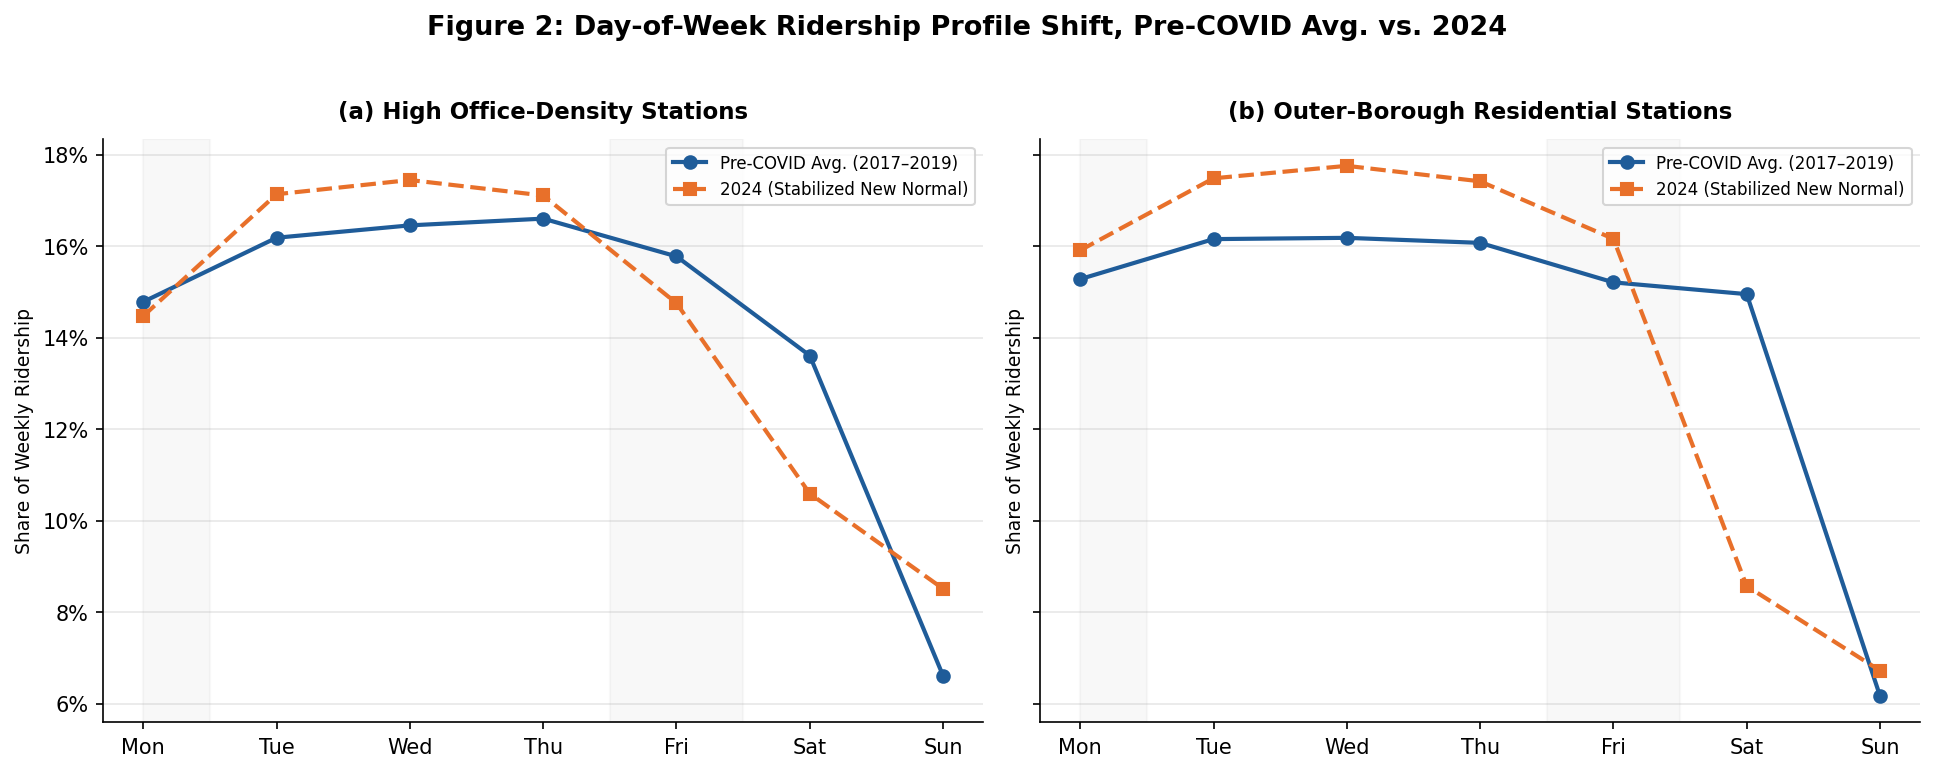


Figure 2 saved: /content/drive/MyDrive/dow_ridership_paper/outputs/figure2_dow_profile_shift_precovid_vs_2024.png


In [159]:
# ==============================================================
# Section 3.2 — Figure 2: Overlaid 7-Day Profiles
# Pre-COVID Average vs 2024
#
# Purpose:
#   Visualizes the structural shift in day-of-week ridership
#   profiles between the 2017–2019 pre-COVID average and 2024
#   for two contrasting station types:
#     (a) High office-density Manhattan stations
#     (b) Outer-borough residential stations
#
# Output:
#   figure2_dow_profile_shift_precovid_vs_2024.png
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import re


# -------------------------------------------------------
# Required DOW labels
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Representative stations
# These are search terms, not exact full names.
# The code below uses partial case-insensitive matching.
# -------------------------------------------------------

OFFICE_STATIONS = [
    "Grand Central",
    "Times Sq",
    "Rockefeller",
    "Herald Sq",
    "Fulton St",
]

RESIDENTIAL_STATIONS = [
    "Flatbush",
    "Pelham Bay",
    "Jamaica-179",
    "Bay Ridge",
    "Norwood",
]


# -------------------------------------------------------
# Fallback color palette
# -------------------------------------------------------

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate required inputs
# -------------------------------------------------------

required_periods = ["precovid", 2024]
missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    missing_cols = [c for c in ["complex_name"] + DOW_LABELS if c not in dow_raw[period].columns]
    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing required columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper: inspect available complex names
# -------------------------------------------------------

def show_name_matches(search_terms, df_key="precovid", max_matches=10):
    """
    Print possible complex-name matches for each search term.
    Useful for confirming that representative stations exist.
    """

    df = dow_raw[df_key].copy()

    print(f"\nChecking names in dow_raw[{df_key!r}]")

    for term in search_terms:
        pattern = re.escape(term)

        matches = (
            df.loc[
                df["complex_name"].astype(str).str.contains(pattern, case=False, na=False, regex=True),
                "complex_name"
            ]
            .drop_duplicates()
            .head(max_matches)
            .tolist()
        )

        print(f"\nSearch term: {term}")

        if matches:
            for m in matches:
                print(f"  {m}")
        else:
            print("  No matches found.")


# -------------------------------------------------------
# Helper: get matched stations
# -------------------------------------------------------

def get_matched_station_rows(period, station_terms: list[str]) -> pd.DataFrame:
    """
    Returns rows from dow_raw[period] whose complex_name partially matches
    any of the search terms.
    """

    df = dow_raw[period].copy()

    matched_frames = []

    for term in station_terms:
        pattern = re.escape(term)

        sub = df.loc[
            df["complex_name"].astype(str).str.contains(pattern, case=False, na=False, regex=True),
            ["station_complex_id", "complex_name"] + DOW_LABELS
        ].copy()

        if not sub.empty:
            sub["matched_term"] = term
            matched_frames.append(sub)

    if not matched_frames:
        return pd.DataFrame(columns=["station_complex_id", "complex_name", "matched_term"] + DOW_LABELS)

    matched = (
        pd.concat(matched_frames, ignore_index=True)
        .drop_duplicates(subset=["station_complex_id", "complex_name"])
        .reset_index(drop=True)
    )

    return matched


# -------------------------------------------------------
# Helper: get normalized DOW profile
# -------------------------------------------------------

def get_profile(period, station_terms: list[str], group_label: str) -> pd.Series:
    """
    Get normalized mean DOW profile across a set of station complexes.
    Uses partial case-insensitive matching.
    """

    matched = get_matched_station_rows(period, station_terms)

    if matched.empty:
        print(f"\nWarning: no matching stations for {group_label} in period {period}.")
        print(f"Search terms: {station_terms}")
        return pd.Series(index=DOW_LABELS, dtype=float)

    print(f"\nMatched stations for {group_label}, period {period}:")
    for name in matched["complex_name"].drop_duplicates().tolist():
        print(f"  {name}")

    profile = matched[DOW_LABELS].mean()

    total = profile.sum()

    if total <= 0 or pd.isna(total):
        print(f"\nWarning: profile total is zero/NaN for {group_label}, period {period}.")
        return pd.Series(index=DOW_LABELS, dtype=float)

    return profile / total


# -------------------------------------------------------
# Optional name check
# -------------------------------------------------------

print("\n================ FIGURE 2 NAME MATCH CHECKS ================\n")

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key="precovid"
)

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key=2024
)


# -------------------------------------------------------
# Build figure
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

panel_specs = [
    {
        "terms": OFFICE_STATIONS,
        "title": "(a) High Office-Density Stations",
        "label": "office stations",
    },
    {
        "terms": RESIDENTIAL_STATIONS,
        "title": "(b) Outer-Borough Residential Stations",
        "label": "residential stations",
    },
]

for ax, spec in zip(axes, panel_specs):
    p_pre = get_profile(
        "precovid",
        spec["terms"],
        group_label=spec["label"]
    )

    p2024 = get_profile(
        2024,
        spec["terms"],
        group_label=spec["label"]
    )

    x = range(len(DOW_LABELS))

    ax.plot(
        x,
        p_pre,
        marker="o",
        linewidth=2,
        color=PALETTE[0],
        label="Pre-COVID Avg. (2017–2019)",
    )

    ax.plot(
        x,
        p2024,
        marker="s",
        linewidth=2,
        color=PALETTE[1],
        linestyle="--",
        label="2024 (Stabilized New Normal)",
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(DOW_LABELS)

    ax.set_title(
        spec["title"],
        fontsize=11,
        fontweight="bold",
        pad=10,
    )

    ax.set_ylabel("Share of Weekly Ridership", fontsize=9)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1, decimals=0)
    )

    # Lightly shade Monday and Friday to highlight hybrid-work-relevant days
    ax.axvspan(0, 0.5, alpha=0.05, color="gray")
    ax.axvspan(3.5, 4.5, alpha=0.05, color="gray")

    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)


fig.suptitle(
    "Figure 2: Day-of-Week Ridership Profile Shift, Pre-COVID Avg. vs. 2024",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

fig_out = OUT_DIR / "figure2_dow_profile_shift_precovid_vs_2024.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nFigure 2 saved: {fig_out}")


================ FIGURE 2 NAME MATCH CHECKS ================


Checking names in dow_raw['precovid']

Search term: Grand Central
  Grand Central-42 St (4,5,6,7,S)

Search term: Times Sq
  Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)

Search term: Rockefeller
  No matches found.

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
  Fulton St (2,3,4,5,A,C,J,Z)

Search term: Flatbush
  No matches found.

Search term: Pelham Bay
  Pelham Bay Park (6)

Search term: Jamaica-179
  Jamaica-179 St (F)

Search term: Bay Ridge
  Bay Ridge Av (R)
  Bay Ridge-95 St (R)

Search term: Norwood
  Norwood Av (J,Z)
  Norwood-205 St (D)

Checking names in dow_raw[2024]

Search term: Grand Central
  Grand Central-42 St (S,4,5,6,7)

Search term: Times Sq
  Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)

Search term: Rockefeller
  47-50 Sts-Rockefeller Ctr (B,D,F,M)

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
 

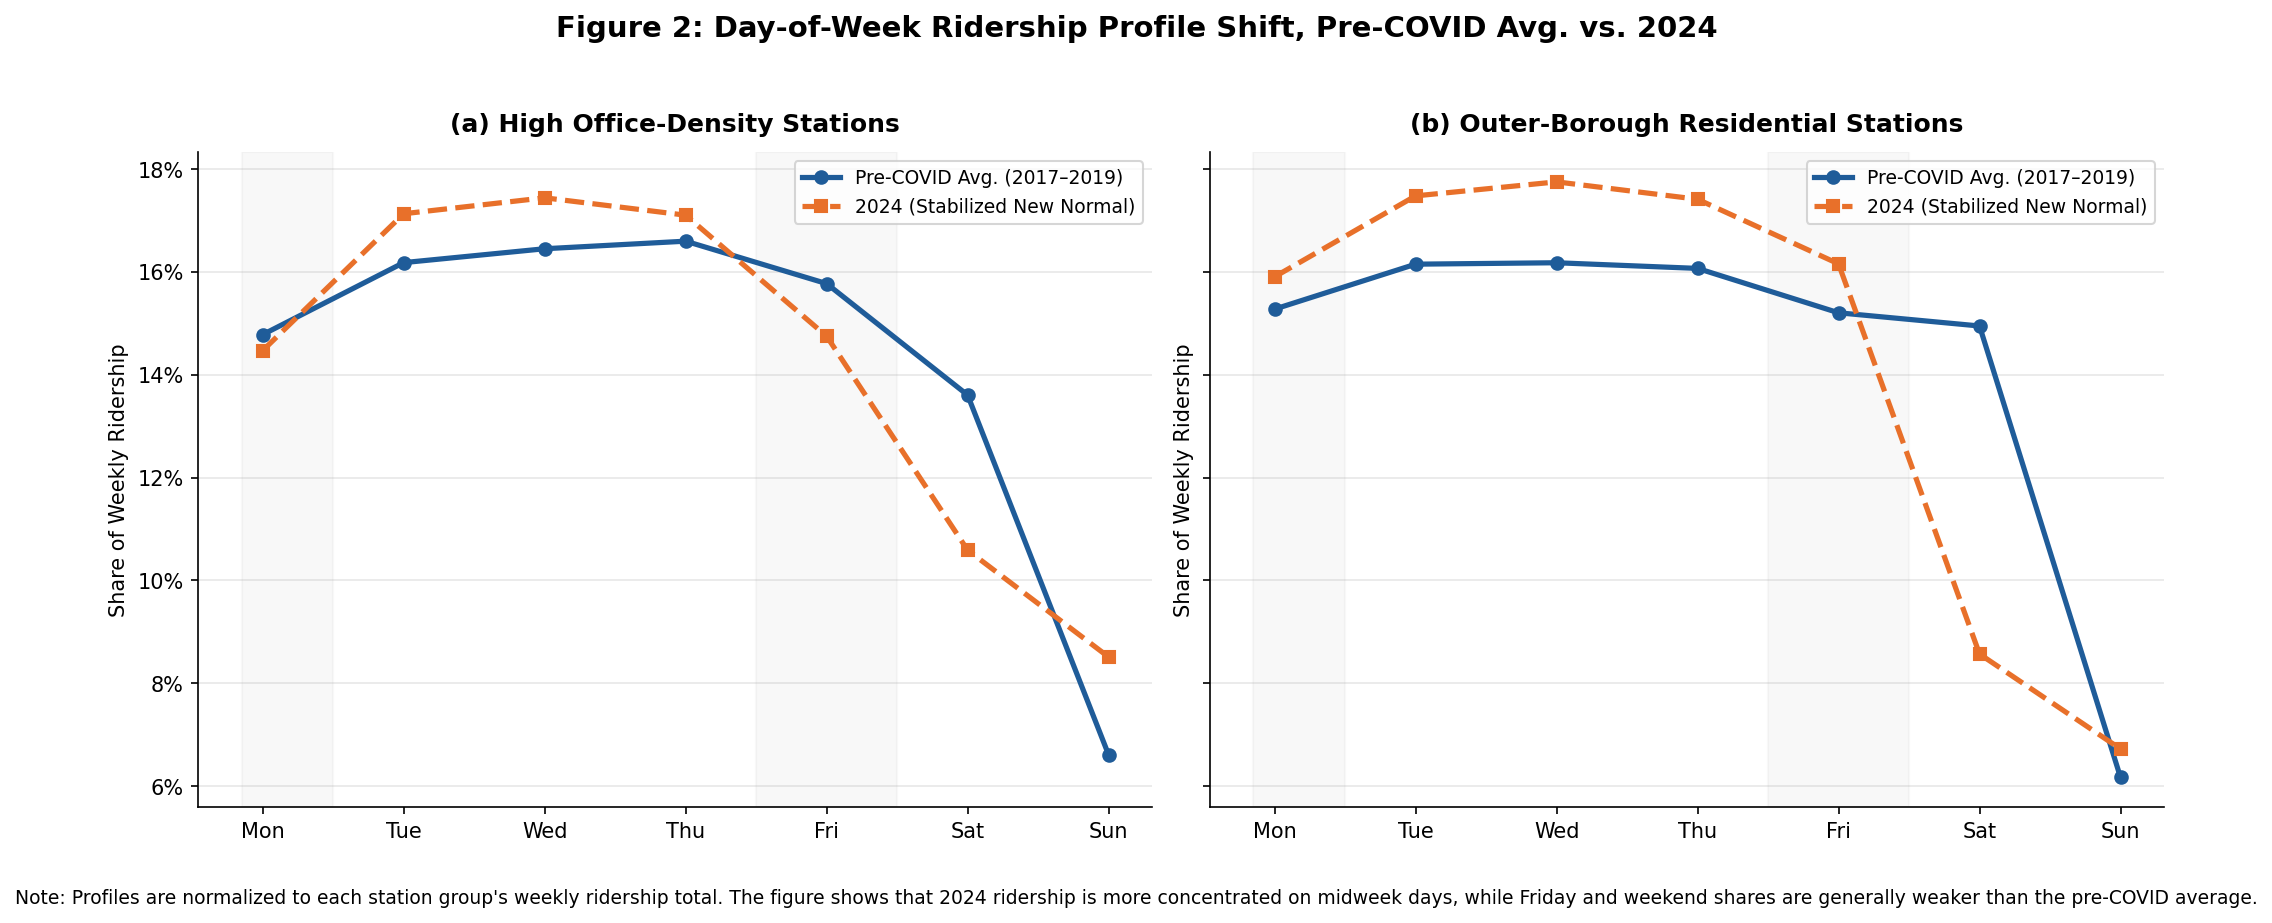


Figure 2 saved: /content/drive/MyDrive/dow_ridership_paper/outputs/figure2_dow_profile_shift_precovid_vs_2024.png


In [160]:
# ==============================================================
# Section 3.2 — Figure 2: Overlaid 7-Day Profiles
# Pre-COVID Average vs 2024
#
# Purpose:
#   Visualizes the structural shift in day-of-week ridership
#   profiles between the 2017–2019 pre-COVID average and 2024
#   for two contrasting station types:
#     (a) High office-density Manhattan stations
#     (b) Outer-borough residential stations
#
# Interpretation:
#   The figure highlights whether post-pandemic ridership is more
#   concentrated in the midweek and weaker on Fridays/weekends,
#   consistent with hybrid-work and changed non-work travel patterns.
#
# Output:
#   figure2_dow_profile_shift_precovid_vs_2024.png
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import re


# -------------------------------------------------------
# Required DOW labels
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Representative station search terms
# These are partial search terms, not exact full names.
# The code uses case-insensitive partial matching.
# -------------------------------------------------------

OFFICE_STATIONS = [
    "Grand Central",
    "Times Sq",
    "Rockefeller",
    "Herald Sq",
    "Fulton St",
]

RESIDENTIAL_STATIONS = [
    "Flatbush",
    "Pelham Bay",
    "Jamaica-179",
    "Bay Ridge",
    "Norwood",
]


# -------------------------------------------------------
# Fallback color palette
# -------------------------------------------------------

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate required inputs
# -------------------------------------------------------

required_periods = ["precovid", 2024]

missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    required_cols = ["station_complex_id", "complex_name"] + DOW_LABELS
    missing_cols = [c for c in required_cols if c not in dow_raw[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing required columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper: inspect available complex names
# -------------------------------------------------------

def show_name_matches(search_terms, df_key="precovid", max_matches=10):
    """
    Print possible complex-name matches for each search term.
    Useful for confirming that representative stations exist.
    """

    df = dow_raw[df_key].copy()

    print(f"\nChecking names in dow_raw[{df_key!r}]")

    for term in search_terms:
        pattern = re.escape(term)

        matches = (
            df.loc[
                df["complex_name"]
                .astype(str)
                .str.contains(pattern, case=False, na=False, regex=True),
                "complex_name"
            ]
            .drop_duplicates()
            .head(max_matches)
            .tolist()
        )

        print(f"\nSearch term: {term}")

        if matches:
            for m in matches:
                print(f"  {m}")
        else:
            print("  No matches found.")


# -------------------------------------------------------
# Helper: get matched station rows
# -------------------------------------------------------

def get_matched_station_rows(period, station_terms: list[str]) -> pd.DataFrame:
    """
    Returns rows from dow_raw[period] whose complex_name partially matches
    any of the search terms.
    """

    df = dow_raw[period].copy()

    matched_frames = []

    for term in station_terms:
        pattern = re.escape(term)

        sub = df.loc[
            df["complex_name"]
            .astype(str)
            .str.contains(pattern, case=False, na=False, regex=True),
            ["station_complex_id", "complex_name"] + DOW_LABELS
        ].copy()

        if not sub.empty:
            sub["matched_term"] = term
            matched_frames.append(sub)

    if not matched_frames:
        return pd.DataFrame(
            columns=["station_complex_id", "complex_name", "matched_term"] + DOW_LABELS
        )

    matched = (
        pd.concat(matched_frames, ignore_index=True)
        .drop_duplicates(subset=["station_complex_id", "complex_name"])
        .reset_index(drop=True)
    )

    return matched


# -------------------------------------------------------
# Helper: get normalized DOW profile
# -------------------------------------------------------

def get_profile(period, station_terms: list[str], group_label: str) -> pd.Series:
    """
    Get normalized mean DOW profile across a set of station complexes.
    Uses partial case-insensitive matching.
    """

    matched = get_matched_station_rows(period, station_terms)

    if matched.empty:
        print(f"\nWarning: no matching stations for {group_label} in period {period}.")
        print(f"Search terms: {station_terms}")
        return pd.Series(index=DOW_LABELS, dtype=float)

    print(f"\nMatched stations for {group_label}, period {period}:")
    for name in matched["complex_name"].drop_duplicates().tolist():
        print(f"  {name}")

    profile = matched[DOW_LABELS].mean()
    total = profile.sum()

    if total <= 0 or pd.isna(total):
        print(f"\nWarning: profile total is zero/NaN for {group_label}, period {period}.")
        return pd.Series(index=DOW_LABELS, dtype=float)

    return profile / total


# -------------------------------------------------------
# Optional name checks
# -------------------------------------------------------

print("\n================ FIGURE 2 NAME MATCH CHECKS ================\n")

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key="precovid"
)

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key=2024
)


# -------------------------------------------------------
# Build profiles
# -------------------------------------------------------

office_pre = get_profile(
    "precovid",
    OFFICE_STATIONS,
    group_label="high office-density stations"
)

office_2024 = get_profile(
    2024,
    OFFICE_STATIONS,
    group_label="high office-density stations"
)

res_pre = get_profile(
    "precovid",
    RESIDENTIAL_STATIONS,
    group_label="outer-borough residential stations"
)

res_2024 = get_profile(
    2024,
    RESIDENTIAL_STATIONS,
    group_label="outer-borough residential stations"
)


# -------------------------------------------------------
# Build figure
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

panel_specs = [
    {
        "ax": axes[0],
        "p_pre": office_pre,
        "p2024": office_2024,
        "title": "(a) High Office-Density Stations",
    },
    {
        "ax": axes[1],
        "p_pre": res_pre,
        "p2024": res_2024,
        "title": "(b) Outer-Borough Residential Stations",
    },
]

for spec in panel_specs:
    ax = spec["ax"]
    x = range(len(DOW_LABELS))

    ax.plot(
        x,
        spec["p_pre"],
        marker="o",
        linewidth=2.5,
        color=PALETTE[0],
        label="Pre-COVID Avg. (2017–2019)",
    )

    ax.plot(
        x,
        spec["p2024"],
        marker="s",
        linewidth=2.5,
        color=PALETTE[1],
        linestyle="--",
        label="2024 (Stabilized New Normal)",
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(DOW_LABELS)

    ax.set_title(
        spec["title"],
        fontsize=12,
        fontweight="bold",
        pad=10,
    )

    ax.set_ylabel("Share of Weekly Ridership", fontsize=10)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1, decimals=0)
    )

    # Lightly shade Monday and Friday to highlight hybrid-work-relevant days
    ax.axvspan(-0.15, 0.5, alpha=0.05, color="gray")
    ax.axvspan(3.5, 4.5, alpha=0.05, color="gray")

    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)


# -------------------------------------------------------
# Title and interpretation note
# -------------------------------------------------------

fig.suptitle(
    "Figure 2: Day-of-Week Ridership Profile Shift, Pre-COVID Avg. vs. 2024",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)

fig.text(
    0.5,
    -0.03,
    (
        "Note: Profiles are normalized to each station group's weekly ridership total. "
        "The figure shows that 2024 ridership is more concentrated on midweek days, "
        "while Friday and weekend shares are generally weaker than the pre-COVID average."
    ),
    ha="center",
    va="top",
    fontsize=9,
)


plt.tight_layout()


# -------------------------------------------------------
# Save figure
# -------------------------------------------------------

fig_out = OUT_DIR / "figure2_dow_profile_shift_precovid_vs_2024.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nFigure 2 saved: {fig_out}")

In [161]:
# ==============================================================
# Section 3.3 — Monday/Friday vs. Tuesday–Thursday Recovery Gap
#
# Purpose:
#   Quantifies the "Mon/Fri gap" — the structural divergence
#   between Monday/Friday recovery and Tuesday–Thursday recovery.
#
# Main metric:
#   Recovery Rate = period mean entries / pre-COVID average mean entries
#
# Baseline:
#   Pre-COVID Avg. = 2017–2019 average
#
# Main comparison:
#   2022 = Early Recovery
#   2024 = Stabilized New Normal
#
# Robustness:
#   2023 = Transitional Recovery
#
# Outputs:
#   recovery_rates_by_dow.csv
#   recovery_gap_summary.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Required DOW labels and periods
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PERIOD_LABELS = {
    "precovid": "Pre-COVID Avg. (2017–2019)",
    2022: "Early Recovery (2022)",
    2023: "Transitional Recovery (2023)",
    2024: "Stabilized New Normal (2024)",
}

RECOVERY_PERIODS = [2022, 2023, 2024]


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

required_periods = ["precovid"] + RECOVERY_PERIODS

missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    missing_cols = [c for c in DOW_LABELS if c not in dow_raw[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Build recovery table by day of week
# -------------------------------------------------------

recovery_rows = []

for day in DOW_LABELS:
    baseline_mean = dow_raw["precovid"][day].mean()

    row = {
        "day": day,
        "baseline_mean_precovid": baseline_mean,
    }

    for period in RECOVERY_PERIODS:
        period_mean = dow_raw[period][day].mean()

        row[f"mean_{period}"] = period_mean

        row[f"recovery_{period}"] = (
            period_mean / baseline_mean
            if baseline_mean > 0
            else np.nan
        )

        row[f"pct_change_vs_precovid_{period}"] = (
            (period_mean - baseline_mean) / baseline_mean * 100
            if baseline_mean > 0
            else np.nan
        )

    recovery_rows.append(row)

recovery_df = (
    pd.DataFrame(recovery_rows)
    .set_index("day")
    .reindex(DOW_LABELS)
)


# -------------------------------------------------------
# Print recovery table with simple text bars
# -------------------------------------------------------

print("Recovery Rates by Day of Week")
print("Baseline: 2017–2019 Pre-COVID Average")
print("-" * 70)

for day, row in recovery_df.iterrows():
    print(f"\n{day}")

    for period in RECOVERY_PERIODS:
        recovery_value = row[f"recovery_{period}"]

        if pd.isna(recovery_value):
            bar = ""
            display_value = "NA"
        else:
            bar = "█" * int(recovery_value * 20)
            display_value = f"{recovery_value:5.1%}"

        print(
            f"  {period}: {display_value} {bar}"
        )


# -------------------------------------------------------
# Compute Mon/Fri vs Tue–Thu recovery gaps
# -------------------------------------------------------

gap_rows = []

for period in RECOVERY_PERIODS:
    monfri_recovery = recovery_df.loc[
        ["Mon", "Fri"],
        f"recovery_{period}"
    ].mean()

    tuethu_recovery = recovery_df.loc[
        ["Tue", "Wed", "Thu"],
        f"recovery_{period}"
    ].mean()

    weekend_recovery = recovery_df.loc[
        ["Sat", "Sun"],
        f"recovery_{period}"
    ].mean()

    gap = tuethu_recovery - monfri_recovery

    gap_rows.append(
        {
            "period": period,
            "period_label": PERIOD_LABELS[period],
            "monfri_recovery": monfri_recovery,
            "tuethu_recovery": tuethu_recovery,
            "weekend_recovery": weekend_recovery,
            "midweek_premium_over_monfri": gap,
        }
    )

gap_summary = pd.DataFrame(gap_rows)


# -------------------------------------------------------
# Print key findings
# -------------------------------------------------------

print("\n\nMon/Fri vs Tuesday–Thursday Recovery Gap")
print("Baseline: 2017–2019 Pre-COVID Average")
print("-" * 70)

for _, row in gap_summary.iterrows():
    print(f"\n{row['period_label']}")
    print(f"  Mon/Fri average recovery:       {row['monfri_recovery']:.1%}")
    print(f"  Tue–Thu average recovery:       {row['tuethu_recovery']:.1%}")
    print(f"  Weekend average recovery:       {row['weekend_recovery']:.1%}")
    print(
        f"  Midweek premium over Mon/Fri:   "
        f"{row['midweek_premium_over_monfri']:.1%}"
    )


# -------------------------------------------------------
# Save outputs
# -------------------------------------------------------

recovery_out = OUT_DIR / "recovery_rates_by_dow.csv"
gap_out = OUT_DIR / "recovery_gap_summary.csv"

recovery_df.to_csv(recovery_out)
gap_summary.to_csv(gap_out, index=False)

print("\nSaved outputs:")
print(f"  {recovery_out}")
print(f"  {gap_out}")


# -------------------------------------------------------
# Display clean tables
# -------------------------------------------------------

print("\nRecovery table preview:")
display(
    recovery_df[
        [
            "baseline_mean_precovid",
            "mean_2022",
            "recovery_2022",
            "mean_2023",
            "recovery_2023",
            "mean_2024",
            "recovery_2024",
        ]
    ].round(3)
)

print("\nGap summary:")
display(gap_summary.round(3))

Recovery Rates by Day of Week
Baseline: 2017–2019 Pre-COVID Average
----------------------------------------------------------------------

Mon
  2022: 44.7% ████████
  2023: 50.4% ██████████
  2024: 53.2% ██████████

Tue
  2022: 47.2% █████████
  2023: 54.2% ██████████
  2024: 55.8% ███████████

Wed
  2022: 47.4% █████████
  2023: 54.4% ██████████
  2024: 55.6% ███████████

Thu
  2022: 46.7% █████████
  2023: 53.3% ██████████
  2024: 54.8% ██████████

Fri
  2022: 46.2% █████████
  2023: 51.2% ██████████
  2024: 53.1% ██████████

Sat
  2022: 29.7% █████
  2023: 34.3% ██████
  2024: 35.9% ███████

Sun
  2022: 51.0% ██████████
  2023: 59.2% ███████████
  2024: 62.3% ████████████


Mon/Fri vs Tuesday–Thursday Recovery Gap
Baseline: 2017–2019 Pre-COVID Average
----------------------------------------------------------------------

Early Recovery (2022)
  Mon/Fri average recovery:       45.4%
  Tue–Thu average recovery:       47.1%
  Weekend average recovery:       40.3%
  Midweek premium o

,baseline_mean_precovid,mean_2022,recovery_2022,mean_2023,recovery_2023,mean_2024,recovery_2024
day,,,,,,,
Mon,"15,029.66","6,720.79",0.45,"7,573.35",0.50,"7,998.07",0.53
Tue,"16,187.48","7,638.53",0.47,"8,765.67",0.54,"9,029.35",0.56
Wed,"16,502.50","7,814.72",0.47,"8,983.06",0.54,"9,174.66",0.56
Thu,"16,594.26","7,753.20",0.47,"8,852.53",0.53,"9,095.57",0.55
Fri,"15,950.50","7,362.53",0.46,"8,159.32",0.51,"8,463.34",0.53
Sat,"16,199.50","4,807.51",0.30,"5,552.00",0.34,"5,822.25",0.36
Sun,"7,474.89","3,811.24",0.51,"4,424.93",0.59,"4,656.52",0.62



Gap summary:


,period,period_label,monfri_recovery,tuethu_recovery,weekend_recovery,midweek_premium_over_monfri
0,2022,Early Recovery (2022),0.45,0.47,0.40,0.02
1,2023,Transitional Recovery (2023),0.51,0.54,0.47,0.03
2,2024,Stabilized New Normal (2024),0.53,0.55,0.49,0.02


---
## SECTION 4: Cluster Analysis

### 4.1 K Selection: Elbow Method + Silhouette Score

We sweep K from 2 to 8. The optimal K is selected at the inflection point of the inertia curve (elbow method), validated by the silhouette score which measures cluster cohesion relative to separation.

K-selection input summary
--------------------------------------------------
Analysis year: 2024
Rows before low-volume filter: 426
Rows after low-volume filter:  426
Feature matrix shape:          (426, 7)

K-selection diagnostics
--------------------------------------------------
  K= 2  inertia=    1573.0  silhouette=0.3937
  K= 3  inertia=    1105.9  silhouette=0.3578
  K= 4  inertia=     912.5  silhouette=0.3715
  K= 5  inertia=     744.6  silhouette=0.3137
  K= 6  inertia=     653.7  silhouette=0.2858
  K= 7  inertia=     582.2  silhouette=0.3048
  K= 8  inertia=     528.2  silhouette=0.2683


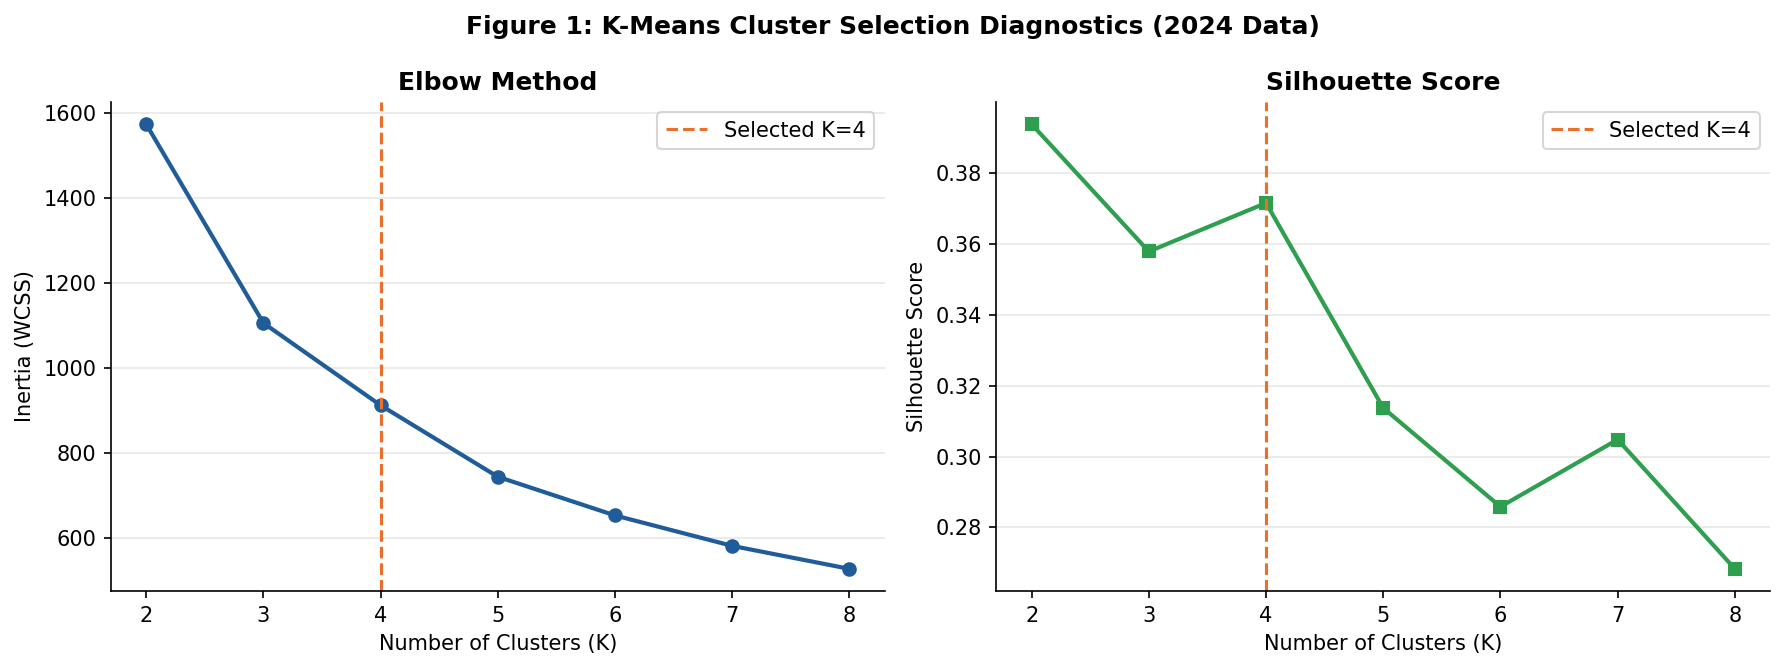


K-selection summary
--------------------------------------------------
Selected K_FINAL:                 4
Highest silhouette K:             2 (score=0.3937)
Diagnostics saved:                /content/drive/MyDrive/dow_ridership_paper/outputs/k_selection_diagnostics_2024.csv
Figure saved:                     /content/drive/MyDrive/dow_ridership_paper/outputs/figure1_k_selection_2024.png

Interpretation note: K=2 has the highest silhouette score, but K=4 is selected as a more interpretable demand-regime solution. It preserves meaningful variation in day-of-week profiles while avoiding the weaker silhouette and likely over-fragmentation at K>=5.


In [162]:
# ==============================================================
# Section 4.1 — K-Selection: Elbow + Silhouette
#
# Purpose:
#   Determines the optimal number of clusters K for K-means
#   applied to normalized 7-day DOW ridership vectors.
#
# Method:
#   - Primary clustering target: 2024 Stabilized New Normal
#   - Sweep K = 2..8
#   - Record inertia for elbow method
#   - Record silhouette score for each K
#   - Select K_FINAL = 4 based on interpretability and diagnostics
#
# Input:
#   dow_vectors[2024]
#
# Outputs:
#   figure1_k_selection_2024.png
#   k_selection_diagnostics_2024.csv
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

CLUSTER_YEAR = 2024

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

K_RANGE = range(2, 9)

# Final selected K
# K=2 has the highest silhouette, but K=4 provides a more interpretable
# demand-regime solution while avoiding over-fragmentation at K>=5.
K_FINAL = 4

if "KMEANS_INIT" not in globals():
    KMEANS_INIT = 50

if "KMEANS_SEED" not in globals():
    KMEANS_SEED = 42

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

if "dow_vectors" not in globals():
    raise RuntimeError(
        "dow_vectors not found. Run Section 2.3 first."
    )

if CLUSTER_YEAR not in dow_vectors:
    raise RuntimeError(
        f"dow_vectors[{CLUSTER_YEAR}] not found.\n"
        f"Available keys: {list(dow_vectors.keys())}\n"
        "Run Section 2.3 first."
    )

cluster_df = dow_vectors[CLUSTER_YEAR].copy()

missing_cols = [c for c in DOW_LABELS if c not in cluster_df.columns]

if missing_cols:
    raise RuntimeError(
        f"dow_vectors[{CLUSTER_YEAR}] is missing DOW columns: {missing_cols}\n"
        f"Columns found: {list(cluster_df.columns)}"
    )

if "low_volume_flag" not in cluster_df.columns:
    print("Warning: low_volume_flag not found. Creating default False flag.")
    cluster_df["low_volume_flag"] = False


# -------------------------------------------------------
# Prepare feature matrix
# -------------------------------------------------------

before_filter = len(cluster_df)

cluster_df = cluster_df[
    ~cluster_df["low_volume_flag"].fillna(False).astype(bool)
].copy()

after_filter = len(cluster_df)

if after_filter < 10:
    raise RuntimeError(
        f"Too few station complexes available for clustering: {after_filter}.\n"
        "Check Section 2.3 outputs."
    )

X = cluster_df[DOW_LABELS].astype(float).values

print("K-selection input summary")
print("-" * 50)
print(f"Analysis year: {CLUSTER_YEAR}")
print(f"Rows before low-volume filter: {before_filter:,}")
print(f"Rows after low-volume filter:  {after_filter:,}")
print(f"Feature matrix shape:          {X.shape}")


# -------------------------------------------------------
# Standardize features
# -------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -------------------------------------------------------
# K sweep
# -------------------------------------------------------

inertias = []
silhouettes = []
valid_k_values = []

print("\nK-selection diagnostics")
print("-" * 50)

for k in K_RANGE:
    if k >= len(cluster_df):
        print(f"Skipping K={k}: K must be less than number of observations.")
        continue

    km = KMeans(
        n_clusters=k,
        n_init=KMEANS_INIT,
        random_state=KMEANS_SEED,
        max_iter=500,
    )

    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    valid_k_values.append(k)
    inertias.append(inertia)
    silhouettes.append(silhouette)

    print(
        f"  K={k:2d}  "
        f"inertia={inertia:10.1f}  "
        f"silhouette={silhouette:.4f}"
    )


# -------------------------------------------------------
# Save diagnostics table
# -------------------------------------------------------

k_diag = pd.DataFrame(
    {
        "k": valid_k_values,
        "inertia": inertias,
        "silhouette": silhouettes,
        "selected_k": [k == K_FINAL for k in valid_k_values],
    }
)

k_diag_out = OUT_DIR / f"k_selection_diagnostics_{CLUSTER_YEAR}.csv"
k_diag.to_csv(k_diag_out, index=False)


# -------------------------------------------------------
# Plot diagnostics
# -------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(
    k_diag["k"],
    k_diag["inertia"],
    "o-",
    color=PALETTE[0],
    linewidth=2,
)

ax1.axvline(
    K_FINAL,
    color=PALETTE[1],
    linestyle="--",
    label=f"Selected K={K_FINAL}",
)

ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method", fontweight="bold")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)


ax2.plot(
    k_diag["k"],
    k_diag["silhouette"],
    "s-",
    color=PALETTE[2],
    linewidth=2,
)

ax2.axvline(
    K_FINAL,
    color=PALETTE[1],
    linestyle="--",
    label=f"Selected K={K_FINAL}",
)

ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score", fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)


plt.suptitle(
    f"Figure 1: K-Means Cluster Selection Diagnostics ({CLUSTER_YEAR} Data)",
    fontweight="bold",
)

plt.tight_layout()

fig_out = OUT_DIR / f"figure1_k_selection_{CLUSTER_YEAR}.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# -------------------------------------------------------
# Report selected K
# -------------------------------------------------------

best_silhouette_row = k_diag.loc[k_diag["silhouette"].idxmax()]

print("\nK-selection summary")
print("-" * 50)
print(f"Selected K_FINAL:                 {K_FINAL}")
print(
    f"Highest silhouette K:             "
    f"{int(best_silhouette_row['k'])} "
    f"(score={best_silhouette_row['silhouette']:.4f})"
)
print(f"Diagnostics saved:                {k_diag_out}")
print(f"Figure saved:                     {fig_out}")

print(
    "\nInterpretation note: K=2 has the highest silhouette score, "
    "but K=4 is selected as a more interpretable demand-regime solution. "
    "It preserves meaningful variation in day-of-week profiles while avoiding "
    "the weaker silhouette and likely over-fragmentation at K>=5."
)

In [163]:
# ==============================================================
# Section 4.2 — Final K-Means Fit
#
# Purpose:
#   Fits K-means with K=K_FINAL on normalized 7-day vectors
#   using 2024 as the primary clustering/training period.
#
# Important:
#   - Scaler is fit ONLY on 2024 data.
#   - K-means is fit ONLY on 2024 data.
#   - Pre-COVID, 2022, and 2023 vectors are transformed using
#     the same 2024-fitted scaler and assigned to the 2024
#     cluster structure for cross-period comparison.
#
# Baseline:
#   Pre-COVID Avg. = 2017–2019 average
#
# Main periods:
#   Pre-COVID Avg., 2022, 2024
#
# Robustness:
#   2023
#
# Outputs:
#   cluster_assignments_precovid.csv
#   cluster_assignments_2022.csv
#   cluster_assignments_2023.csv
#   cluster_assignments_2024.csv
#   cluster_centers_2024.csv
#   cluster_assignment_summary.csv
# ==============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

CLUSTER_YEAR = 2024
ASSIGNMENT_PERIODS = ["precovid", 2022, 2023, 2024]

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if "K_FINAL" not in globals():
    K_FINAL = 5

if "KMEANS_INIT" not in globals():
    KMEANS_INIT = 50

if "KMEANS_SEED" not in globals():
    KMEANS_SEED = 42


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

if "dow_vectors" not in globals():
    raise RuntimeError(
        "dow_vectors not found. Run Section 2.3 first."
    )

missing_periods = [p for p in ASSIGNMENT_PERIODS if p not in dow_vectors]

if missing_periods:
    raise RuntimeError(
        f"dow_vectors is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_vectors.keys())}\n"
        "Run Section 2.3 first."
    )

for period in ASSIGNMENT_PERIODS:
    missing_cols = [c for c in DOW_LABELS if c not in dow_vectors[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_vectors[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_vectors[period].columns)}"
        )

    if "low_volume_flag" not in dow_vectors[period].columns:
        print(f"Warning: low_volume_flag missing for {period}; setting to False.")
        dow_vectors[period]["low_volume_flag"] = False


# -------------------------------------------------------
# Prepare 2024 training data
# -------------------------------------------------------

train_df = dow_vectors[CLUSTER_YEAR].copy()

before_train = len(train_df)

train_df = train_df[
    ~train_df["low_volume_flag"].fillna(False).astype(bool)
].copy()

after_train = len(train_df)

if after_train < K_FINAL:
    raise RuntimeError(
        f"Too few 2024 station complexes for K={K_FINAL}: {after_train} rows."
    )

X_train = train_df[DOW_LABELS].astype(float).values

print("Final K-means training summary")
print("-" * 60)
print(f"Training period:              {CLUSTER_YEAR}")
print(f"K_FINAL:                      {K_FINAL}")
print(f"Rows before low-volume filter: {before_train:,}")
print(f"Rows after low-volume filter:  {after_train:,}")
print(f"Feature matrix shape:          {X_train.shape}")


# -------------------------------------------------------
# Fit scaler and final K-means on 2024 only
# -------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

km_final = KMeans(
    n_clusters=K_FINAL,
    n_init=KMEANS_INIT,
    random_state=KMEANS_SEED,
    max_iter=1000,
)

km_final.fit(X_train_scaled)

print("\nFinal K-means model fit complete.")


# -------------------------------------------------------
# Save 2024 cluster centers in original DOW-share scale
# -------------------------------------------------------
# Cluster centers are fitted in standardized space. Convert them back
# to the original normalized DOW-share scale for interpretation.

centers_scaled = km_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=DOW_LABELS,
)

cluster_centers.insert(0, "cluster", range(K_FINAL))

# Normalize centers again for safety because inverse transform can create
# very small floating-point deviations from row sum = 1.
row_sums = cluster_centers[DOW_LABELS].sum(axis=1)

cluster_centers[DOW_LABELS] = cluster_centers[DOW_LABELS].div(
    row_sums,
    axis=0,
)

cluster_centers["weekday_share"] = cluster_centers[
    ["Mon", "Tue", "Wed", "Thu", "Fri"]
].sum(axis=1)

cluster_centers["weekend_share"] = cluster_centers[
    ["Sat", "Sun"]
].sum(axis=1)

cluster_centers["monfri_share"] = cluster_centers[
    ["Mon", "Fri"]
].sum(axis=1)

cluster_centers["tuethu_share"] = cluster_centers[
    ["Tue", "Wed", "Thu"]
].sum(axis=1)

cluster_centers["midweek_minus_monfri"] = (
    cluster_centers["tuethu_share"] -
    cluster_centers["monfri_share"]
)

centers_out = OUT_DIR / f"cluster_centers_{CLUSTER_YEAR}.csv"
cluster_centers.to_csv(centers_out, index=False)


# -------------------------------------------------------
# Assign clusters to each period
# -------------------------------------------------------

cluster_assignments = {}
summary_rows = []

for period in ASSIGNMENT_PERIODS:
    df_period = dow_vectors[period].copy()

    df_period = df_period[
        ~df_period["low_volume_flag"].fillna(False).astype(bool)
    ].copy()

    if df_period.empty:
        print(f"\nWarning: no rows available for period {period}. Skipping.")
        continue

    X_period = df_period[DOW_LABELS].astype(float).values
    X_period_scaled = scaler.transform(X_period)

    df_period["cluster"] = km_final.predict(X_period_scaled)
    df_period["period"] = period
    df_period["period_label"] = (
        "Pre-COVID Avg. (2017–2019)"
        if period == "precovid"
        else str(period)
    )

    # Add helpful profile metrics
    df_period["weekday_share"] = df_period[
        ["Mon", "Tue", "Wed", "Thu", "Fri"]
    ].sum(axis=1)

    df_period["weekend_share"] = df_period[
        ["Sat", "Sun"]
    ].sum(axis=1)

    df_period["monfri_share"] = df_period[
        ["Mon", "Fri"]
    ].sum(axis=1)

    df_period["tuethu_share"] = df_period[
        ["Tue", "Wed", "Thu"]
    ].sum(axis=1)

    df_period["midweek_minus_monfri"] = (
        df_period["tuethu_share"] -
        df_period["monfri_share"]
    )

    # Save assignment file
    period_file = "precovid" if period == "precovid" else str(period)
    cache = OUT_DIR / f"cluster_assignments_{period_file}.csv"

    df_period.to_csv(cache, index=False)

    cluster_assignments[period] = df_period

    dist = (
        df_period["cluster"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(f"\n{period}: cluster assignments saved")
    print(f"  File: {cache}")
    print(f"  Rows: {len(df_period):,}")
    print(f"  Distribution: {dist}")

    for cluster_id, count in dist.items():
        summary_rows.append(
            {
                "period": period,
                "period_label": df_period["period_label"].iloc[0],
                "cluster": cluster_id,
                "n_station_complexes": count,
                "share_of_period": count / len(df_period),
            }
        )


# -------------------------------------------------------
# Save cluster assignment summary
# -------------------------------------------------------

cluster_assignment_summary = pd.DataFrame(summary_rows)

summary_out = OUT_DIR / "cluster_assignment_summary.csv"

cluster_assignment_summary.to_csv(summary_out, index=False)

print("\nK-means fitting and cluster assignment complete.")
print(f"Cluster centers saved:      {centers_out}")
print(f"Assignment summary saved:   {summary_out}")


# -------------------------------------------------------
# Display summaries
# -------------------------------------------------------

print("\nCluster centers, original DOW-share scale:")
display(cluster_centers.round(4))

print("\nCluster assignment summary:")
display(cluster_assignment_summary.round(4))

Final K-means training summary
------------------------------------------------------------
Training period:              2024
K_FINAL:                      4
Rows before low-volume filter: 426
Rows after low-volume filter:  426
Feature matrix shape:          (426, 7)

Final K-means model fit complete.

precovid: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_precovid.csv
  Rows: 319
  Distribution: {0: 223, 1: 8, 2: 86, 3: 2}

2022: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2022.csv
  Rows: 426
  Distribution: {0: 54, 1: 164, 2: 188, 3: 20}

2023: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2023.csv
  Rows: 426
  Distribution: {0: 62, 1: 132, 2: 193, 3: 39}

2024: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2024.csv
  Rows: 426
  Distribution: {0

,cluster,Mon,Tue,Wed,Thu,Fri,Sat,Sun,weekday_share,weekend_share,monfri_share,tuethu_share,midweek_minus_monfri
0,0,0.14,0.15,0.16,0.16,0.16,0.14,0.11,0.76,0.24,0.29,0.46,0.17
1,1,0.16,0.18,0.18,0.18,0.17,0.08,0.06,0.86,0.14,0.33,0.53,0.20
2,2,0.15,0.17,0.17,0.17,0.16,0.11,0.08,0.81,0.19,0.31,0.50,0.19
3,3,0.15,0.18,0.18,0.18,0.15,0.09,0.07,0.84,0.16,0.30,0.55,0.25



Cluster assignment summary:


,period,period_label,cluster,n_station_complexes,share_of_period
0,precovid,Pre-COVID Avg. (2017–2019),0,223,0.70
1,precovid,Pre-COVID Avg. (2017–2019),1,8,0.03
2,precovid,Pre-COVID Avg. (2017–2019),2,86,0.27
3,precovid,Pre-COVID Avg. (2017–2019),3,2,0.01
4,2022,2022,0,54,0.13
5,2022,2022,1,164,0.39
6,2022,2022,2,188,0.44
7,2022,2022,3,20,0.05
8,2023,2023,0,62,0.15
9,2023,2023,1,132,0.31


In [164]:
# ==============================================================
# Section 4.3 — Cluster Profile Analysis and Labeling
#
# Purpose:
#   Computes mean normalized DOW profile for each 2024 cluster
#   and generates interpretive labels based on profile shape and
#   representative stations.
#
# This produces Table 2 in the TRR paper.
#
# Important:
#   - Clusters were trained on 2024 in Section 4.2.
#   - Manual labels below are based on the observed 2024 cluster
#     profiles and representative high-volume station complexes.
#
# Outputs:
#   table2_cluster_profiles.csv
#   table2_cluster_profiles_labeled.csv
#   cluster_label_mapping.csv
#   cluster_assignments_{period}_labeled.csv
#   representative_stations_by_cluster.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Required setup
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

ASSIGNMENT_PERIODS = ["precovid", 2022, 2023, 2024]

if "cluster_assignments" not in globals():
    raise RuntimeError(
        "cluster_assignments not found. Run Section 4.2 first."
    )

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. "
        f"Available keys: {list(cluster_assignments.keys())}"
    )

for period in ASSIGNMENT_PERIODS:
    if period not in cluster_assignments:
        raise RuntimeError(
            f"cluster_assignments[{period!r}] not found. "
            f"Available keys: {list(cluster_assignments.keys())}\n"
            "Run Section 4.2 first."
        )


# -------------------------------------------------------
# Use 2024 cluster assignments for profile labeling
# -------------------------------------------------------

df_2024_clusters = cluster_assignments[2024].copy()

missing_cols = [
    c for c in ["cluster", "complex_name", "avg_weekday_entries"] + DOW_LABELS
    if c not in df_2024_clusters.columns
]

if missing_cols:
    raise RuntimeError(
        f"2024 cluster assignment data is missing required columns: {missing_cols}\n"
        f"Columns found: {list(df_2024_clusters.columns)}"
    )


# -------------------------------------------------------
# Compute cluster profiles in original normalized DOW-share space
# -------------------------------------------------------

cluster_profiles = (
    df_2024_clusters
    .groupby("cluster")[DOW_LABELS]
    .mean()
    .round(4)
)

cluster_sizes = (
    df_2024_clusters["cluster"]
    .value_counts()
    .sort_index()
    .rename("n_station_complexes")
)

cluster_profiles = cluster_profiles.join(cluster_sizes)


# -------------------------------------------------------
# Add interpretable profile metrics
# -------------------------------------------------------

cluster_profiles["weekday_share"] = cluster_profiles[
    ["Mon", "Tue", "Wed", "Thu", "Fri"]
].sum(axis=1)

cluster_profiles["weekend_share"] = cluster_profiles[
    ["Sat", "Sun"]
].sum(axis=1)

cluster_profiles["monfri_share"] = cluster_profiles[
    ["Mon", "Fri"]
].sum(axis=1)

cluster_profiles["tuethu_share"] = cluster_profiles[
    ["Tue", "Wed", "Thu"]
].sum(axis=1)

cluster_profiles["midweek_minus_monfri"] = (
    cluster_profiles["tuethu_share"] -
    cluster_profiles["monfri_share"]
)

cluster_profiles["fri_minus_tuethu_avg"] = (
    cluster_profiles["Fri"] -
    cluster_profiles[["Tue", "Wed", "Thu"]].mean(axis=1)
)

cluster_profiles["sat_sun_ratio"] = (
    cluster_profiles["Sat"] /
    cluster_profiles["Sun"].replace(0, np.nan)
)

cluster_profiles["peak_day"] = cluster_profiles[DOW_LABELS].idxmax(axis=1)
cluster_profiles["lowest_day"] = cluster_profiles[DOW_LABELS].idxmin(axis=1)

cluster_profiles["profile_range"] = (
    cluster_profiles[DOW_LABELS].max(axis=1) -
    cluster_profiles[DOW_LABELS].min(axis=1)
)


# -------------------------------------------------------
# Rule-based provisional cluster labels
# -------------------------------------------------------

def assign_cluster_label(row):
    """
    Assign provisional descriptive labels based on 2024 DOW profile shape.
    Manual labels below override these provisional labels.
    """

    midweek_premium = row["midweek_minus_monfri"]
    weekend_share = row["weekend_share"]
    weekday_share = row["weekday_share"]
    profile_range = row["profile_range"]
    peak_day = row["peak_day"]
    friday_gap = row["fri_minus_tuethu_avg"]

    # Strong Tue-Thu concentration and weak Friday/Monday
    if midweek_premium >= 0.04 and friday_gap <= -0.01:
        return "Hybrid Office Core"

    # Weekend-heavy or leisure/amenity profile
    if weekend_share >= 0.30 or peak_day in ["Sat", "Sun"]:
        return "Weekend / Amenity-Oriented"

    # Very flat profile across the week
    if profile_range <= 0.035:
        return "Stable All-Week / Residential-Essential"

    # Strong weekday but not necessarily hybrid-office shape
    if weekday_share >= 0.75 and midweek_premium > 0:
        return "Weekday-Oriented Commuter"

    # Moderate shape, mixed-use
    return "Mixed-Use / Balanced"


cluster_profiles["cluster_label_provisional"] = cluster_profiles.apply(
    assign_cluster_label,
    axis=1
)


# -------------------------------------------------------
# Manual label override for K=4 solution
# -------------------------------------------------------
# Based on observed cluster profiles and representative stations:
#
# Cluster 0:
#   Highest weekend share among the four clusters; includes major mixed-use
#   hubs such as Union Square, Jackson Heights, Canal St, Atlantic Av.
#
# Cluster 1:
#   Weekday-heavy but generally lower-volume neighborhood/residential
#   commuter stations.
#
# Cluster 2:
#   Largest regional/Midtown-oriented hubs such as Times Square,
#   Herald Sq, Penn Station, Columbus Circle.
#
# Cluster 3:
#   Strongest Tue–Thu concentration and office-core representatives:
#   Grand Central, Fulton St, WTC, Lexington Av-53 St, Rockefeller Ctr.

MANUAL_CLUSTER_LABELS = {
    0: "Balanced Hub / Mixed-Use",
    1: "Neighborhood Weekday Commuter",
    2: "Major Midtown / Regional Core",
    3: "Hybrid Office Core",
}

cluster_profiles["cluster_label"] = cluster_profiles.index.map(
    lambda c: MANUAL_CLUSTER_LABELS.get(
        c,
        cluster_profiles.loc[c, "cluster_label_provisional"]
    )
)


# -------------------------------------------------------
# Save Table 2 outputs
# -------------------------------------------------------

table2_out = OUT_DIR / "table2_cluster_profiles.csv"
table2_labeled_out = OUT_DIR / "table2_cluster_profiles_labeled.csv"
label_map_out = OUT_DIR / "cluster_label_mapping.csv"

cluster_profiles[DOW_LABELS + ["n_station_complexes"]].to_csv(table2_out)

cluster_profiles.to_csv(table2_labeled_out)

cluster_label_mapping = (
    cluster_profiles[["cluster_label"]]
    .reset_index()
    .rename(columns={"index": "cluster"})
)

cluster_label_mapping.to_csv(label_map_out, index=False)


# -------------------------------------------------------
# Apply labels to all period assignment files
# -------------------------------------------------------

CLUSTER_LABELS = cluster_profiles["cluster_label"].to_dict()

for period in ASSIGNMENT_PERIODS:
    df_period = cluster_assignments[period].copy()

    df_period["cluster_label"] = df_period["cluster"].map(CLUSTER_LABELS)

    cluster_assignments[period] = df_period

    period_file = "precovid" if period == "precovid" else str(period)

    labeled_out = OUT_DIR / f"cluster_assignments_{period_file}_labeled.csv"

    df_period.to_csv(labeled_out, index=False)

    print(f"Saved labeled cluster assignments for {period}: {labeled_out}")


# -------------------------------------------------------
# Print Table 2
# -------------------------------------------------------

print("\nTable 2: Cluster Profiles — Mean Normalized Day-of-Week Ridership Share (2024)")
print("-" * 90)

display_cols = (
    DOW_LABELS
    + [
        "n_station_complexes",
        "weekday_share",
        "weekend_share",
        "monfri_share",
        "tuethu_share",
        "midweek_minus_monfri",
        "fri_minus_tuethu_avg",
        "peak_day",
        "lowest_day",
        "profile_range",
        "cluster_label_provisional",
        "cluster_label",
    ]
)

display(cluster_profiles[display_cols].round(4))


print("\nCluster sizes:")
print(cluster_sizes.to_string())


# -------------------------------------------------------
# Print representative stations per cluster
# -------------------------------------------------------

print("\nRepresentative Stations by Cluster")
print("Top 5 by average weekday entries within each 2024 cluster")
print("-" * 90)

for c_id in sorted(cluster_profiles.index):
    c_label = cluster_profiles.loc[c_id, "cluster_label"]

    members = (
        df_2024_clusters[df_2024_clusters["cluster"] == c_id]
        .sort_values("avg_weekday_entries", ascending=False)
        .head(5)
    )

    cols_to_show = ["complex_name", "avg_weekday_entries"]

    if "borough" in members.columns:
        cols_to_show = ["complex_name", "borough", "avg_weekday_entries"]

    print(f"\nCluster {c_id}: {c_label}")
    print(members[cols_to_show].to_string(index=False))


# -------------------------------------------------------
# Save representative stations table
# -------------------------------------------------------

rep_rows = []

for c_id in sorted(cluster_profiles.index):
    c_label = cluster_profiles.loc[c_id, "cluster_label"]

    members = (
        df_2024_clusters[df_2024_clusters["cluster"] == c_id]
        .sort_values("avg_weekday_entries", ascending=False)
        .head(10)
        .copy()
    )

    members["cluster_label"] = c_label
    members["rank_within_cluster"] = range(1, len(members) + 1)

    keep_cols = [
        "cluster",
        "cluster_label",
        "rank_within_cluster",
        "complex_name",
        "avg_weekday_entries",
    ]

    if "borough" in members.columns:
        keep_cols.insert(4, "borough")

    rep_rows.append(members[keep_cols])

representative_stations = pd.concat(rep_rows, ignore_index=True)

rep_out = OUT_DIR / "representative_stations_by_cluster.csv"

representative_stations.to_csv(rep_out, index=False)


# -------------------------------------------------------
# Save compact cluster label interpretation table
# -------------------------------------------------------

cluster_interpretation = cluster_profiles[
    [
        "cluster_label",
        "cluster_label_provisional",
        "n_station_complexes",
        "weekday_share",
        "weekend_share",
        "monfri_share",
        "tuethu_share",
        "midweek_minus_monfri",
        "peak_day",
        "lowest_day",
        "profile_range",
    ]
].reset_index()

interpretation_out = OUT_DIR / "cluster_interpretation_summary.csv"

cluster_interpretation.to_csv(interpretation_out, index=False)


# -------------------------------------------------------
# Final output summary
# -------------------------------------------------------

print("\nSaved outputs:")
print(f"  {table2_out}")
print(f"  {table2_labeled_out}")
print(f"  {label_map_out}")
print(f"  {rep_out}")
print(f"  {interpretation_out}")

print("\nFinal cluster label mapping:")
for c_id, label in CLUSTER_LABELS.items():
    print(f"  Cluster {c_id}: {label}")

Saved labeled cluster assignments for precovid: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_precovid_labeled.csv
Saved labeled cluster assignments for 2022: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2022_labeled.csv
Saved labeled cluster assignments for 2023: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2023_labeled.csv
Saved labeled cluster assignments for 2024: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2024_labeled.csv

Table 2: Cluster Profiles — Mean Normalized Day-of-Week Ridership Share (2024)
------------------------------------------------------------------------------------------


,Mon,Tue,Wed,Thu,Fri,Sat,Sun,n_station_complexes,weekday_share,weekend_share,monfri_share,tuethu_share,midweek_minus_monfri,fri_minus_tuethu_avg,peak_day,lowest_day,profile_range,cluster_label_provisional,cluster_label
cluster,,,,,,,,,,,,,,,,,,,
0,0.14,0.15,0.16,0.16,0.16,0.14,0.11,66,0.76,0.24,0.29,0.46,0.17,0.00,Thu,Sun,0.05,Weekday-Oriented Commuter,Balanced Hub / Mixed-Use
1,0.16,0.18,0.18,0.18,0.17,0.08,0.06,130,0.86,0.14,0.33,0.53,0.20,-0.01,Wed,Sun,0.11,Weekday-Oriented Commuter,Neighborhood Weekday Commuter
2,0.15,0.17,0.17,0.17,0.16,0.11,0.08,200,0.81,0.19,0.31,0.50,0.19,-0.01,Wed,Sun,0.08,Weekday-Oriented Commuter,Major Midtown / Regional Core
3,0.15,0.18,0.18,0.18,0.15,0.09,0.07,30,0.84,0.16,0.30,0.55,0.25,-0.03,Wed,Sun,0.12,Hybrid Office Core,Hybrid Office Core



Cluster sizes:
cluster
0     66
1    130
2    200
3     30

Representative Stations by Cluster
Top 5 by average weekday entries within each 2024 cluster
------------------------------------------------------------------------------------------

Cluster 0: Balanced Hub / Mixed-Use
                                      complex_name   borough  avg_weekday_entries
                  14 St-Union Sq (L,N,Q,R,W,4,5,6) Manhattan            68,173.79
74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,M,R)    Queens            45,067.22
                            14 St (A,C,E)/8 Av (L) Manhattan            34,645.51
                          Canal St (J,N,Q,R,W,Z,6) Manhattan            31,824.85
      Atlantic Av-Barclays Ctr (B,D,N,Q,R,2,3,4,5)  Brooklyn            31,269.84

Cluster 1: Neighborhood Weekday Commuter
                         complex_name   borough  avg_weekday_entries
                            72 St (Q) Manhattan            22,429.07
Jamaica Center-Parsons/Archer (E,J,Z)    Queen

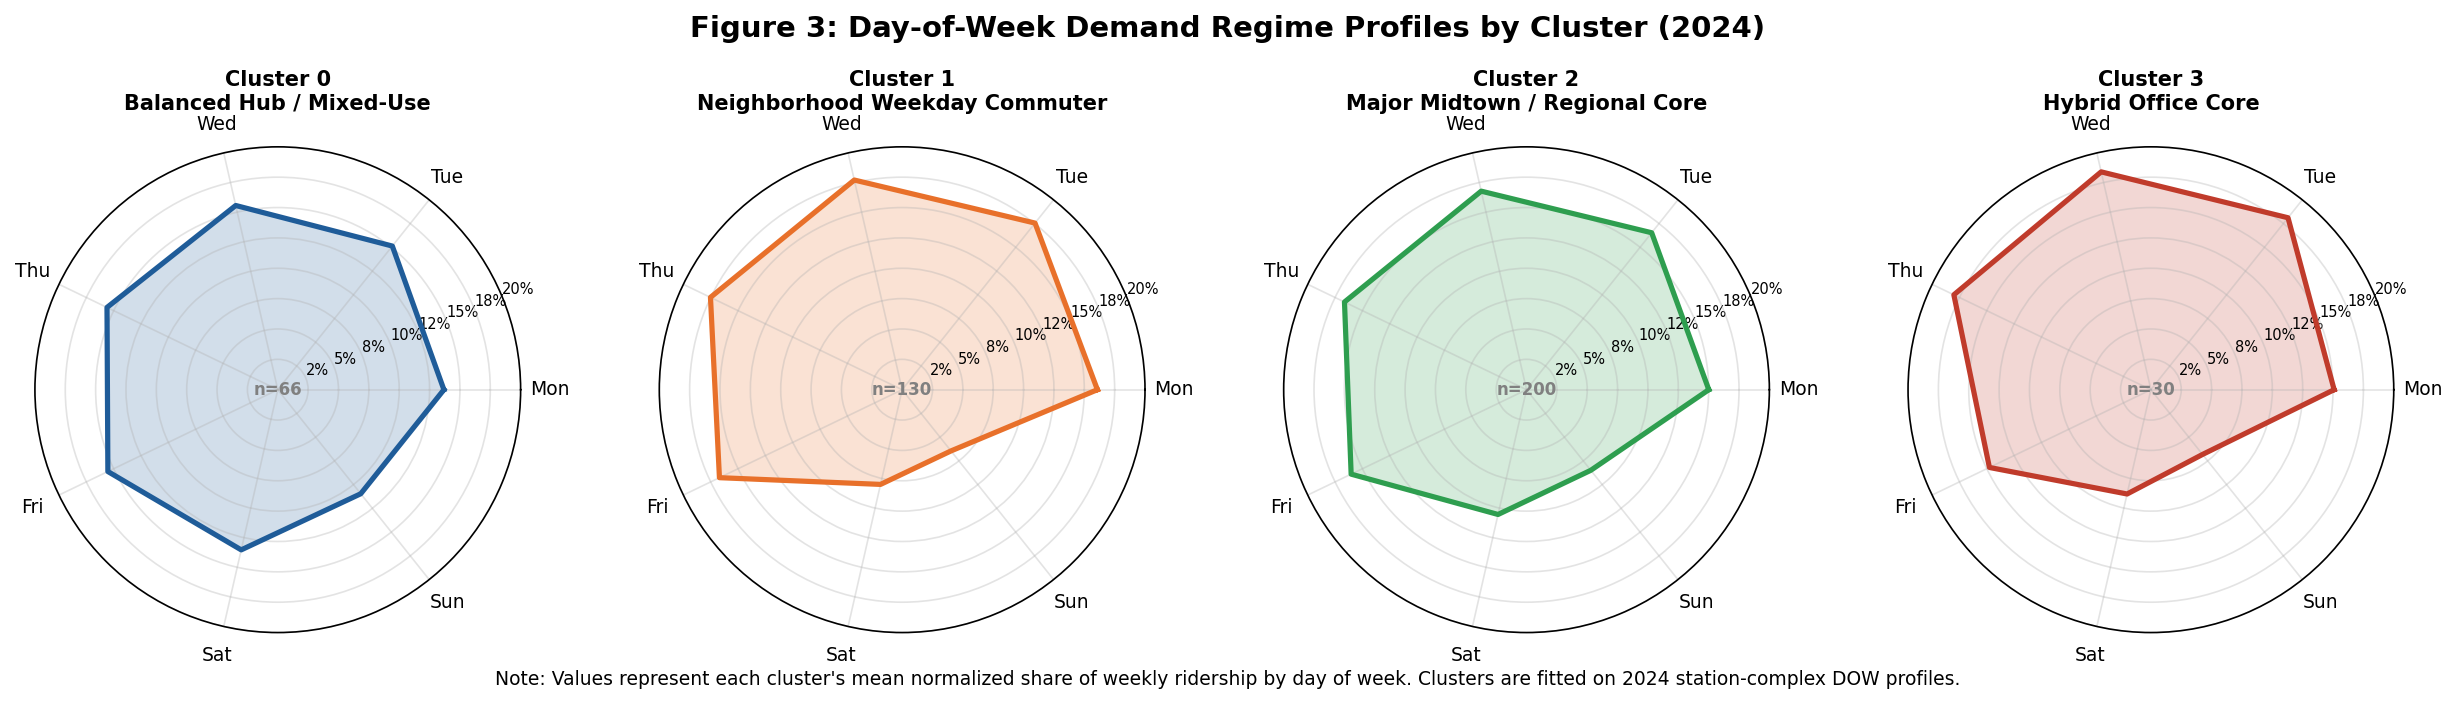

Figure 3 saved:
  /content/drive/MyDrive/dow_ridership_paper/outputs/figure3_radar_cluster_profiles.png
  /content/drive/MyDrive/dow_ridership_paper/outputs/figure3_radar_cluster_profiles.pdf


In [165]:
# ==============================================================
# Section 4.4 — Figure 3: Radar Chart of Cluster Profiles
#
# Purpose:
#   Visualizes the 7-day ridership profile for each cluster
#   as a radar/spider chart.
#
# Analysis period:
#   2024 Stabilized New Normal
#
# This becomes Figure 3 in the TRR paper.
#
# Outputs:
#   figure3_radar_cluster_profiles.png
#   figure3_radar_cluster_profiles.pdf
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# -------------------------------------------------------
# Required setup
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if "cluster_profiles" not in globals():
    raise RuntimeError(
        "cluster_profiles not found. Run Section 4.3 first."
    )

if "CLUSTER_LABELS" not in globals():
    if "cluster_label" in cluster_profiles.columns:
        CLUSTER_LABELS = cluster_profiles["cluster_label"].to_dict()
    else:
        raise RuntimeError(
            "CLUSTER_LABELS not found and cluster_profiles has no cluster_label column. "
            "Run Section 4.3 first."
        )

if "cluster_sizes" not in globals():
    if "n_station_complexes" in cluster_profiles.columns:
        cluster_sizes = cluster_profiles["n_station_complexes"]
    else:
        raise RuntimeError(
            "cluster_sizes not found and cluster_profiles has no n_station_complexes column. "
            "Run Section 4.3 first."
        )

missing_cols = [c for c in DOW_LABELS if c not in cluster_profiles.columns]

if missing_cols:
    raise RuntimeError(
        f"cluster_profiles is missing DOW columns: {missing_cols}\n"
        f"Columns found: {list(cluster_profiles.columns)}"
    )

if "PALETTE" not in globals():
    PALETTE = [
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
    ]


# -------------------------------------------------------
# Prepare radar geometry
# -------------------------------------------------------

categories = DOW_LABELS
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

cluster_ids = sorted(cluster_profiles.index.tolist())
n_clusters = len(cluster_ids)

# Use a common radial scale across all clusters
max_value = cluster_profiles[DOW_LABELS].max().max()
radial_max = np.ceil(max_value * 100) / 100

# Add a small buffer
radial_max = max(radial_max + 0.01, 0.20)


# -------------------------------------------------------
# Create subplot grid
# -------------------------------------------------------

n_cols = min(n_clusters, 5)
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 4.2 * n_rows),
    subplot_kw=dict(polar=True),
)

axes = np.array(axes).reshape(-1)


# -------------------------------------------------------
# Plot each cluster
# -------------------------------------------------------

for idx, c_id in enumerate(cluster_ids):
    ax = axes[idx]

    c_label = CLUSTER_LABELS.get(c_id, f"Cluster {c_id}")

    values = cluster_profiles.loc[c_id, DOW_LABELS].astype(float).tolist()
    values += values[:1]

    color = PALETTE[idx % len(PALETTE)]

    ax.plot(
        angles,
        values,
        linewidth=2.5,
        color=color,
    )

    ax.fill(
        angles,
        values,
        alpha=0.20,
        color=color,
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)

    ax.set_ylim(0, radial_max)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1, decimals=0)
    )

    ax.tick_params(axis="y", labelsize=7)

    n_stations = int(cluster_sizes.get(c_id, 0))

    ax.set_title(
        f"Cluster {c_id}\n{c_label}",
        fontsize=10,
        fontweight="bold",
        pad=18,
    )

    ax.text(
        0,
        0,
        f"n={n_stations}",
        ha="center",
        va="center",
        fontsize=8,
        color="gray",
        fontweight="bold",
    )

    # Optional subtle grid styling
    ax.grid(alpha=0.35)


# Hide unused axes if K does not fill the grid
for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)


# -------------------------------------------------------
# Title and note
# -------------------------------------------------------

fig.suptitle(
    "Figure 3: Day-of-Week Demand Regime Profiles by Cluster (2024)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

fig.text(
    0.5,
    -0.02,
    (
        "Note: Values represent each cluster's mean normalized share of weekly ridership "
        "by day of week. Clusters are fitted on 2024 station-complex DOW profiles."
    ),
    ha="center",
    va="top",
    fontsize=9,
)


plt.tight_layout()


# -------------------------------------------------------
# Save figure
# -------------------------------------------------------

fig_png_out = OUT_DIR / "figure3_radar_cluster_profiles.png"
fig_pdf_out = OUT_DIR / "figure3_radar_cluster_profiles.pdf"

plt.savefig(
    fig_png_out,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    fig_pdf_out,
    bbox_inches="tight",
)

plt.show()

print("Figure 3 saved:")
print(f"  {fig_png_out}")
print(f"  {fig_pdf_out}")

In [166]:
# ==============================================================
# Section 4.5 — Cluster Transition Analysis
# Pre-COVID Avg. → 2024
#
# Purpose:
#   Tracks how station complexes migrated between demand-regime
#   clusters from the 2017–2019 pre-COVID baseline to the
#   stabilized new normal in 2024.
#
# This produces Table 3 in the TRR paper.
#
# Method:
#   - Inner join station complexes present in both pre-COVID and 2024
#   - Cross-tabulate cluster assignments
#   - Report transition counts, row percentages, and stability metrics
#
# Inputs:
#   cluster_assignments["precovid"]
#   cluster_assignments[2024]
#
# Outputs:
#   table3_transition_matrix_counts.csv
#   table3_transition_matrix_row_pct.csv
#   station_transitions_precovid_to_2024.csv
#   top_cluster_migrants_precovid_to_2024.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Required setup
# -------------------------------------------------------

BASELINE_PERIOD = "precovid"
TARGET_PERIOD = 2024

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if "cluster_assignments" not in globals():
    raise RuntimeError(
        "cluster_assignments not found. Run Section 4.2 and Section 4.3 first."
    )

for period in [BASELINE_PERIOD, TARGET_PERIOD]:
    if period not in cluster_assignments:
        raise RuntimeError(
            f"cluster_assignments[{period!r}] not found. "
            f"Available keys: {list(cluster_assignments.keys())}\n"
            "Run Section 4.2 first, then Section 4.3 for labels."
        )

required_cols = ["station_complex_id", "complex_name", "cluster", "cluster_label"]

for period in [BASELINE_PERIOD, TARGET_PERIOD]:
    missing_cols = [
        c for c in required_cols
        if c not in cluster_assignments[period].columns
    ]

    if missing_cols:
        raise RuntimeError(
            f"cluster_assignments[{period!r}] is missing required columns: {missing_cols}\n"
            f"Columns found: {list(cluster_assignments[period].columns)}\n"
            "Run Section 4.3 to add cluster labels."
        )


# -------------------------------------------------------
# Prepare baseline and 2024 assignment tables
# -------------------------------------------------------

df_base = (
    cluster_assignments[BASELINE_PERIOD][
        [
            "station_complex_id",
            "complex_name",
            "cluster",
            "cluster_label",
        ]
    ]
    .copy()
    .rename(
        columns={
            "complex_name": "complex_name_precovid",
            "cluster": "cluster_precovid",
            "cluster_label": "label_precovid",
        }
    )
)

df_target = (
    cluster_assignments[TARGET_PERIOD][
        [
            "station_complex_id",
            "complex_name",
            "cluster",
            "cluster_label",
        ]
    ]
    .copy()
    .rename(
        columns={
            "complex_name": "complex_name_2024",
            "cluster": "cluster_2024",
            "cluster_label": "label_2024",
        }
    )
)


# -------------------------------------------------------
# Inner join common station-complex universe
# -------------------------------------------------------

transitions = df_base.merge(
    df_target,
    on="station_complex_id",
    how="inner",
)

if transitions.empty:
    raise RuntimeError(
        "No overlapping station_complex_id values between pre-COVID and 2024 "
        "cluster assignments. Check Section 2.2 station-complex join."
    )

# Prefer 2024 name where available, but keep both for QA
transitions["complex_name"] = transitions["complex_name_2024"].fillna(
    transitions["complex_name_precovid"]
)

transitions["cluster_changed"] = (
    transitions["cluster_precovid"] != transitions["cluster_2024"]
)

transitions["transition_label"] = (
    transitions["label_precovid"].astype(str)
    + " → "
    + transitions["label_2024"].astype(str)
)


# -------------------------------------------------------
# Transition matrix: counts
# -------------------------------------------------------

transition_matrix_counts = pd.crosstab(
    transitions["label_precovid"],
    transitions["label_2024"],
    margins=True,
    margins_name="Total",
)


# -------------------------------------------------------
# Transition matrix: row percentages
# -------------------------------------------------------

transition_matrix_row_pct = pd.crosstab(
    transitions["label_precovid"],
    transitions["label_2024"],
    normalize="index",
) * 100

transition_matrix_row_pct = transition_matrix_row_pct.round(1)


# -------------------------------------------------------
# Stability metrics
# -------------------------------------------------------

n_total = len(transitions)
n_stable = (~transitions["cluster_changed"]).sum()
n_migrated = transitions["cluster_changed"].sum()

pct_stable = n_stable / n_total * 100
pct_migrated = n_migrated / n_total * 100


# -------------------------------------------------------
# Merge 2024 volume data for top movers
# -------------------------------------------------------

if "dow_raw" in globals() and 2024 in dow_raw and "avg_weekday_entries" in dow_raw[2024].columns:
    volume_2024 = dow_raw[2024][
        ["station_complex_id", "avg_weekday_entries"]
    ].copy()

    transitions = transitions.merge(
        volume_2024,
        on="station_complex_id",
        how="left",
    )
else:
    transitions["avg_weekday_entries"] = np.nan


# -------------------------------------------------------
# Identify high-volume migrants
# -------------------------------------------------------

migrants = transitions[transitions["cluster_changed"]].copy()

top_migrants = (
    migrants
    .sort_values("avg_weekday_entries", ascending=False, na_position="last")
    .head(15)
    [
        [
            "station_complex_id",
            "complex_name",
            "label_precovid",
            "label_2024",
            "cluster_precovid",
            "cluster_2024",
            "avg_weekday_entries",
        ]
    ]
)


# -------------------------------------------------------
# Transition-pair summary
# -------------------------------------------------------

transition_pair_summary = (
    transitions
    .groupby(
        [
            "label_precovid",
            "label_2024",
            "cluster_changed",
        ],
        as_index=False,
    )
    .agg(
        n_station_complexes=("station_complex_id", "nunique"),
        mean_2024_weekday_entries=("avg_weekday_entries", "mean"),
    )
    .sort_values(
        ["n_station_complexes", "mean_2024_weekday_entries"],
        ascending=[False, False],
    )
)


# -------------------------------------------------------
# Print results
# -------------------------------------------------------

print("Table 3: Cluster Transition Matrix")
print("Pre-COVID Avg. (2017–2019) → 2024 Stabilized New Normal")
print("Rows = pre-COVID cluster | Columns = 2024 cluster")
print("-" * 90)
print(transition_matrix_counts.to_string())

print("\nTable 3 Row Percentages")
print("Rows sum to 100%, excluding Total row")
print("-" * 90)
print(transition_matrix_row_pct.to_string())

print("\nCluster Stability Metrics")
print("-" * 90)
print(f"Common station-complex universe:          {n_total:,}")
print(f"Same cluster in both periods:             {n_stable:,} ({pct_stable:.1f}%)")
print(f"Migrated to a different cluster:          {n_migrated:,} ({pct_migrated:.1f}%)")

print("\nTop High-Volume Stations That Migrated Between Clusters")
print("-" * 90)

if top_migrants.empty:
    print("No migrated stations found.")
else:
    print(top_migrants.to_string(index=False))

print("\nTransition Pair Summary")
print("-" * 90)
display(transition_pair_summary)


# -------------------------------------------------------
# Save outputs
# -------------------------------------------------------

counts_out = OUT_DIR / "table3_transition_matrix_counts.csv"
row_pct_out = OUT_DIR / "table3_transition_matrix_row_pct.csv"
transitions_out = OUT_DIR / "station_transitions_precovid_to_2024.csv"
top_migrants_out = OUT_DIR / "top_cluster_migrants_precovid_to_2024.csv"
pair_summary_out = OUT_DIR / "cluster_transition_pair_summary.csv"

transition_matrix_counts.to_csv(counts_out)
transition_matrix_row_pct.to_csv(row_pct_out)
transitions.to_csv(transitions_out, index=False)
top_migrants.to_csv(top_migrants_out, index=False)
transition_pair_summary.to_csv(pair_summary_out, index=False)

print("\nSaved outputs:")
print(f"  {counts_out}")
print(f"  {row_pct_out}")
print(f"  {transitions_out}")
print(f"  {top_migrants_out}")
print(f"  {pair_summary_out}")

Table 3: Cluster Transition Matrix
Pre-COVID Avg. (2017–2019) → 2024 Stabilized New Normal
Rows = pre-COVID cluster | Columns = 2024 cluster
------------------------------------------------------------------------------------------
label_2024                     Balanced Hub / Mixed-Use  Hybrid Office Core  Major Midtown / Regional Core  Neighborhood Weekday Commuter  Total
label_precovid                                                                                                                                  
Balanced Hub / Mixed-Use                             48                   2                            124                             49    223
Hybrid Office Core                                    0                   1                              0                              1      2
Major Midtown / Regional Core                         4                  14                             23                             45     86
Neighborhood Weekday Commuter              

,label_precovid,label_2024,cluster_changed,n_station_complexes,mean_2024_weekday_entries
2,Balanced Hub / Mixed-Use,Major Midtown / Regional Core,True,124,"8,145.77"
3,Balanced Hub / Mixed-Use,Neighborhood Weekday Commuter,True,49,"3,270.56"
0,Balanced Hub / Mixed-Use,Balanced Hub / Mixed-Use,False,48,"12,551.12"
9,Major Midtown / Regional Core,Neighborhood Weekday Commuter,True,45,"4,164.51"
8,Major Midtown / Regional Core,Major Midtown / Regional Core,False,23,"13,283.78"
7,Major Midtown / Regional Core,Hybrid Office Core,True,14,"23,087.95"
10,Neighborhood Weekday Commuter,Hybrid Office Core,True,4,"35,664.43"
6,Major Midtown / Regional Core,Balanced Hub / Mixed-Use,True,4,"6,999.80"
11,Neighborhood Weekday Commuter,Neighborhood Weekday Commuter,False,4,"2,462.05"
1,Balanced Hub / Mixed-Use,Hybrid Office Core,True,2,"15,370.05"



Saved outputs:
  /content/drive/MyDrive/dow_ridership_paper/outputs/table3_transition_matrix_counts.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/table3_transition_matrix_row_pct.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/station_transitions_precovid_to_2024.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/top_cluster_migrants_precovid_to_2024.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_transition_pair_summary.csv


---
## SECTION 5: Regression Analysis

### 5.1 Built Environment Feature Engineering

Spatially join ACS block-group data and LODES job counts to each station's 0.5-mile catchment area. Aggregate demographic and employment variables to the station complex level.

In [167]:
# ==============================================================
# Section 5.1 — Spatial Join: Built Environment → Stations
#
# Purpose:
#   Aggregates ACS and LODES data to station-complex-level features
#   using 0.5-mile station-complex buffers.
#
# Requires:
#   geopandas, shapely, requests
#
# Processing Steps:
#   1. Recover station-complex coordinates.
#   2. Project station coordinates to NYC local CRS (EPSG:2263).
#   3. Buffer each station complex by 0.5 miles.
#   4. Load NYC Census block group geometries.
#   5. Join ACS and LODES attributes to block groups.
#   6. Intersect block groups with station buffers.
#   7. Compute area-weighted ACS and LODES features.
#   8. Save station_features.csv.
#
# Output:
#   station_features.csv
# ==============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import requests

from pathlib import Path
from shapely.geometry import Point


# -------------------------------------------------------
# Required settings
# -------------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")

OUT_DIR.mkdir(parents=True, exist_ok=True)

if "CATCHMENT_MILES" not in globals():
    CATCHMENT_MILES = 0.5

BUFFER_FT = CATCHMENT_MILES * 5280

NYC_COUNTIES = ["061", "005", "047", "081", "085"]

ACS_FEATURE_YEAR = 2022
LODES_FEATURE_YEAR = 2021

ACS_FILE = OUT_DIR / f"acs_bg_{ACS_FEATURE_YEAR}.csv"
LODES_FILE = OUT_DIR / f"lodes_wac_{LODES_FEATURE_YEAR}.csv"

TIGER_URL = "https://www2.census.gov/geo/tiger/TIGER2022/BG/tl_2022_36_bg.zip"
tiger_cache = OUT_DIR / "tl_2022_36_bg.zip"


# -------------------------------------------------------
# Validate cluster assignments
# -------------------------------------------------------

if "cluster_assignments" not in globals():
    raise RuntimeError(
        "cluster_assignments not found. Run Sections 4.2 and 4.3 first."
    )

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. Available keys: {list(cluster_assignments.keys())}"
    )


# -------------------------------------------------------
# Recover station-complex coordinates
# -------------------------------------------------------

station_base = cluster_assignments[2024].copy()

required_base_cols = ["station_complex_id", "complex_name"]

missing_base_cols = [
    c for c in required_base_cols
    if c not in station_base.columns
]

if missing_base_cols:
    raise RuntimeError(
        f"cluster_assignments[2024] is missing required columns: {missing_base_cols}\n"
        f"Columns found: {list(station_base.columns)}"
    )

station_geo_df = station_base[
    ["station_complex_id", "complex_name"]
].drop_duplicates().copy()

station_geo_df["station_complex_id"] = pd.to_numeric(
    station_geo_df["station_complex_id"],
    errors="coerce"
)

# Try to use coordinates already in cluster_assignments[2024]
if {"complex_lat", "complex_lon"}.issubset(station_base.columns):
    coord_df = (
        station_base[
            [
                "station_complex_id",
                "complex_lat",
                "complex_lon",
            ]
        ]
        .drop_duplicates(subset=["station_complex_id"])
        .copy()
    )

    station_geo_df = station_geo_df.merge(
        coord_df,
        on="station_complex_id",
        how="left",
    )

else:
    station_geo_df["complex_lat"] = np.nan
    station_geo_df["complex_lon"] = np.nan


# Fallback: recover coordinates from station_complex_df
if station_geo_df[["complex_lat", "complex_lon"]].isna().any(axis=None):
    if "station_complex_df" not in globals():
        raise RuntimeError(
            "Missing coordinates in cluster_assignments[2024], and station_complex_df "
            "is not available. Reload the MTA station complex file before Section 5.1."
        )

    sc = station_complex_df.copy()
    sc.columns = sc.columns.str.strip().str.lower()

    required_sc_cols = {"complex_id", "latitude", "longitude"}

    missing_sc_cols = required_sc_cols - set(sc.columns)

    if missing_sc_cols:
        raise RuntimeError(
            f"station_complex_df is missing required columns: {missing_sc_cols}\n"
            f"Columns found: {list(sc.columns)}"
        )

    coord_lookup = (
        sc[
            [
                "complex_id",
                "latitude",
                "longitude",
            ]
        ]
        .copy()
        .rename(
            columns={
                "complex_id": "station_complex_id",
                "latitude": "complex_lat_lookup",
                "longitude": "complex_lon_lookup",
            }
        )
    )

    coord_lookup["station_complex_id"] = pd.to_numeric(
        coord_lookup["station_complex_id"],
        errors="coerce"
    )

    coord_lookup["complex_lat_lookup"] = pd.to_numeric(
        coord_lookup["complex_lat_lookup"],
        errors="coerce"
    )

    coord_lookup["complex_lon_lookup"] = pd.to_numeric(
        coord_lookup["complex_lon_lookup"],
        errors="coerce"
    )

    coord_lookup = coord_lookup.dropna(
        subset=[
            "station_complex_id",
            "complex_lat_lookup",
            "complex_lon_lookup",
        ]
    )

    coord_lookup = coord_lookup.drop_duplicates(
        subset=["station_complex_id"]
    )

    station_geo_df = station_geo_df.merge(
        coord_lookup,
        on="station_complex_id",
        how="left",
    )

    station_geo_df["complex_lat"] = station_geo_df["complex_lat"].fillna(
        station_geo_df["complex_lat_lookup"]
    )

    station_geo_df["complex_lon"] = station_geo_df["complex_lon"].fillna(
        station_geo_df["complex_lon_lookup"]
    )

    station_geo_df = station_geo_df.drop(
        columns=[
            c for c in ["complex_lat_lookup", "complex_lon_lookup"]
            if c in station_geo_df.columns
        ]
    )


station_geo_df["complex_lat"] = pd.to_numeric(
    station_geo_df["complex_lat"],
    errors="coerce"
)

station_geo_df["complex_lon"] = pd.to_numeric(
    station_geo_df["complex_lon"],
    errors="coerce"
)

before_coord_drop = len(station_geo_df)

station_geo_df = station_geo_df.dropna(
    subset=[
        "station_complex_id",
        "complex_lat",
        "complex_lon",
    ]
).copy()

after_coord_drop = len(station_geo_df)

print("Station coordinate recovery")
print("-" * 60)
print(f"Station complexes before coordinate drop: {before_coord_drop:,}")
print(f"Station complexes after coordinate drop:  {after_coord_drop:,}")
print(f"Dropped due to missing coordinates:       {before_coord_drop - after_coord_drop:,}")

if station_geo_df.empty:
    raise RuntimeError(
        "No station-complex coordinates available. Cannot build spatial features."
    )


# -------------------------------------------------------
# Build station GeoDataFrame and buffers
# -------------------------------------------------------

station_gdf = gpd.GeoDataFrame(
    station_geo_df,
    geometry=gpd.points_from_xy(
        station_geo_df["complex_lon"],
        station_geo_df["complex_lat"],
    ),
    crs="EPSG:4326",
)

station_gdf = station_gdf.to_crs("EPSG:2263")

station_buffers = station_gdf.copy()
station_buffers["geometry"] = station_gdf.geometry.buffer(BUFFER_FT)

print(
    f"\nStation buffers created: {len(station_buffers):,} station complexes "
    f"@ {CATCHMENT_MILES}-mile radius"
)


# -------------------------------------------------------
# Load NYC Census block group geometries
# -------------------------------------------------------

if not tiger_cache.exists():
    print("\nDownloading TIGER block group file...")
    resp = requests.get(TIGER_URL, timeout=120)
    resp.raise_for_status()
    tiger_cache.write_bytes(resp.content)
    print(f"Saved TIGER file: {tiger_cache}")
else:
    print(f"\nLoaded TIGER file from cache: {tiger_cache}")

bg_gdf = gpd.read_file(f"zip://{tiger_cache}")

bg_gdf = bg_gdf[
    (bg_gdf["STATEFP"] == "36")
    & (bg_gdf["COUNTYFP"].isin(NYC_COUNTIES))
].copy()

bg_gdf["GEOID"] = bg_gdf["GEOID"].astype(str).str.zfill(12)

bg_gdf = bg_gdf.to_crs("EPSG:2263")

bg_gdf["bg_area"] = bg_gdf.geometry.area

print(f"NYC block groups loaded: {len(bg_gdf):,}")


# -------------------------------------------------------
# Load ACS and LODES attributes
# -------------------------------------------------------

if not ACS_FILE.exists():
    raise FileNotFoundError(
        f"Missing ACS file: {ACS_FILE}\n"
        "Run Section 1.3a first to create ACS block group data."
    )

if not LODES_FILE.exists():
    raise FileNotFoundError(
        f"Missing LODES file: {LODES_FILE}\n"
        "Run Section 1.3b first to create LODES block group data."
    )

acs_df = pd.read_csv(
    ACS_FILE,
    dtype={"GEOID": str},
)

lodes_df = pd.read_csv(
    LODES_FILE,
    dtype={"GEOID": str},
)

acs_df["GEOID"] = acs_df["GEOID"].astype(str).str.zfill(12)
lodes_df["GEOID"] = lodes_df["GEOID"].astype(str).str.zfill(12)

print("\nLoaded built-environment attributes:")
print(f"  ACS {ACS_FEATURE_YEAR}:   {len(acs_df):,} block groups")
print(f"  LODES {LODES_FEATURE_YEAR}: {len(lodes_df):,} block groups")


# -------------------------------------------------------
# Join ACS + LODES to block group geometries
# -------------------------------------------------------

bg_attr = bg_gdf.merge(
    acs_df,
    on="GEOID",
    how="left",
)

bg_attr = bg_attr.merge(
    lodes_df,
    on="GEOID",
    how="left",
    suffixes=("", "_lodes"),
)

# Fill missing numeric attributes with 0 for sums;
# median income remains NaN-aware during weighted average.
numeric_cols = bg_attr.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    if col not in ["median_hh_income", "bg_area"]:
        bg_attr[col] = bg_attr[col].fillna(0)


# -------------------------------------------------------
# Spatial intersection: station buffers × block groups
# -------------------------------------------------------

print("\nIntersecting station buffers with block groups...")

intersections = gpd.overlay(
    station_buffers[
        [
            "station_complex_id",
            "complex_name",
            "complex_lat",
            "complex_lon",
            "geometry",
        ]
    ],
    bg_attr,
    how="intersection",
)

if intersections.empty:
    raise RuntimeError(
        "Spatial overlay produced no intersections. Check CRS and station coordinates."
    )

intersections["intersect_area"] = intersections.geometry.area

intersections["area_weight"] = (
    intersections["intersect_area"] /
    intersections["bg_area"].replace(0, np.nan)
)

intersections["area_weight"] = intersections["area_weight"].clip(
    lower=0,
    upper=1,
)

print(f"Intersections created: {len(intersections):,}")


# -------------------------------------------------------
# Identify ACS and LODES columns
# -------------------------------------------------------

acs_sum_cols = [
    c for c in [
        "total_population",
        "total_households",
        "no_vehicle_hh",
        "total_commuters",
        "transit_commuters",
    ]
    if c in intersections.columns
]

acs_weighted_mean_cols = [
    c for c in [
        "median_hh_income",
    ]
    if c in intersections.columns
]

lodes_sum_cols = [
    c for c in [
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
        "office_jobs",
        "essential_jobs",
    ]
    if c in intersections.columns
]

print("\nColumns available for spatial aggregation:")
print(f"  ACS sum columns:           {acs_sum_cols}")
print(f"  ACS weighted-mean columns: {acs_weighted_mean_cols}")
print(f"  LODES sum columns:         {lodes_sum_cols}")


# -------------------------------------------------------
# Aggregate area-weighted features to station buffers
# -------------------------------------------------------

feature_rows = []

for sid, group in intersections.groupby("station_complex_id"):
    row = {
        "station_complex_id": sid,
        "complex_name": group["complex_name"].iloc[0],
        "complex_lat": group["complex_lat"].iloc[0],
        "complex_lon": group["complex_lon"].iloc[0],
        "n_intersecting_block_groups": group["GEOID"].nunique(),
    }

    # Area-weighted ACS counts
    for col in acs_sum_cols:
        row[col] = (group[col] * group["area_weight"]).sum()

    # Area-weighted LODES job counts
    for col in lodes_sum_cols:
        row[col] = (group[col] * group["area_weight"]).sum()

    # Weighted mean / median-style attributes
    for col in acs_weighted_mean_cols:
        valid = group[col].notna() & group["area_weight"].notna()

        if valid.any() and group.loc[valid, "area_weight"].sum() > 0:
            row[col] = np.average(
                group.loc[valid, col],
                weights=group.loc[valid, "area_weight"],
            )
        else:
            row[col] = np.nan

    feature_rows.append(row)

station_features = pd.DataFrame(feature_rows)


# -------------------------------------------------------
# Derived built-environment features
# -------------------------------------------------------

def safe_divide(num, den):
    return np.where(
        den > 0,
        num / den,
        np.nan,
    )


if {"no_vehicle_hh", "total_households"}.issubset(station_features.columns):
    station_features["no_vehicle_share"] = safe_divide(
        station_features["no_vehicle_hh"],
        station_features["total_households"],
    )

if {"transit_commuters", "total_commuters"}.issubset(station_features.columns):
    station_features["transit_commute_share"] = safe_divide(
        station_features["transit_commuters"],
        station_features["total_commuters"],
    )

if {"office_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["office_job_share"] = safe_divide(
        station_features["office_jobs"],
        station_features["total_jobs"],
    )

if {"essential_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["essential_job_share"] = safe_divide(
        station_features["essential_jobs"],
        station_features["total_jobs"],
    )

if {"retail_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["retail_job_share"] = safe_divide(
        station_features["retail_jobs"],
        station_features["total_jobs"],
    )

# Density features per square mile of station buffer
buffer_area_sqmi = np.pi * (CATCHMENT_MILES ** 2)

if "total_population" in station_features.columns:
    station_features["population_density"] = (
        station_features["total_population"] / buffer_area_sqmi
    )

if "total_jobs" in station_features.columns:
    station_features["job_density"] = (
        station_features["total_jobs"] / buffer_area_sqmi
    )

if "office_jobs" in station_features.columns:
    station_features["office_job_density"] = (
        station_features["office_jobs"] / buffer_area_sqmi
    )

if "essential_jobs" in station_features.columns:
    station_features["essential_job_density"] = (
        station_features["essential_jobs"] / buffer_area_sqmi
    )


# -------------------------------------------------------
# Merge station features with 2024 cluster assignments
# -------------------------------------------------------

cluster_cols = [
    c for c in [
        "station_complex_id",
        "cluster",
        "cluster_label",
        "avg_weekday_entries",
    ]
    if c in cluster_assignments[2024].columns
]

station_features = station_features.merge(
    cluster_assignments[2024][cluster_cols].drop_duplicates(
        subset=["station_complex_id"]
    ),
    on="station_complex_id",
    how="left",
)


# -------------------------------------------------------
# Save and inspect output
# -------------------------------------------------------

station_features_out = OUT_DIR / "station_features.csv"

station_features.to_csv(station_features_out, index=False)

print("\nStation built-environment features saved:")
print(f"  File: {station_features_out}")
print(f"  Rows: {len(station_features):,}")
print(f"  Station complexes with cluster label: {station_features['cluster_label'].notna().sum():,}")

print("\nFeature columns:")
print(station_features.columns.tolist())

print("\nPreview:")
display(station_features.head())

Station coordinate recovery
------------------------------------------------------------
Station complexes before coordinate drop: 426
Station complexes after coordinate drop:  426
Dropped due to missing coordinates:       0

Station buffers created: 426 station complexes @ 0.5-mile radius

Loaded TIGER file from cache: /content/drive/MyDrive/dow_ridership_paper/outputs/tl_2022_36_bg.zip
NYC block groups loaded: 6,807

Loaded built-environment attributes:
  ACS 2022:   6,807 block groups
  LODES 2021: 15,678 block groups

Intersecting station buffers with block groups...
Intersections created: 19,750

Columns available for spatial aggregation:
  ACS sum columns:           ['total_population', 'total_households', 'no_vehicle_hh', 'total_commuters', 'transit_commuters']
  ACS weighted-mean columns: ['median_hh_income']
  LODES sum columns:         ['total_jobs', 'finance_jobs', 'professional_jobs', 'retail_jobs', 'healthcare_jobs', 'food_service_jobs', 'office_jobs', 'essential_jobs']

S

,station_complex_id,complex_name,complex_lat,complex_lon,n_intersecting_block_groups,total_population,total_households,no_vehicle_hh,total_commuters,transit_commuters,total_jobs,finance_jobs,professional_jobs,retail_jobs,healthcare_jobs,food_service_jobs,office_jobs,essential_jobs,median_hh_income,no_vehicle_share,transit_commute_share,office_job_share,essential_job_share,retail_job_share,population_density,job_density,office_job_density,essential_job_density,cluster,cluster_label,avg_weekday_entries
0,1.00,"Astoria-Ditmars Blvd (N,W)",40.78,-73.91,44,"33,232.34","13,962.19","6,677.83","19,241.01","10,288.43","5,150.61",56.44,336.52,731.50,405.98,994.71,392.95,"1,400.69","102,278.75",0.48,0.53,0.08,0.27,0.14,"42,312.72","6,557.96",500.32,"1,783.41",2,Major Midtown / Regional Core,"10,661.31"
1,2.00,"Astoria Blvd (N,W)",40.77,-73.92,50,"39,025.94","17,552.98","10,565.19","23,941.15","13,681.91","9,761.42",35.92,535.38,"1,069.36",448.67,"1,416.44",571.30,"1,865.11","104,337.69",0.60,0.57,0.06,0.19,0.11,"49,689.37","12,428.62",727.40,"2,374.73",2,Major Midtown / Regional Core,"7,803.14"
2,3.00,"30 Av (N,W)",40.77,-73.92,51,"44,212.55","20,886.85","13,825.96","27,261.55","16,442.40","10,908.25",52.38,464.52,"1,441.28",533.57,"1,743.47",516.90,"2,277.04","107,078.05",0.66,0.60,0.05,0.21,0.13,"56,293.16","13,888.81",658.13,"2,899.22",2,Major Midtown / Regional Core,"9,777.93"
3,4.00,"Broadway (N,W)",40.76,-73.93,47,"45,079.19","21,359.13","14,694.72","27,106.59","16,787.64","10,975.85",66.63,458.90,"1,573.18",967.62,"1,787.11",525.53,"2,754.74","103,790.53",0.69,0.62,0.05,0.25,0.14,"57,396.61","13,974.89",669.13,"3,507.44",2,Major Midtown / Regional Core,"8,795.59"
4,5.00,"36 Av (N,W)",40.76,-73.93,37,"29,516.36","13,206.40","8,964.97","16,087.96","9,673.35","13,629.27",873.13,728.89,"1,410.84",982.68,"1,165.70","1,602.02","2,148.38","94,171.73",0.68,0.60,0.12,0.16,0.10,"37,581.40","17,353.32","2,039.76","2,735.40",2,Major Midtown / Regional Core,"4,770.62"


In [168]:
# ==============================================================
# Quick QA — Check ACS household fields before regression
# ==============================================================

acs_check = pd.read_csv(OUT_DIR / "acs_bg_2022.csv", dtype={"GEOID": str})

print("ACS 2022 columns:")
print(acs_check.columns.tolist())

check_cols = [
    "total_population",
    "total_households",
    "no_vehicle_hh",
    "total_commuters",
    "transit_commuters",
    "median_hh_income",
]

print("\nACS 2022 summary:")
print(acs_check[[c for c in check_cols if c in acs_check.columns]].describe().round(2).to_string())

print("\nNumber of nonzero values:")
for c in check_cols:
    if c in acs_check.columns:
        print(f"{c}: {(acs_check[c] > 0).sum():,} nonzero out of {len(acs_check):,}")

ACS 2022 columns:
['GEOID', 'NAME', 'county_fips', 'county_name', 'total_population', 'total_households', 'no_vehicle_hh', 'median_hh_income', 'total_commuters', 'transit_commuters']

ACS 2022 summary:
       total_population  total_households  no_vehicle_hh  total_commuters  transit_commuters  median_hh_income
count          6,807.00          6,807.00       6,807.00         6,807.00           6,807.00          5,547.00
mean           1,266.71            482.27         263.82           586.42             277.48         92,996.82
std              706.76            288.70         241.64           363.18             215.86         50,886.04
min                0.00              0.00           0.00             0.00               0.00          2,499.00
25%              835.00            308.00          81.00           364.00             128.00         58,217.00
50%            1,210.00            447.00         206.00           546.00             239.00         83,779.00
75%            1,633.

In [169]:
# ==============================================================
# Section 5.2 — Feature Assembly and Engineering
#
# Purpose:
#   Loads station-level built-environment features created in
#   Section 5.1 and creates modeling-ready engineered variables.
#
# Inputs:
#   station_features.csv
#
# Engineered features:
#   pct_no_vehicle           — share of households with no vehicle
#   pct_transit_commute      — share of workers commuting by transit
#   office_job_density       — office jobs per square mile
#   retail_job_density       — retail jobs per square mile
#   essential_job_density    — essential jobs per square mile
#   log_office_jobs          — log1p(office_jobs)
#   log_total_jobs           — log1p(total_jobs)
#   log_pop_density          — log1p(population_density)
#   log_median_income        — log1p(median_hh_income)
#
# Outputs:
#   station_features_engineered.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Load station features from Section 5.1
# -------------------------------------------------------

features_cache = OUT_DIR / "station_features.csv"

if not features_cache.exists():
    raise FileNotFoundError(
        f"Missing file: {features_cache}\n"
        "Run Section 5.1 first to create station_features.csv."
    )

station_features = pd.read_csv(features_cache)

print("Station features loaded.")
print(f"  File: {features_cache}")
print(f"  Rows: {len(station_features):,}")
print(f"  Columns: {len(station_features.columns):,}")


# -------------------------------------------------------
# Basic validation
# -------------------------------------------------------

required_id_cols = [
    "station_complex_id",
    "complex_name",
]

missing_id_cols = [
    c for c in required_id_cols
    if c not in station_features.columns
]

if missing_id_cols:
    raise RuntimeError(
        f"station_features is missing required ID columns: {missing_id_cols}\n"
        f"Columns found: {list(station_features.columns)}"
    )


# -------------------------------------------------------
# Ensure numeric columns are numeric
# -------------------------------------------------------

numeric_candidate_cols = [
    "total_population",
    "total_households",
    "no_vehicle_hh",
    "total_commuters",
    "transit_commuters",
    "median_hh_income",
    "total_jobs",
    "finance_jobs",
    "professional_jobs",
    "retail_jobs",
    "healthcare_jobs",
    "food_service_jobs",
    "office_jobs",
    "essential_jobs",
    "population_density",
    "job_density",
    "office_job_density",
    "essential_job_density",
    "retail_job_density",
    "avg_weekday_entries",
]

for col in numeric_candidate_cols:
    if col in station_features.columns:
        station_features[col] = pd.to_numeric(
            station_features[col],
            errors="coerce"
        )


# -------------------------------------------------------
# Helper for safe division
# -------------------------------------------------------

def safe_divide(num, den):
    """
    Vectorized safe division. Returns NaN when denominator is zero or missing.
    """
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")

    return np.where(
        den > 0,
        num / den,
        np.nan,
    )


# -------------------------------------------------------
# Harmonize feature names
# -------------------------------------------------------
# Section 5.1 may have created no_vehicle_share and
# transit_commute_share. For modeling, also create pct_* aliases.

if {"no_vehicle_hh", "total_households"}.issubset(station_features.columns):
    station_features["pct_no_vehicle"] = safe_divide(
        station_features["no_vehicle_hh"],
        station_features["total_households"],
    )

elif "no_vehicle_share" in station_features.columns:
    station_features["pct_no_vehicle"] = station_features["no_vehicle_share"]


if {"transit_commuters", "total_commuters"}.issubset(station_features.columns):
    station_features["pct_transit_commute"] = safe_divide(
        station_features["transit_commuters"],
        station_features["total_commuters"],
    )

elif "transit_commute_share" in station_features.columns:
    station_features["pct_transit_commute"] = station_features["transit_commute_share"]


# -------------------------------------------------------
# Job share features
# -------------------------------------------------------

if {"office_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["office_job_share"] = safe_divide(
        station_features["office_jobs"],
        station_features["total_jobs"],
    )

if {"retail_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["retail_job_share"] = safe_divide(
        station_features["retail_jobs"],
        station_features["total_jobs"],
    )

if {"essential_jobs", "total_jobs"}.issubset(station_features.columns):
    station_features["essential_job_share"] = safe_divide(
        station_features["essential_jobs"],
        station_features["total_jobs"],
    )


# -------------------------------------------------------
# Density features
# -------------------------------------------------------
# Section 5.1 creates densities per square mile.
# If missing, recompute from CATCHMENT_MILES.

if "CATCHMENT_MILES" not in globals():
    CATCHMENT_MILES = 0.5

buffer_area_sqmi = np.pi * (CATCHMENT_MILES ** 2)

if "population_density" not in station_features.columns:
    if "total_population" in station_features.columns:
        station_features["population_density"] = (
            station_features["total_population"] / buffer_area_sqmi
        )

if "job_density" not in station_features.columns:
    if "total_jobs" in station_features.columns:
        station_features["job_density"] = (
            station_features["total_jobs"] / buffer_area_sqmi
        )

if "office_job_density" not in station_features.columns:
    if "office_jobs" in station_features.columns:
        station_features["office_job_density"] = (
            station_features["office_jobs"] / buffer_area_sqmi
        )

if "retail_job_density" not in station_features.columns:
    if "retail_jobs" in station_features.columns:
        station_features["retail_job_density"] = (
            station_features["retail_jobs"] / buffer_area_sqmi
        )

if "essential_job_density" not in station_features.columns:
    if "essential_jobs" in station_features.columns:
        station_features["essential_job_density"] = (
            station_features["essential_jobs"] / buffer_area_sqmi
        )


# -------------------------------------------------------
# Log transformations for skewed variables
# -------------------------------------------------------

log_source_cols = [
    "office_jobs",
    "total_jobs",
    "retail_jobs",
    "essential_jobs",
    "population_density",
    "job_density",
    "office_job_density",
    "retail_job_density",
    "essential_job_density",
    "median_hh_income",
]

for col in log_source_cols:
    if col in station_features.columns:
        safe_values = station_features[col].clip(lower=0)
        station_features[f"log_{col}"] = np.log1p(safe_values)


# Backward-compatible aliases used in older notebook sections
if "log_population_density" in station_features.columns:
    station_features["log_pop_density"] = station_features["log_population_density"]
elif "population_density" in station_features.columns:
    station_features["log_pop_density"] = np.log1p(
        station_features["population_density"].clip(lower=0)
    )

if "log_median_hh_income" in station_features.columns:
    station_features["log_median_income"] = station_features["log_median_hh_income"]
elif "median_hh_income" in station_features.columns:
    station_features["log_median_income"] = np.log1p(
        station_features["median_hh_income"].clip(lower=0)
    )


# -------------------------------------------------------
# Clean impossible or extreme share values
# -------------------------------------------------------

share_cols = [
    "pct_no_vehicle",
    "pct_transit_commute",
    "office_job_share",
    "retail_job_share",
    "essential_job_share",
    "no_vehicle_share",
    "transit_commute_share",
]

for col in share_cols:
    if col in station_features.columns:
        station_features[col] = pd.to_numeric(
            station_features[col],
            errors="coerce"
        )
        station_features[col] = station_features[col].clip(lower=0, upper=1)


# -------------------------------------------------------
# Add cluster labels if missing
# -------------------------------------------------------

if "cluster_label" not in station_features.columns:
    if "cluster_assignments" in globals() and 2024 in cluster_assignments:
        cluster_cols = [
            c for c in [
                "station_complex_id",
                "cluster",
                "cluster_label",
                "avg_weekday_entries",
            ]
            if c in cluster_assignments[2024].columns
        ]

        station_features = station_features.merge(
            cluster_assignments[2024][cluster_cols].drop_duplicates(
                subset=["station_complex_id"]
            ),
            on="station_complex_id",
            how="left",
        )


# -------------------------------------------------------
# Modeling feature list
# -------------------------------------------------------

MODEL_FEATURES = [
    "pct_no_vehicle",
    "pct_transit_commute",
    "office_job_share",
    "retail_job_share",
    "essential_job_share",
    "log_office_jobs",
    "log_total_jobs",
    "log_retail_jobs",
    "log_essential_jobs",
    "log_pop_density",
    "log_median_income",
    "log_job_density",
    "log_office_job_density",
    "log_retail_job_density",
    "log_essential_job_density",
]

available_model_features = [
    c for c in MODEL_FEATURES
    if c in station_features.columns
]

missing_model_features = [
    c for c in MODEL_FEATURES
    if c not in station_features.columns
]


# -------------------------------------------------------
# QA summary
# -------------------------------------------------------

print("\n================ FEATURE ASSEMBLY QA ================\n")

print("Available modeling features:")
for c in available_model_features:
    print(f"  {c}")

if missing_model_features:
    print("\nMissing optional modeling features:")
    for c in missing_model_features:
        print(f"  {c}")

print("\nMissing values in available modeling features:")
print(
    station_features[available_model_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDescriptive statistics:")
display(
    station_features[available_model_features]
    .describe()
    .T
    .round(3)
)


# -------------------------------------------------------
# Save engineered feature table
# -------------------------------------------------------

features_engineered_out = OUT_DIR / "station_features_engineered.csv"

station_features.to_csv(features_engineered_out, index=False)

print("\nStation engineered features saved:")
print(f"  File: {features_engineered_out}")
print(f"  Rows: {len(station_features):,}")
print(f"  Columns: {len(station_features.columns):,}")

print("\nPreview:")
display(station_features.head())

Station features loaded.
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_features.csv
  Rows: 426
  Columns: 31

================ FEATURE ASSEMBLY QA ================

Available modeling features:
  pct_no_vehicle
  pct_transit_commute
  office_job_share
  retail_job_share
  essential_job_share
  log_office_jobs
  log_total_jobs
  log_retail_jobs
  log_essential_jobs
  log_pop_density
  log_median_income
  log_job_density
  log_office_job_density
  log_retail_job_density
  log_essential_job_density

Missing values in available modeling features:
pct_no_vehicle               0
pct_transit_commute          0
office_job_share             0
retail_job_share             0
essential_job_share          0
log_office_jobs              0
log_total_jobs               0
log_retail_jobs              0
log_essential_jobs           0
log_pop_density              0
log_median_income            0
log_job_density              0
log_office_job_density       0
log_retail_job_density    

,count,mean,std,min,25%,50%,75%,max
pct_no_vehicle,426.00,0.63,0.15,0.09,0.52,0.67,0.75,0.91
pct_transit_commute,426.00,0.52,0.10,0.18,0.44,0.52,0.60,0.70
office_job_share,426.00,0.08,0.10,0.00,0.02,0.03,0.07,0.47
retail_job_share,426.00,0.10,0.05,0.00,0.06,0.09,0.12,0.37
essential_job_share,426.00,0.21,0.12,0.02,0.12,0.19,0.28,0.86
log_office_jobs,426.00,6.37,2.28,0.80,4.93,5.85,7.21,12.04
log_total_jobs,426.00,9.61,1.30,6.55,8.75,9.29,10.19,13.17
log_retail_jobs,426.00,7.10,1.12,0.95,6.45,6.98,7.63,9.99
log_essential_jobs,426.00,7.86,1.07,3.20,7.18,7.63,8.50,10.43
log_pop_density,426.00,10.81,0.52,7.35,10.58,10.89,11.13,11.86



Station engineered features saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_features_engineered.csv
  Rows: 426
  Columns: 46

Preview:


,station_complex_id,complex_name,complex_lat,complex_lon,n_intersecting_block_groups,total_population,total_households,no_vehicle_hh,total_commuters,transit_commuters,total_jobs,finance_jobs,professional_jobs,retail_jobs,healthcare_jobs,food_service_jobs,office_jobs,essential_jobs,median_hh_income,no_vehicle_share,transit_commute_share,office_job_share,essential_job_share,retail_job_share,population_density,job_density,office_job_density,essential_job_density,cluster,cluster_label,avg_weekday_entries,pct_no_vehicle,pct_transit_commute,retail_job_density,log_office_jobs,log_total_jobs,log_retail_jobs,log_essential_jobs,log_population_density,log_job_density,log_office_job_density,log_retail_job_density,log_essential_job_density,log_median_hh_income,log_pop_density,log_median_income
0,1.00,"Astoria-Ditmars Blvd (N,W)",40.78,-73.91,44,"33,232.34","13,962.19","6,677.83","19,241.01","10,288.43","5,150.61",56.44,336.52,731.50,405.98,994.71,392.95,"1,400.69","102,278.75",0.48,0.53,0.08,0.27,0.14,"42,312.72","6,557.96",500.32,"1,783.41",2,Major Midtown / Regional Core,"10,661.31",0.48,0.53,931.37,5.98,8.55,6.60,7.25,10.65,8.79,6.22,6.84,7.49,11.54,10.65,11.54
1,2.00,"Astoria Blvd (N,W)",40.77,-73.92,50,"39,025.94","17,552.98","10,565.19","23,941.15","13,681.91","9,761.42",35.92,535.38,"1,069.36",448.67,"1,416.44",571.30,"1,865.11","104,337.69",0.60,0.57,0.06,0.19,0.11,"49,689.37","12,428.62",727.40,"2,374.73",2,Major Midtown / Regional Core,"7,803.14",0.60,0.57,"1,361.55",6.35,9.19,6.98,7.53,10.81,9.43,6.59,7.22,7.77,11.56,10.81,11.56
2,3.00,"30 Av (N,W)",40.77,-73.92,51,"44,212.55","20,886.85","13,825.96","27,261.55","16,442.40","10,908.25",52.38,464.52,"1,441.28",533.57,"1,743.47",516.90,"2,277.04","107,078.05",0.66,0.60,0.05,0.21,0.13,"56,293.16","13,888.81",658.13,"2,899.22",2,Major Midtown / Regional Core,"9,777.93",0.66,0.60,"1,835.09",6.25,9.30,7.27,7.73,10.94,9.54,6.49,7.52,7.97,11.58,10.94,11.58
3,4.00,"Broadway (N,W)",40.76,-73.93,47,"45,079.19","21,359.13","14,694.72","27,106.59","16,787.64","10,975.85",66.63,458.90,"1,573.18",967.62,"1,787.11",525.53,"2,754.74","103,790.53",0.69,0.62,0.05,0.25,0.14,"57,396.61","13,974.89",669.13,"3,507.44",2,Major Midtown / Regional Core,"8,795.59",0.69,0.62,"2,003.04",6.27,9.30,7.36,7.92,10.96,9.55,6.51,7.60,8.16,11.55,10.96,11.55
4,5.00,"36 Av (N,W)",40.76,-73.93,37,"29,516.36","13,206.40","8,964.97","16,087.96","9,673.35","13,629.27",873.13,728.89,"1,410.84",982.68,"1,165.70","1,602.02","2,148.38","94,171.73",0.68,0.60,0.12,0.16,0.10,"37,581.40","17,353.32","2,039.76","2,735.40",2,Major Midtown / Regional Core,"4,770.62",0.68,0.60,"1,796.33",7.38,9.52,7.25,7.67,10.53,9.76,7.62,7.49,7.91,11.45,10.53,11.45


In [170]:
# ==============================================================
# Section 5.3 — Regression Model: Multinomial Logistic
#
# Purpose:
#   Explains 2024 cluster membership using built-environment
#   features via multinomial logistic regression.
#
# Dependent variable:
#   2024 cluster assignment
#
# Independent variables:
#   Built-environment features from station_features_engineered.csv
#
# Estimation:
#   statsmodels MNLogit for coefficients, standard errors, p-values
#
# Validation:
#   Stratified cross-validation using sklearn multinomial logistic regression
#
# Outputs:
#   table4_regression_results.csv
#   regression_dataset_2024.csv
#   regression_cv_results.csv
# ==============================================================

import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report


# -------------------------------------------------------
# Load engineered station features
# -------------------------------------------------------

features_engineered_path = OUT_DIR / "station_features_engineered.csv"

if features_engineered_path.exists():
    station_features = pd.read_csv(features_engineered_path)
    print(f"Loaded engineered station features: {features_engineered_path}")
else:
    raise FileNotFoundError(
        f"Missing file: {features_engineered_path}\n"
        "Run Section 5.2 first."
    )


# -------------------------------------------------------
# Validate cluster assignments
# -------------------------------------------------------

if "cluster_assignments" not in globals():
    raise RuntimeError(
        "cluster_assignments not found. Run Sections 4.2 and 4.3 first."
    )

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. Available keys: {list(cluster_assignments.keys())}"
    )

required_cluster_cols = [
    "station_complex_id",
    "complex_name",
    "cluster",
    "cluster_label",
]

missing_cluster_cols = [
    c for c in required_cluster_cols
    if c not in cluster_assignments[2024].columns
]

if missing_cluster_cols:
    raise RuntimeError(
        f"cluster_assignments[2024] is missing required columns: {missing_cluster_cols}\n"
        "Run Section 4.3 to add cluster labels."
    )


# -------------------------------------------------------
# Assemble regression dataset
# -------------------------------------------------------

cluster_2024 = cluster_assignments[2024][
    required_cluster_cols
].drop_duplicates(
    subset=["station_complex_id"]
).copy()

reg_df = cluster_2024.merge(
    station_features,
    on="station_complex_id",
    how="inner",
    suffixes=("", "_feature"),
)

# Clean duplicate name/label columns if created by merge
if "complex_name_feature" in reg_df.columns:
    reg_df = reg_df.drop(columns=["complex_name_feature"])

if "cluster_feature" in reg_df.columns:
    reg_df = reg_df.drop(columns=["cluster_feature"])

if "cluster_label_feature" in reg_df.columns:
    reg_df = reg_df.drop(columns=["cluster_label_feature"])


print("\nRegression dataset assembled")
print("-" * 60)
print(f"Rows after merge: {len(reg_df):,}")
print("\nCluster distribution:")
print(reg_df["cluster"].value_counts().sort_index())


# -------------------------------------------------------
# Feature selection
# -------------------------------------------------------
# These are chosen to avoid excessive collinearity.
# We use shares and log-scaled density/count features.

CANDIDATE_FEATURE_COLS = [
    "log_office_jobs",
    "log_total_jobs",
    "log_pop_density",
    "log_median_income",
    "pct_no_vehicle",
    "pct_transit_commute",
    "office_job_share",
    "retail_job_share",
    "essential_job_share",
    "log_retail_job_density",
    "log_essential_job_density",
]

FEATURE_COLS = [
    c for c in CANDIDATE_FEATURE_COLS
    if c in reg_df.columns
]

missing_features = [
    c for c in CANDIDATE_FEATURE_COLS
    if c not in reg_df.columns
]

print("\nAvailable regression features:")
for c in FEATURE_COLS:
    print(f"  {c}")

if missing_features:
    print("\nMissing optional regression features:")
    for c in missing_features:
        print(f"  {c}")

if len(FEATURE_COLS) < 3:
    raise RuntimeError(
        f"Too few regression features available: {FEATURE_COLS}\n"
        "Check Section 5.2 feature engineering output."
    )


# -------------------------------------------------------
# Clean regression dataset
# -------------------------------------------------------

for col in FEATURE_COLS:
    reg_df[col] = pd.to_numeric(
        reg_df[col],
        errors="coerce"
    )

reg_df["cluster"] = pd.to_numeric(
    reg_df["cluster"],
    errors="coerce"
)

reg_df = reg_df.dropna(
    subset=["cluster"] + FEATURE_COLS
).copy()

reg_df["cluster"] = reg_df["cluster"].astype(int)

print(f"\nRows after dropping missing regression fields: {len(reg_df):,}")

if reg_df["cluster"].nunique() < 2:
    raise RuntimeError(
        "Regression requires at least two cluster categories after cleaning."
    )

print("\nFinal cluster distribution:")
print(reg_df["cluster"].value_counts().sort_index())


# -------------------------------------------------------
# Drop very rare clusters if needed
# -------------------------------------------------------
# statsmodels MNLogit can fail if a cluster has too few observations.
# This keeps all clusters with at least MIN_CLUSTER_N observations.

MIN_CLUSTER_N = 5

cluster_counts = reg_df["cluster"].value_counts()

rare_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_N].index.tolist()

if rare_clusters:
    print(
        f"\nWarning: dropping rare clusters with fewer than {MIN_CLUSTER_N} observations: "
        f"{rare_clusters}"
    )

    reg_df = reg_df[
        ~reg_df["cluster"].isin(rare_clusters)
    ].copy()

print(f"Rows after rare-cluster filter: {len(reg_df):,}")
print("\nRegression cluster distribution after rare-cluster filter:")
print(reg_df["cluster"].value_counts().sort_index())


# -------------------------------------------------------
# Standardize features
# -------------------------------------------------------

X_raw = reg_df[FEATURE_COLS].astype(float).copy()
y_reg = reg_df["cluster"].astype(int).copy()

scaler_reg = StandardScaler()

X_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_raw),
    columns=FEATURE_COLS,
    index=reg_df.index,
)


# -------------------------------------------------------
# Fit Multinomial Logit via statsmodels
# -------------------------------------------------------

X_sm = sm.add_constant(X_scaled, has_constant="add")

mnlogit = sm.MNLogit(y_reg, X_sm)

try:
    result = mnlogit.fit(
        method="bfgs",
        maxiter=1000,
        disp=False,
    )

    print("\nMultinomial Logit Results Summary:")
    print(result.summary())

except Exception as e:
    print("\nBFGS failed. Trying Newton solver...")
    print(f"Original error: {e}")

    result = mnlogit.fit(
        method="newton",
        maxiter=1000,
        disp=False,
    )

    print("\nMultinomial Logit Results Summary:")
    print(result.summary())


# -------------------------------------------------------
# Convert statsmodels output to clean coefficient table
# -------------------------------------------------------

params = result.params
bse = result.bse
pvalues = result.pvalues

coef_rows = []

for outcome in params.columns:
    for variable in params.index:
        coef = params.loc[variable, outcome]
        se = bse.loc[variable, outcome]
        pval = pvalues.loc[variable, outcome]

        coef_rows.append(
            {
                "outcome_cluster_vs_reference": outcome,
                "variable": variable,
                "coefficient": coef,
                "std_error": se,
                "p_value": pval,
                "odds_ratio": np.exp(coef),
            }
        )

regression_results = pd.DataFrame(coef_rows)

# Add significance stars
def p_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "."
    return ""

regression_results["significance"] = regression_results["p_value"].apply(p_stars)


# -------------------------------------------------------
# Save statsmodels outputs
# -------------------------------------------------------

regression_out = OUT_DIR / "table4_regression_results.csv"
reg_dataset_out = OUT_DIR / "regression_dataset_2024.csv"

regression_results.to_csv(regression_out, index=False)
reg_df.to_csv(reg_dataset_out, index=False)

print("\nSaved regression outputs:")
print(f"  {regression_out}")
print(f"  {reg_dataset_out}")


# -------------------------------------------------------
# Sklearn cross-validation
# -------------------------------------------------------

cv_min_class_count = y_reg.value_counts().min()

N_SPLITS = min(5, cv_min_class_count)

if N_SPLITS < 2:
    print(
        "\nSkipping cross-validation: at least one class has fewer than 2 observations."
    )

    cv_results = pd.DataFrame(
        {
            "metric": ["cv_accuracy_mean", "cv_accuracy_std"],
            "value": [np.nan, np.nan],
        }
    )

else:
    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logit",
                LogisticRegression(
                    multi_class="multinomial",
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=42,
    )

    cv_scores = cross_val_score(
        clf,
        X_raw,
        y_reg,
        cv=cv,
        scoring="accuracy",
    )

    print("\nCross-validation accuracy")
    print("-" * 60)
    print(f"Folds: {N_SPLITS}")
    print(f"Scores: {np.round(cv_scores, 3)}")
    print(f"Mean accuracy: {cv_scores.mean():.3f}")
    print(f"Std accuracy:  {cv_scores.std():.3f}")

    cv_results = pd.DataFrame(
        {
            "metric": [
                "cv_folds",
                "cv_accuracy_mean",
                "cv_accuracy_std",
            ],
            "value": [
                N_SPLITS,
                cv_scores.mean(),
                cv_scores.std(),
            ],
        }
    )


cv_out = OUT_DIR / "regression_cv_results.csv"
cv_results.to_csv(cv_out, index=False)

print(f"\nCross-validation results saved: {cv_out}")


# -------------------------------------------------------
# In-sample predictions for diagnostic confusion matrix
# -------------------------------------------------------

pred_probs = result.predict(X_sm)
pred_clusters = pred_probs.idxmax(axis=1).astype(int)

print("\nIn-sample classification diagnostics")
print("-" * 60)
print("Confusion matrix:")
print(confusion_matrix(y_reg, pred_clusters))

print("\nClassification report:")
print(
    classification_report(
        y_reg,
        pred_clusters,
        zero_division=0,
    )
)


# -------------------------------------------------------
# Display compact regression table
# -------------------------------------------------------

print("\nRegression coefficient table preview:")
display(
    regression_results
    .sort_values(
        ["outcome_cluster_vs_reference", "p_value"]
    )
    .round(4)
    .head(30)
)

Loaded engineered station features: /content/drive/MyDrive/dow_ridership_paper/outputs/station_features_engineered.csv

Regression dataset assembled
------------------------------------------------------------
Rows after merge: 426

Cluster distribution:
cluster
0     66
1    130
2    200
3     30
Name: count, dtype: int64

Available regression features:
  log_office_jobs
  log_total_jobs
  log_pop_density
  log_median_income
  pct_no_vehicle
  pct_transit_commute
  office_job_share
  retail_job_share
  essential_job_share
  log_retail_job_density
  log_essential_job_density

Rows after dropping missing regression fields: 426

Final cluster distribution:
cluster
0     66
1    130
2    200
3     30
Name: count, dtype: int64
Rows after rare-cluster filter: 426

Regression cluster distribution after rare-cluster filter:
cluster
0     66
1    130
2    200
3     30
Name: count, dtype: int64

Multinomial Logit Results Summary:
                          MNLogit Regression Results             

,outcome_cluster_vs_reference,variable,coefficient,std_error,p_value,odds_ratio,significance
5,0,pct_no_vehicle,-1.57,0.41,0.00,0.21,***
3,0,log_pop_density,1.00,0.32,0.00,2.73,**
2,0,log_total_jobs,5.35,1.74,0.00,210.73,**
0,0,const,0.69,0.31,0.03,1.99,*
1,0,log_office_jobs,-2.29,1.06,0.03,0.10,*
11,0,log_essential_job_density,-3.02,1.49,0.04,0.05,*
4,0,log_median_income,-0.59,0.31,0.06,0.55,.
6,0,pct_transit_commute,0.55,0.30,0.07,1.73,.
9,0,essential_job_share,1.10,0.67,0.10,3.00,
7,0,office_job_share,-0.27,0.80,0.74,0.76,


In [171]:
# ==============================================================
# Section 5.3 — Regression Model: Multinomial Logistic
# With User-Selected Reference Category
#
# Purpose:
#   Explains 2024 cluster membership using built-environment
#   features via multinomial logistic regression.
#
# Key update:
#   Allows a chosen reference category by cluster label.
#
# Recommended reference options:
#   "Major Midtown / Regional Core"
#   "Neighborhood Weekday Commuter"
#
# Current reference:
#   Major Midtown / Regional Core
#
# Outputs:
#   table4_regression_results.csv
#   regression_dataset_2024.csv
#   regression_outcome_reference_mapping.csv
#   regression_cv_results.csv
# ==============================================================

import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report


# -------------------------------------------------------
# Choose reference category
# -------------------------------------------------------

REFERENCE_LABEL = "Major Midtown / Regional Core"

# Alternative:
# REFERENCE_LABEL = "Neighborhood Weekday Commuter"


# -------------------------------------------------------
# Load engineered station features
# -------------------------------------------------------

features_engineered_path = OUT_DIR / "station_features_engineered.csv"

if features_engineered_path.exists():
    station_features = pd.read_csv(features_engineered_path)
    print(f"Loaded engineered station features: {features_engineered_path}")
else:
    raise FileNotFoundError(
        f"Missing file: {features_engineered_path}\n"
        "Run Section 5.2 first."
    )


# -------------------------------------------------------
# Validate cluster assignments
# -------------------------------------------------------

if "cluster_assignments" not in globals():
    raise RuntimeError(
        "cluster_assignments not found. Run Sections 4.2 and 4.3 first."
    )

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. "
        f"Available keys: {list(cluster_assignments.keys())}"
    )

required_cluster_cols = [
    "station_complex_id",
    "complex_name",
    "cluster",
    "cluster_label",
]

missing_cluster_cols = [
    c for c in required_cluster_cols
    if c not in cluster_assignments[2024].columns
]

if missing_cluster_cols:
    raise RuntimeError(
        f"cluster_assignments[2024] is missing required columns: {missing_cluster_cols}\n"
        "Run Section 4.3 to add cluster labels."
    )


# -------------------------------------------------------
# Assemble regression dataset
# -------------------------------------------------------

cluster_2024 = (
    cluster_assignments[2024][required_cluster_cols]
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

reg_df = cluster_2024.merge(
    station_features,
    on="station_complex_id",
    how="inner",
    suffixes=("", "_feature"),
)

# Remove duplicate columns from merge if present
for col in ["complex_name_feature", "cluster_feature", "cluster_label_feature"]:
    if col in reg_df.columns:
        reg_df = reg_df.drop(columns=[col])

print("\nRegression dataset assembled")
print("-" * 60)
print(f"Rows after merge: {len(reg_df):,}")

print("\nCluster distribution:")
print(
    reg_df[["cluster", "cluster_label"]]
    .drop_duplicates()
    .sort_values("cluster")
    .to_string(index=False)
)

print("\nCluster counts:")
print(reg_df["cluster_label"].value_counts())


# -------------------------------------------------------
# Identify selected reference cluster
# -------------------------------------------------------

label_to_cluster = (
    reg_df[["cluster", "cluster_label"]]
    .drop_duplicates()
    .set_index("cluster_label")["cluster"]
    .to_dict()
)

if REFERENCE_LABEL not in label_to_cluster:
    raise RuntimeError(
        f"REFERENCE_LABEL not found: {REFERENCE_LABEL}\n"
        f"Available labels: {list(label_to_cluster.keys())}"
    )

REFERENCE_CLUSTER = int(label_to_cluster[REFERENCE_LABEL])

print("\nSelected reference category")
print("-" * 60)
print(f"Reference label:   {REFERENCE_LABEL}")
print(f"Reference cluster: {REFERENCE_CLUSTER}")


# -------------------------------------------------------
# Feature selection
# -------------------------------------------------------

CANDIDATE_FEATURE_COLS = [
    "log_office_jobs",
    "log_total_jobs",
    "log_pop_density",
    "log_median_income",
    "pct_no_vehicle",
    "pct_transit_commute",
    "office_job_share",
    "retail_job_share",
    "essential_job_share",
    "log_retail_job_density",
    "log_essential_job_density",
]

FEATURE_COLS = [
    c for c in CANDIDATE_FEATURE_COLS
    if c in reg_df.columns
]

missing_features = [
    c for c in CANDIDATE_FEATURE_COLS
    if c not in reg_df.columns
]

print("\nAvailable regression features:")
for c in FEATURE_COLS:
    print(f"  {c}")

if missing_features:
    print("\nMissing optional regression features:")
    for c in missing_features:
        print(f"  {c}")

if len(FEATURE_COLS) < 3:
    raise RuntimeError(
        f"Too few regression features available: {FEATURE_COLS}\n"
        "Check Section 5.2 feature engineering output."
    )


# -------------------------------------------------------
# Clean regression dataset
# -------------------------------------------------------

for col in FEATURE_COLS:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

reg_df["cluster"] = pd.to_numeric(reg_df["cluster"], errors="coerce")

reg_df = reg_df.dropna(
    subset=["cluster"] + FEATURE_COLS
).copy()

reg_df["cluster"] = reg_df["cluster"].astype(int)

print(f"\nRows after dropping missing regression fields: {len(reg_df):,}")

if reg_df["cluster"].nunique() < 2:
    raise RuntimeError(
        "Regression requires at least two cluster categories after cleaning."
    )

print("\nFinal cluster distribution:")
print(
    reg_df["cluster_label"]
    .value_counts()
    .to_string()
)


# -------------------------------------------------------
# Optional rare-cluster filter
# -------------------------------------------------------

MIN_CLUSTER_N = 5

cluster_counts = reg_df["cluster"].value_counts()
rare_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_N].index.tolist()

if rare_clusters:
    print(
        f"\nWarning: dropping rare clusters with fewer than {MIN_CLUSTER_N} observations: "
        f"{rare_clusters}"
    )

    reg_df = reg_df[
        ~reg_df["cluster"].isin(rare_clusters)
    ].copy()

if REFERENCE_CLUSTER not in reg_df["cluster"].unique():
    raise RuntimeError(
        f"Selected reference cluster {REFERENCE_CLUSTER} was removed or is missing "
        "after cleaning. Choose a different REFERENCE_LABEL."
    )


# -------------------------------------------------------
# Recode outcome so selected reference category becomes 0
# -------------------------------------------------------
# statsmodels MNLogit uses the lowest coded outcome as the base/reference.
# Therefore, selected reference cluster is mapped to 0.

remaining_clusters = sorted(reg_df["cluster"].unique().tolist())

nonref_clusters = [
    c for c in remaining_clusters
    if c != REFERENCE_CLUSTER
]

cluster_to_model_code = {REFERENCE_CLUSTER: 0}

for i, c in enumerate(nonref_clusters, start=1):
    cluster_to_model_code[c] = i

model_code_to_cluster = {
    v: k for k, v in cluster_to_model_code.items()
}

reg_df["cluster_model_code"] = reg_df["cluster"].map(cluster_to_model_code)

MODEL_CODE_LABELS = {
    model_code: reg_df.loc[
        reg_df["cluster"] == original_cluster,
        "cluster_label"
    ].iloc[0]
    for model_code, original_cluster in model_code_to_cluster.items()
}

print("\nOutcome recoding for selected reference")
print("-" * 60)

for model_code in sorted(MODEL_CODE_LABELS):
    print(
        f"Model code {model_code}: "
        f"original cluster {model_code_to_cluster[model_code]} — "
        f"{MODEL_CODE_LABELS[model_code]}"
    )


# -------------------------------------------------------
# Standardize features
# -------------------------------------------------------

X_raw = reg_df[FEATURE_COLS].astype(float).copy()
y_reg = reg_df["cluster_model_code"].astype(int).copy()

scaler_reg = StandardScaler()

X_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_raw),
    columns=FEATURE_COLS,
    index=reg_df.index,
)


# -------------------------------------------------------
# Fit Multinomial Logit via statsmodels
# -------------------------------------------------------

X_sm = sm.add_constant(X_scaled, has_constant="add")

mnlogit = sm.MNLogit(y_reg, X_sm)

try:
    result = mnlogit.fit(
        method="bfgs",
        maxiter=1000,
        disp=False,
    )

    print("\nMultinomial Logit Results Summary:")
    print(result.summary())

except Exception as e:
    print("\nBFGS failed. Trying Newton solver...")
    print(f"Original error: {e}")

    result = mnlogit.fit(
        method="newton",
        maxiter=1000,
        disp=False,
    )

    print("\nMultinomial Logit Results Summary:")
    print(result.summary())


# -------------------------------------------------------
# Convert statsmodels output to clean coefficient table
# -------------------------------------------------------

params = result.params.copy()
bse = result.bse.copy()
pvalues = result.pvalues.copy()

coef_rows = []

nonref_model_codes = [
    c for c in sorted(MODEL_CODE_LABELS.keys())
    if c != 0
]

for col_position, col in enumerate(params.columns):
    outcome_model_code = nonref_model_codes[col_position]
    outcome_cluster = model_code_to_cluster[outcome_model_code]
    outcome_label = MODEL_CODE_LABELS[outcome_model_code]

    reference_cluster = model_code_to_cluster[0]
    reference_label = MODEL_CODE_LABELS[0]

    for variable in params.index:
        coef = params.loc[variable, col]
        se = bse.loc[variable, col]
        pval = pvalues.loc[variable, col]

        coef_rows.append(
            {
                "reference_cluster": reference_cluster,
                "reference_label": reference_label,
                "outcome_model_code": outcome_model_code,
                "outcome_cluster": outcome_cluster,
                "outcome_label": outcome_label,
                "variable": variable,
                "coefficient": coef,
                "std_error": se,
                "p_value": pval,
                "odds_ratio": np.exp(coef),
            }
        )

regression_results = pd.DataFrame(coef_rows)


def p_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "†"
    return ""


regression_results["significance"] = regression_results["p_value"].apply(p_stars)

regression_results["coef_str"] = (
    regression_results["coefficient"].map("{:.3f}".format)
    + regression_results["significance"]
)

regression_results["se_str"] = (
    "(" + regression_results["std_error"].map("{:.3f}".format) + ")"
)


# -------------------------------------------------------
# Save statsmodels outputs
# -------------------------------------------------------

regression_out = OUT_DIR / "table4_regression_results.csv"
reg_dataset_out = OUT_DIR / "regression_dataset_2024.csv"
model_mapping_out = OUT_DIR / "regression_outcome_reference_mapping.csv"

regression_results.to_csv(regression_out, index=False)
reg_df.to_csv(reg_dataset_out, index=False)

pd.DataFrame(
    [
        {
            "model_code": model_code,
            "original_cluster": model_code_to_cluster[model_code],
            "cluster_label": MODEL_CODE_LABELS[model_code],
            "is_reference": model_code == 0,
        }
        for model_code in sorted(MODEL_CODE_LABELS)
    ]
).to_csv(model_mapping_out, index=False)

print("\nSaved regression outputs:")
print(f"  {regression_out}")
print(f"  {reg_dataset_out}")
print(f"  {model_mapping_out}")


# -------------------------------------------------------
# Sklearn cross-validation
# -------------------------------------------------------

cv_min_class_count = y_reg.value_counts().min()
N_SPLITS = min(5, cv_min_class_count)

if N_SPLITS < 2:
    print(
        "\nSkipping cross-validation: at least one class has fewer than 2 observations."
    )

    cv_results = pd.DataFrame(
        {
            "metric": ["cv_folds", "cv_accuracy_mean", "cv_accuracy_std"],
            "value": [np.nan, np.nan, np.nan],
        }
    )

else:
    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logit",
                LogisticRegression(
                    multi_class="multinomial",
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=KMEANS_SEED if "KMEANS_SEED" in globals() else 42,
                ),
            ),
        ]
    )

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=KMEANS_SEED if "KMEANS_SEED" in globals() else 42,
    )

    cv_scores = cross_val_score(
        clf,
        X_raw,
        y_reg,
        cv=cv,
        scoring="accuracy",
    )

    print("\nCross-validation accuracy")
    print("-" * 60)
    print(f"Folds: {N_SPLITS}")
    print(f"Scores: {np.round(cv_scores, 3)}")
    print(f"Mean accuracy: {cv_scores.mean():.3f}")
    print(f"Std accuracy:  {cv_scores.std():.3f}")

    cv_results = pd.DataFrame(
        {
            "metric": [
                "cv_folds",
                "cv_accuracy_mean",
                "cv_accuracy_std",
            ],
            "value": [
                N_SPLITS,
                cv_scores.mean(),
                cv_scores.std(),
            ],
        }
    )

cv_out = OUT_DIR / "regression_cv_results.csv"
cv_results.to_csv(cv_out, index=False)

print(f"\nCross-validation results saved: {cv_out}")


# -------------------------------------------------------
# In-sample prediction diagnostics
# -------------------------------------------------------

pred_probs = result.predict(X_sm)

# statsmodels may return either:
#   1. all J outcome probabilities, including the reference category, or
#   2. only J-1 non-reference probabilities.
# This block handles both cases safely.

all_model_codes = sorted(MODEL_CODE_LABELS.keys())

nonref_model_codes = [
    c for c in all_model_codes
    if c != 0
]

pred_probs = pd.DataFrame(
    pred_probs,
    index=y_reg.index,
)

if pred_probs.shape[1] == len(all_model_codes):
    # Already includes reference category.
    pred_probs.columns = all_model_codes

elif pred_probs.shape[1] == len(nonref_model_codes):
    # Only non-reference probabilities returned.
    pred_probs.columns = nonref_model_codes
    pred_probs[0] = 1 - pred_probs[nonref_model_codes].sum(axis=1)
    pred_probs = pred_probs[all_model_codes]

else:
    raise RuntimeError(
        f"Unexpected prediction probability shape: {pred_probs.shape}\n"
        f"Expected either {len(all_model_codes)} columns "
        f"or {len(nonref_model_codes)} columns."
    )

pred_model_codes = pred_probs.idxmax(axis=1).astype(int)

print("\nIn-sample classification diagnostics")
print("-" * 60)

print("Confusion matrix using model codes:")
print(confusion_matrix(y_reg, pred_model_codes))

print("\nClassification report:")
print(
    classification_report(
        y_reg,
        pred_model_codes,
        labels=all_model_codes,
        target_names=[
            MODEL_CODE_LABELS[c]
            for c in all_model_codes
        ],
        zero_division=0,
    )
)


# -------------------------------------------------------
# Display compact regression table
# -------------------------------------------------------

print("\nRegression coefficient table preview:")

display(
    regression_results
    .sort_values(
        ["outcome_model_code", "p_value"]
    )
    .round(4)
    .head(40)
)

Loaded engineered station features: /content/drive/MyDrive/dow_ridership_paper/outputs/station_features_engineered.csv

Regression dataset assembled
------------------------------------------------------------
Rows after merge: 426

Cluster distribution:
 cluster                 cluster_label
       0      Balanced Hub / Mixed-Use
       1 Neighborhood Weekday Commuter
       2 Major Midtown / Regional Core
       3            Hybrid Office Core

Cluster counts:
cluster_label
Major Midtown / Regional Core    200
Neighborhood Weekday Commuter    130
Balanced Hub / Mixed-Use          66
Hybrid Office Core                30
Name: count, dtype: int64

Selected reference category
------------------------------------------------------------
Reference label:   Major Midtown / Regional Core
Reference cluster: 2

Available regression features:
  log_office_jobs
  log_total_jobs
  log_pop_density
  log_median_income
  pct_no_vehicle
  pct_transit_commute
  office_job_share
  retail_job_share
  e

,reference_cluster,reference_label,outcome_model_code,outcome_cluster,outcome_label,variable,coefficient,std_error,p_value,odds_ratio,significance,coef_str,se_str
0,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,const,-1.64,0.22,0.00,0.19,***,-1.638***,(0.216)
3,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,log_pop_density,-1.15,0.30,0.00,0.32,***,-1.148***,(0.297)
2,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,log_total_jobs,-5.58,1.56,0.00,0.00,***,-5.582***,(1.563)
6,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,pct_transit_commute,-0.94,0.28,0.00,0.39,***,-0.939***,(0.282)
11,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,log_essential_job_density,4.26,1.33,0.00,70.68,**,4.258**,(1.326)
5,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,pct_no_vehicle,1.13,0.38,0.00,3.11,**,1.133**,(0.384)
9,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,essential_job_share,-1.57,0.61,0.01,0.21,**,-1.573**,(0.607)
1,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,log_office_jobs,1.23,0.93,0.19,3.42,,1.229,(0.934)
7,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,office_job_share,-0.33,0.39,0.41,0.72,,-0.325,(0.395)
4,2,Major Midtown / Regional Core,1,0,Balanced Hub / Mixed-Use,log_median_income,0.18,0.28,0.52,1.20,,0.179,(0.276)


In [172]:
# ==============================================================
# Section 5.4 — Regression Output Table (Table 4)
#
# Purpose:
#   Formats the multinomial logit coefficient table for
#   publication in TRR-style Table 4.
#
# Important:
#   This version uses the explicit reference-category mapping
#   created in Section 5.3:
#     MODEL_CODE_LABELS
#     model_code_to_cluster
#     regression_results
#
# Reference category:
#   Major Midtown / Regional Core
#
# Includes:
#   - coefficients
#   - standard errors
#   - p-values
#   - significance stars
#   - odds ratios
#   - McFadden pseudo-R²
#   - log-likelihood
#   - sample size
#   - cross-validation accuracy
#
# Inputs from Section 5.3:
#   result
#   reg_df
#   regression_results
#   FEATURE_COLS
#   X_raw
#   y_reg
#   MODEL_CODE_LABELS
#   model_code_to_cluster
#
# Outputs:
#   table4_regression_results.csv
#   table4_regression_pivot.csv
#   table4_regression_model_summary.csv
#   table4_cv_results.csv
# ==============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


# -------------------------------------------------------
# Validate required objects from Section 5.3
# -------------------------------------------------------

required_objects = [
    "result",
    "reg_df",
    "regression_results",
    "FEATURE_COLS",
    "X_raw",
    "y_reg",
    "MODEL_CODE_LABELS",
    "model_code_to_cluster",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Missing required objects from Section 5.3: {missing_objects}\n"
        "Run the updated Section 5.3 first."
    )


# -------------------------------------------------------
# Helper functions
# -------------------------------------------------------

def sig_stars(p: float) -> str:
    """Return significance stars for p-value."""
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "†"
    return ""


def format_coef_with_stars(coef: float, p: float) -> str:
    """Format coefficient with significance stars."""
    if pd.isna(coef):
        return ""
    return f"{coef:.3f}{sig_stars(p)}"


def format_se(se: float) -> str:
    """Format standard error in parentheses."""
    if pd.isna(se):
        return ""
    return f"({se:.3f})"


# -------------------------------------------------------
# Rebuild clean coefficient table from Section 5.3 results
# -------------------------------------------------------

all_coefs = regression_results.copy()

required_coef_cols = [
    "reference_label",
    "outcome_label",
    "variable",
    "coefficient",
    "std_error",
    "p_value",
    "odds_ratio",
]

missing_coef_cols = [
    c for c in required_coef_cols
    if c not in all_coefs.columns
]

if missing_coef_cols:
    raise RuntimeError(
        f"regression_results is missing required columns: {missing_coef_cols}\n"
        "Rerun the updated Section 5.3."
    )

all_coefs["significance"] = all_coefs["p_value"].apply(sig_stars)

all_coefs["coef_str"] = all_coefs.apply(
    lambda r: format_coef_with_stars(r["coefficient"], r["p_value"]),
    axis=1,
)

all_coefs["se_str"] = all_coefs["std_error"].apply(format_se)


# -------------------------------------------------------
# Identify reference category from explicit Section 5.3 mapping
# -------------------------------------------------------

reference_model_code = 0
reference_cluster = model_code_to_cluster[reference_model_code]
reference_label = MODEL_CODE_LABELS[reference_model_code]

print("Reference category check")
print("-" * 60)
print(f"Reference model code: {reference_model_code}")
print(f"Reference original cluster: {reference_cluster}")
print(f"Reference label: {reference_label}")


# -------------------------------------------------------
# Create publication-style pivot table
# -------------------------------------------------------

coef_pivot = all_coefs.pivot_table(
    index="variable",
    columns="outcome_label",
    values="coef_str",
    aggfunc="first",
)

se_pivot = all_coefs.pivot_table(
    index="variable",
    columns="outcome_label",
    values="se_str",
    aggfunc="first",
)

# Optional: enforce readable variable order
preferred_variable_order = [
    "const",
    "log_office_jobs",
    "log_total_jobs",
    "log_pop_density",
    "log_median_income",
    "pct_no_vehicle",
    "pct_transit_commute",
    "office_job_share",
    "retail_job_share",
    "essential_job_share",
    "log_retail_job_density",
    "log_essential_job_density",
]

ordered_variables = [
    v for v in preferred_variable_order
    if v in coef_pivot.index
]

remaining_variables = [
    v for v in coef_pivot.index
    if v not in ordered_variables
]

ordered_variables = ordered_variables + remaining_variables

coef_pivot = coef_pivot.loc[ordered_variables]
se_pivot = se_pivot.loc[ordered_variables]

# Interleave coefficient and standard-error rows
table4_rows = []

for variable in coef_pivot.index:
    coef_row = {"variable": variable}
    se_row = {"variable": ""}

    for col in coef_pivot.columns:
        coef_row[col] = coef_pivot.loc[variable, col]
        se_row[col] = se_pivot.loc[variable, col]

    table4_rows.append(coef_row)
    table4_rows.append(se_row)

table4_pivot = pd.DataFrame(table4_rows)


# -------------------------------------------------------
# Model summary statistics
# -------------------------------------------------------

pseudo_r2 = getattr(result, "prsquared", np.nan)
llf = getattr(result, "llf", np.nan)
llnull = getattr(result, "llnull", np.nan)
aic = getattr(result, "aic", np.nan)
bic = getattr(result, "bic", np.nan)

model_summary = pd.DataFrame(
    [
        {"statistic": "Reference category", "value": reference_label},
        {"statistic": "Reference original cluster", "value": reference_cluster},
        {"statistic": "N", "value": len(reg_df)},
        {"statistic": "McFadden pseudo-R2", "value": pseudo_r2},
        {"statistic": "Log-likelihood", "value": llf},
        {"statistic": "Null log-likelihood", "value": llnull},
        {"statistic": "AIC", "value": aic},
        {"statistic": "BIC", "value": bic},
        {"statistic": "Number of outcome classes", "value": len(MODEL_CODE_LABELS)},
        {"statistic": "Predictors", "value": ", ".join(FEATURE_COLS)},
    ]
)


# -------------------------------------------------------
# Print Table 4
# -------------------------------------------------------

print("\nTable 4: Multinomial Logit Coefficients")
print("-" * 90)
print(f"Reference category: {reference_label}")
print(f"N = {len(reg_df):,}")
print(f"McFadden pseudo-R² = {pseudo_r2:.4f}")
print(f"Log-likelihood = {llf:.2f}")
print("Significance: † p<0.10, * p<0.05, ** p<0.01, *** p<0.001")
print("-" * 90)

display(table4_pivot)


# -------------------------------------------------------
# Cross-validation
# -------------------------------------------------------

print("\nCross-Validation")
print("-" * 90)

X_cv = X_raw[FEATURE_COLS].copy()
y_cv = pd.Series(y_reg).astype(int).copy()

# Align X and y
X_cv = X_cv.loc[y_cv.index, FEATURE_COLS].copy()

cv_min_class_n = y_cv.value_counts().min()
N_SPLITS = min(5, cv_min_class_n)

if N_SPLITS < 2:
    print("Skipping cross-validation: at least one class has fewer than 2 observations.")

    cv_results = pd.DataFrame(
        [
            {"metric": "cv_folds", "value": np.nan},
            {"metric": "cv_accuracy_mean", "value": np.nan},
            {"metric": "cv_accuracy_std", "value": np.nan},
        ]
    )

else:
    lr = LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        C=1.0,
        class_weight="balanced",
        random_state=KMEANS_SEED if "KMEANS_SEED" in globals() else 42,
    )

    cv_pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", lr),
        ]
    )

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=KMEANS_SEED if "KMEANS_SEED" in globals() else 42,
    )

    cv_scores = cross_val_score(
        cv_pipe,
        X_cv.values,
        y_cv.values,
        cv=cv,
        scoring="accuracy",
    )

    print(f"Folds: {N_SPLITS}")
    print(f"Accuracy per fold: {[f'{s:.3f}' for s in cv_scores]}")
    print(f"Mean accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    cv_results = pd.DataFrame(
        [
            {"metric": "cv_folds", "value": N_SPLITS},
            {"metric": "cv_accuracy_mean", "value": cv_scores.mean()},
            {"metric": "cv_accuracy_std", "value": cv_scores.std()},
        ]
    )


# -------------------------------------------------------
# Save outputs
# -------------------------------------------------------

coefs_out = OUT_DIR / "table4_regression_results.csv"
pivot_out = OUT_DIR / "table4_regression_pivot.csv"
summary_out = OUT_DIR / "table4_regression_model_summary.csv"
cv_out = OUT_DIR / "table4_cv_results.csv"

all_coefs.to_csv(coefs_out, index=False)
table4_pivot.to_csv(pivot_out, index=False)
model_summary.to_csv(summary_out, index=False)
cv_results.to_csv(cv_out, index=False)

print("\nSaved outputs:")
print(f"  {coefs_out}")
print(f"  {pivot_out}")
print(f"  {summary_out}")
print(f"  {cv_out}")

Reference category check
------------------------------------------------------------
Reference model code: 0
Reference original cluster: 2
Reference label: Major Midtown / Regional Core

Table 4: Multinomial Logit Coefficients
------------------------------------------------------------------------------------------
Reference category: Major Midtown / Regional Core
N = 426
McFadden pseudo-R² = 0.2875
Log-likelihood = -362.09
Significance: † p<0.10, * p<0.05, ** p<0.01, *** p<0.001
------------------------------------------------------------------------------------------


,variable,Balanced Hub / Mixed-Use,Hybrid Office Core,Neighborhood Weekday Commuter
0,const,-1.638***,-5.716***,-0.950***
1,,(0.216),(1.363),(0.247)
2,log_office_jobs,1.229,5.758,-1.060
3,,(0.934),(3.635),(0.690)
4,log_total_jobs,-5.582***,-5.234,-0.222
5,,(1.563),(4.354),(1.071)
6,log_pop_density,-1.148***,-1.068*,-0.143
7,,(0.297),(0.542),(0.228)
8,log_median_income,0.179,0.206,-0.416†
9,,(0.276),(0.786),(0.221)



Cross-Validation
------------------------------------------------------------------------------------------
Folds: 5
Accuracy per fold: ['0.547', '0.541', '0.518', '0.576', '0.541']
Mean accuracy: 0.545 ± 0.019

Saved outputs:
  /content/drive/MyDrive/dow_ridership_paper/outputs/table4_regression_results.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/table4_regression_pivot.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/table4_regression_model_summary.csv
  /content/drive/MyDrive/dow_ridership_paper/outputs/table4_cv_results.csv


---
## SECTION 6: Visualization for Publication

### 6.1 Figure 4: NYC Map — Stations Colored by Cluster Assignment

Figure 4 mapping dataset
------------------------------------------------------------
Mapped station complexes: 426
Clusters included: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


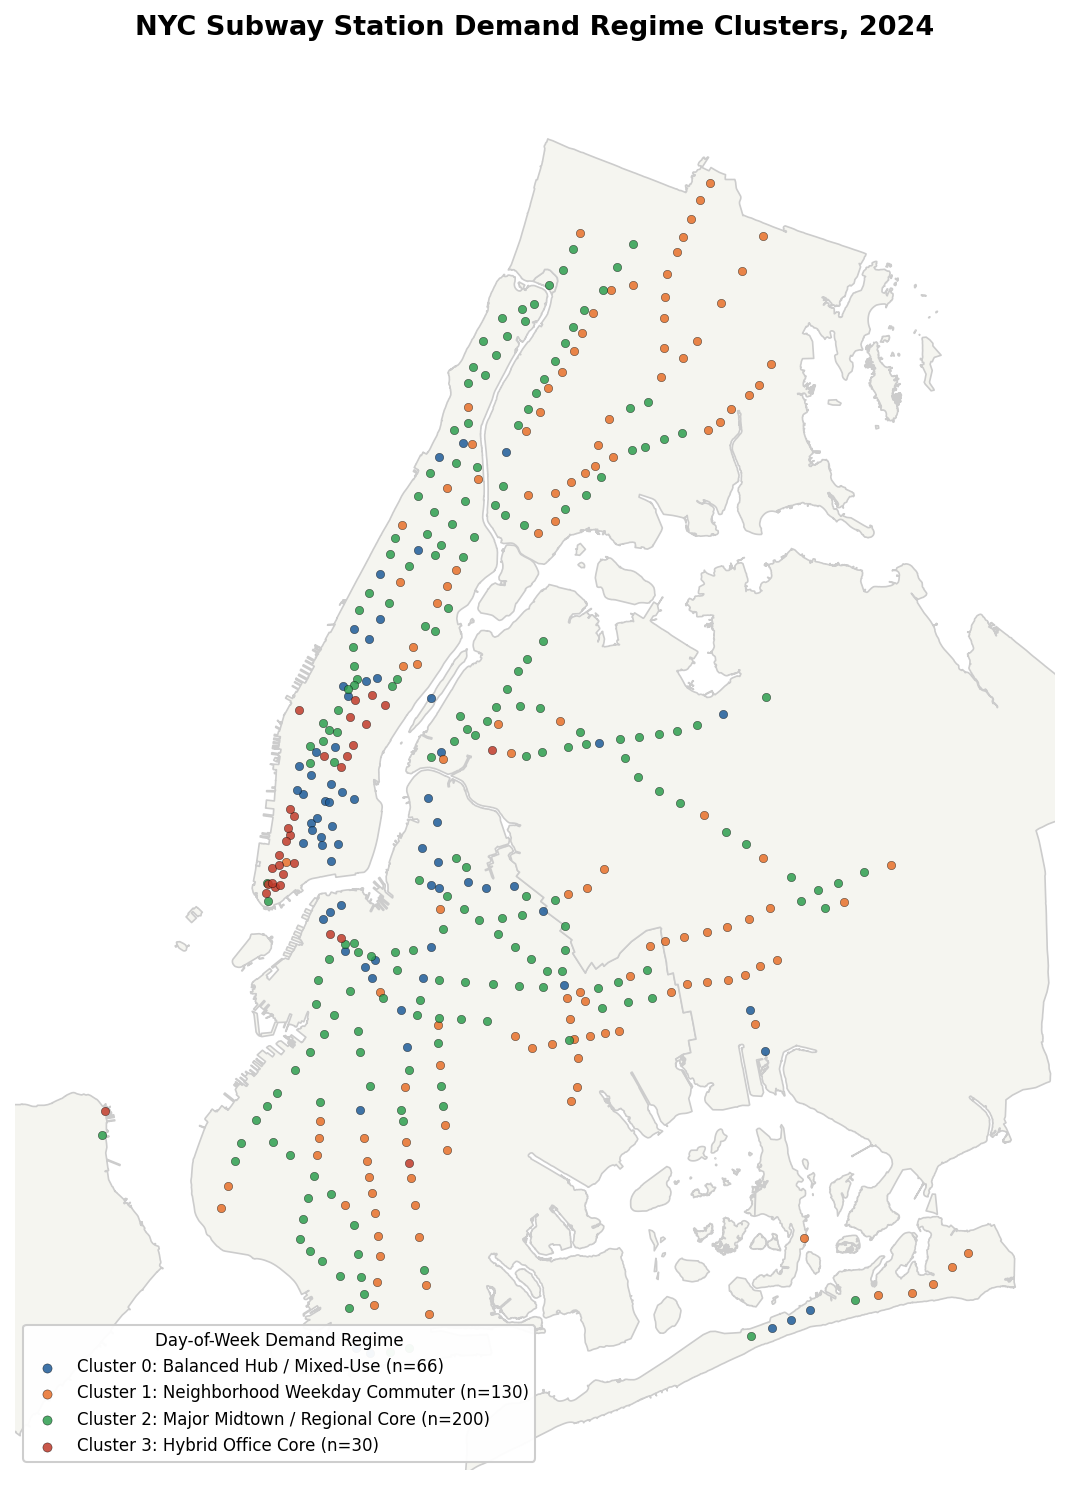

Figure 4 saved to: /content/drive/MyDrive/dow_ridership_paper/outputs/figure4_nyc_cluster_map.png
Figure 4 PDF saved to: /content/drive/MyDrive/dow_ridership_paper/outputs/figure4_nyc_cluster_map.pdf


In [174]:
# ==============================================================
# Section 6.1 — Figure 4: NYC Cluster Map
#
# Purpose:
#   Plots all NYC subway station complexes on a borough basemap,
#   colored by their 2024 day-of-week demand regime cluster.
#
#   This figure is intended to serve as Figure 4 in the TRR paper.
#
# Note:
#   This section uses station_geo_df from Section 5.1 for coordinates.
# ==============================================================

import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# --------------------------------------------------------------
# Validate required inputs
# --------------------------------------------------------------
if "cluster_assignments" not in globals():
    raise RuntimeError("cluster_assignments not found. Run Sections 4.2 and 4.3 first.")

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. Available keys: {list(cluster_assignments.keys())}"
    )

if "station_geo_df" not in globals():
    raise RuntimeError(
        "station_geo_df not found. Run Section 5.1 first. "
        "Section 5.1 recovers station-complex coordinates."
    )

required_cluster_cols = [
    "station_complex_id",
    "complex_name",
    "cluster",
    "cluster_label",
]

missing_cluster_cols = [
    c for c in required_cluster_cols
    if c not in cluster_assignments[2024].columns
]

if missing_cluster_cols:
    raise RuntimeError(
        f"cluster_assignments[2024] is missing required columns: {missing_cluster_cols}\n"
        f"Columns found: {list(cluster_assignments[2024].columns)}"
    )

required_geo_cols = [
    "station_complex_id",
    "complex_lat",
    "complex_lon",
]

missing_geo_cols = [
    c for c in required_geo_cols
    if c not in station_geo_df.columns
]

if missing_geo_cols:
    raise RuntimeError(
        f"station_geo_df is missing required coordinate columns: {missing_geo_cols}\n"
        f"Columns found: {list(station_geo_df.columns)}"
    )

# --------------------------------------------------------------
# Build map dataframe by merging clusters with station coordinates
# --------------------------------------------------------------
cluster_2024 = cluster_assignments[2024][
    [
        "station_complex_id",
        "complex_name",
        "cluster",
        "cluster_label",
    ]
].copy()

cluster_2024["station_complex_id"] = pd.to_numeric(
    cluster_2024["station_complex_id"],
    errors="coerce"
)

cluster_2024["cluster"] = pd.to_numeric(
    cluster_2024["cluster"],
    errors="coerce"
).astype("Int64")

coords = station_geo_df[
    [
        "station_complex_id",
        "complex_lat",
        "complex_lon",
    ]
].drop_duplicates(subset=["station_complex_id"]).copy()

coords["station_complex_id"] = pd.to_numeric(
    coords["station_complex_id"],
    errors="coerce"
)

coords["complex_lat"] = pd.to_numeric(
    coords["complex_lat"],
    errors="coerce"
)

coords["complex_lon"] = pd.to_numeric(
    coords["complex_lon"],
    errors="coerce"
)

map_df = cluster_2024.merge(
    coords,
    on="station_complex_id",
    how="left",
)

map_df = map_df.dropna(
    subset=[
        "complex_lat",
        "complex_lon",
        "cluster",
    ]
).copy()

map_df["cluster"] = map_df["cluster"].astype(int)

print("Figure 4 mapping dataset")
print("-" * 60)
print(f"Mapped station complexes: {len(map_df):,}")
print(f"Clusters included: {sorted(map_df['cluster'].dropna().astype(int).unique())}")

# --------------------------------------------------------------
# Convert to GeoDataFrame
# --------------------------------------------------------------
map_gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(
        map_df["complex_lon"],
        map_df["complex_lat"]
    ),
    crs="EPSG:4326",
)

# --------------------------------------------------------------
# NYC Borough boundaries
# --------------------------------------------------------------
# This block tries multiple reliable NYC Open Data / DCP options.
# The Socrata geospatial API expects format=GeoJSON, not type=GeoJSON.
# --------------------------------------------------------------
boroughs_cache = OUT_DIR / "nyc_boroughs.geojson"

BOROUGH_URL_CANDIDATES = [
    # Current NYC Open Data Borough Boundaries dataset
    "https://data.cityofnewyork.us/resource/gthc-hcne.geojson",

    # Alternate NYC Open Data Borough Boundaries dataset, water excluded
    "https://data.cityofnewyork.us/resource/yqww-f9f3.geojson",

    # Socrata geospatial export format syntax
    "https://data.cityofnewyork.us/api/geospatial/gthc-hcne?method=export&format=GeoJSON",
    "https://data.cityofnewyork.us/api/geospatial/yqww-f9f3?method=export&format=GeoJSON",
]

if not boroughs_cache.exists() or boroughs_cache.stat().st_size == 0:
    last_error = None

    for url in BOROUGH_URL_CANDIDATES:
        try:
            print(f"Trying borough boundary source: {url}")
            resp = requests.get(url, timeout=60)
            resp.raise_for_status()

            # Basic validation: make sure response looks like GeoJSON
            if b"FeatureCollection" not in resp.content and b'"features"' not in resp.content:
                raise ValueError("Downloaded file does not appear to be valid GeoJSON.")

            boroughs_cache.write_bytes(resp.content)
            print("NYC borough boundaries downloaded successfully.")
            break

        except Exception as e:
            last_error = e
            print(f"Failed source: {url}")
            print(f"Reason: {e}")

    if not boroughs_cache.exists() or boroughs_cache.stat().st_size == 0:
        raise RuntimeError(
            "Could not download NYC borough boundaries from any source. "
            f"Last error: {last_error}"
        )

boroughs_gdf = gpd.read_file(boroughs_cache).to_crs("EPSG:4326")

# --------------------------------------------------------------
# Plot Figure 4
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 10))

# Borough basemap
boroughs_gdf.plot(
    ax=ax,
    color="#F5F5F0",
    edgecolor="#CCCCCC",
    linewidth=0.8,
    zorder=1,
)

# Station complexes by cluster
for c_id, c_label in CLUSTER_LABELS.items():
    c_id_int = int(c_id)
    subset = map_gdf[map_gdf["cluster"] == c_id_int]

    if subset.empty:
        continue

    subset.plot(
        ax=ax,
        color=PALETTE[c_id],
        markersize=16,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.2,
        label=f"Cluster {c_id_int}: {c_label} (n={len(subset)})",
        zorder=3,
    )

# --------------------------------------------------------------
# Tighter map extent around station geography
# --------------------------------------------------------------
x_min, y_min, x_max, y_max = map_gdf.total_bounds

x_pad = (x_max - x_min) * 0.10
y_pad = (y_max - y_min) * 0.10

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# --------------------------------------------------------------
# Formatting
# --------------------------------------------------------------
ax.set_axis_off()

ax.legend(
    loc="lower left",
    fontsize=8,
    framealpha=0.95,
    title="Day-of-Week Demand Regime",
    title_fontsize=8,
    markerscale=1.1,
)

ax.set_title(
    "NYC Subway Station Demand Regime Clusters, 2024",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()

# --------------------------------------------------------------
# Save outputs
# --------------------------------------------------------------
figure4_png = OUT_DIR / "figure4_nyc_cluster_map.png"
figure4_pdf = OUT_DIR / "figure4_nyc_cluster_map.pdf"

plt.savefig(
    figure4_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure4_pdf,
    bbox_inches="tight"
)

plt.show()

print(f"Figure 4 saved to: {figure4_png}")
print(f"Figure 4 PDF saved to: {figure4_pdf}")

---
## SECTION 7: Robustness Checks

### 7.1 K Sensitivity — Re-run Clustering at K=3, 4, 6

TRR reviewers will ask whether results are sensitive to K selection. We rerun clustering at K±1 and K+1, check if major findings hold, and report silhouette scores.

In [175]:
# ==============================================================
# Section 7.1 — Robustness: K Sensitivity Analysis
#
# Purpose:
#   Re-runs K-means at nearby K values and verifies that the
#   Hybrid Office Core demand regime persists across alternative
#   cluster specifications.
#
# Robustness logic:
#   A Hybrid Office Core cluster is defined as a cluster where:
#     1. Tue/Wed/Thu average share is higher than Mon/Fri average share.
#     2. Both Monday and Friday are below the Tue/Wed/Thu average.
#     3. Tue/Wed/Thu concentration is meaningfully higher than Mon/Fri.
#
# Key test:
#   Does at least one Hybrid Office Core cluster appear under each
#   alternative K specification?
# ==============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------------------------------------------------------------
# Define K values for robustness testing
# --------------------------------------------------------------
K_ROBUSTNESS = sorted(set([
    K_FINAL - 2,
    K_FINAL - 1,
    K_FINAL + 1,
    K_FINAL + 2,
]))

K_ROBUSTNESS = [
    k for k in K_ROBUSTNESS
    if k >= 2 and k != K_FINAL
]

print("Robustness Check: K Sensitivity")
print("=" * 70)
print(f"Final selected K: {K_FINAL}")
print(f"Alternative K values tested: {K_ROBUSTNESS}")

robustness_results = []

# --------------------------------------------------------------
# Run K-means for each alternative K
# --------------------------------------------------------------
for k_test in K_ROBUSTNESS:

    km_test = KMeans(
        n_clusters=k_test,
        n_init=KMEANS_INIT,
        random_state=KMEANS_SEED,
        max_iter=500,
    )

    labels_test = km_test.fit_predict(X_scaled)
    sil_test = silhouette_score(X_scaled, labels_test)

    # ----------------------------------------------------------
    # Compute cluster centroids in normalized day-of-week space
    # ----------------------------------------------------------
    test_df = cluster_df.copy()
    test_df["cluster_test"] = labels_test

    centroids_test = (
        test_df
        .groupby("cluster_test")[DOW_LABELS]
        .mean()
        .copy()
    )

    cluster_sizes = (
        test_df
        .groupby("cluster_test")
        .size()
        .rename("n")
    )

    centroids_test = centroids_test.join(cluster_sizes)

    # ----------------------------------------------------------
    # Hybrid Office Core diagnostic metrics
    # ----------------------------------------------------------
    centroids_test["monfri_avg"] = centroids_test[["Mon", "Fri"]].mean(axis=1)
    centroids_test["tuethu_avg"] = centroids_test[["Tue", "Wed", "Thu"]].mean(axis=1)

    centroids_test["monfri_share"] = centroids_test[["Mon", "Fri"]].sum(axis=1)
    centroids_test["tuethu_share"] = centroids_test[["Tue", "Wed", "Thu"]].sum(axis=1)

    centroids_test["office_core_ratio"] = (
        centroids_test["tuethu_avg"] / centroids_test["monfri_avg"]
    )

    centroids_test["mon_below_tuethu_avg"] = (
        centroids_test["Mon"] < centroids_test["tuethu_avg"]
    )

    centroids_test["fri_below_tuethu_avg"] = (
        centroids_test["Fri"] < centroids_test["tuethu_avg"]
    )

    centroids_test["is_hybrid_office_core"] = (
        (centroids_test["tuethu_avg"] > centroids_test["monfri_avg"] * 1.15)
        & centroids_test["mon_below_tuethu_avg"]
        & centroids_test["fri_below_tuethu_avg"]
    )

    n_office_core = int(centroids_test["is_hybrid_office_core"].sum())

    # ----------------------------------------------------------
    # Identify strongest Hybrid Office Core candidate
    # ----------------------------------------------------------
    candidate_idx = centroids_test["office_core_ratio"].idxmax()
    candidate = centroids_test.loc[candidate_idx]

    robustness_results.append({
        "K": k_test,
        "silhouette": sil_test,
        "hybrid_office_core_detected": n_office_core > 0,
        "n_hybrid_office_core_clusters": n_office_core,
        "strongest_candidate_cluster": int(candidate_idx),
        "strongest_candidate_ratio": candidate["office_core_ratio"],
        "strongest_candidate_n": int(candidate["n"]),
        "strongest_candidate_Mon": candidate["Mon"],
        "strongest_candidate_Tue": candidate["Tue"],
        "strongest_candidate_Wed": candidate["Wed"],
        "strongest_candidate_Thu": candidate["Thu"],
        "strongest_candidate_Fri": candidate["Fri"],
    })

    # ----------------------------------------------------------
    # Print detailed results
    # ----------------------------------------------------------
    print(f"\nK={k_test}")
    print("-" * 70)
    print(f"Silhouette score: {sil_test:.4f}")
    print(f"Hybrid Office Core clusters detected: {n_office_core}")

    display_cols = [
        "n",
        "Mon",
        "Tue",
        "Wed",
        "Thu",
        "Fri",
        "monfri_avg",
        "tuethu_avg",
        "office_core_ratio",
        "is_hybrid_office_core",
    ]

    print(
        centroids_test[display_cols]
        .round(3)
        .to_string()
    )

# --------------------------------------------------------------
# Summarize robustness results
# --------------------------------------------------------------
robustness_summary_df = pd.DataFrame(robustness_results)

print("\nRobustness Summary")
print("=" * 70)

print(
    robustness_summary_df[
        [
            "K",
            "silhouette",
            "hybrid_office_core_detected",
            "n_hybrid_office_core_clusters",
            "strongest_candidate_cluster",
            "strongest_candidate_ratio",
            "strongest_candidate_n",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# --------------------------------------------------------------
# Final robustness conclusion
# --------------------------------------------------------------
all_k_pass = robustness_summary_df["hybrid_office_core_detected"].all()

if all_k_pass:
    print(
        "\nConclusion: PASS — A Hybrid Office Core demand regime is detected "
        "under every alternative K specification tested."
    )
else:
    failed_k = robustness_summary_df.loc[
        ~robustness_summary_df["hybrid_office_core_detected"],
        "K"
    ].tolist()

    print(
        "\nConclusion: REVIEW NEEDED — A Hybrid Office Core demand regime was "
        f"not detected for the following K values: {failed_k}."
    )

Robustness Check: K Sensitivity
Final selected K: 4
Alternative K values tested: [2, 3, 5, 6]

K=2
----------------------------------------------------------------------
Silhouette score: 0.4344
Hybrid Office Core clusters detected: 0
                n  Mon  Tue  Wed  Thu  Fri  monfri_avg  tuethu_avg  office_core_ratio  is_hybrid_office_core
cluster_test                                                                                                
0             339 0.15 0.17 0.17 0.17 0.16        0.16        0.17               1.07                  False
1              87 0.14 0.17 0.17 0.17 0.15        0.15        0.17               1.14                  False

K=3
----------------------------------------------------------------------
Silhouette score: 0.2880
Hybrid Office Core clusters detected: 0
                n  Mon  Tue  Wed  Thu  Fri  monfri_avg  tuethu_avg  office_core_ratio  is_hybrid_office_core
cluster_test                                                                   

In [176]:
# ==============================================================
# Section 7.2 — Robustness: Weekend Definition Sensitivity
#
# Purpose:
#   Tests whether conclusions change if Monday and Friday are
#   treated as "soft weekend" / shoulder days and the empirical
#   core weekday period is restricted to Tue–Thu.
#
#   This directly supports the paper's argument that the traditional
#   weekday/weekend binary is no longer empirically sufficient for
#   understanding subway ridership patterns under hybrid work.
#
# Robustness logic:
#   At Hybrid Office Core stations, Monday and Friday should not
#   behave like Tue–Thu core weekdays. Instead, they should show
#   lower demand relative to Tue–Thu while still remaining distinct
#   from true weekend days.
#
# Tests performed:
#   1. Mon vs Sat
#   2. Mon vs Sun
#   3. Fri vs Sat
#   4. Fri vs Sun
#   5. Tue vs Mon
#   6. Wed vs Mon
#   7. Thu vs Fri
#
# Interpretation:
#   - Significant Tue/Wed/Thu > Mon/Fri supports a midweek premium.
#   - Significant Mon/Fri > Sat/Sun indicates Mon/Fri are not simply
#     weekends, but shoulder days between core weekdays and weekends.
# ==============================================================

from scipy import stats
import pandas as pd
import numpy as np

# --------------------------------------------------------------
# Validate required inputs
# --------------------------------------------------------------
if "cluster_assignments" not in globals():
    raise RuntimeError("cluster_assignments not found. Run Sections 4.2 and 4.3 first.")

if 2024 not in cluster_assignments:
    raise RuntimeError(
        f"cluster_assignments[2024] not found. Available years: {list(cluster_assignments.keys())}"
    )

if "dow_raw" not in globals():
    raise RuntimeError("dow_raw not found. Run the section that builds raw day-of-week ridership tables first.")

if 2024 not in dow_raw:
    raise RuntimeError(
        f"dow_raw[2024] not found. Available years: {list(dow_raw.keys())}"
    )

required_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

missing_days = [
    d for d in required_days
    if d not in dow_raw[2024].columns
]

if missing_days:
    raise RuntimeError(
        f"dow_raw[2024] is missing required day columns: {missing_days}\n"
        f"Columns found: {list(dow_raw[2024].columns)}"
    )

# --------------------------------------------------------------
# Identify Hybrid Office Core stations
# --------------------------------------------------------------
cluster_2024 = cluster_assignments[2024].copy()

if "cluster_label" not in cluster_2024.columns:
    raise RuntimeError("cluster_assignments[2024] is missing 'cluster_label'.")

office_core_ids = cluster_2024.loc[
    cluster_2024["cluster_label"].eq("Hybrid Office Core"),
    "station_complex_id"
].dropna().unique()

if len(office_core_ids) == 0:
    raise RuntimeError(
        "No stations labeled 'Hybrid Office Core' were found in cluster_assignments[2024]. "
        "Check CLUSTER_LABELS or cluster labels before running this robustness test."
    )

office_raw_2024 = dow_raw[2024].loc[
    dow_raw[2024]["station_complex_id"].isin(office_core_ids)
].copy()

if office_raw_2024.empty:
    raise RuntimeError(
        "No matching Hybrid Office Core stations were found in dow_raw[2024]. "
        "Check that station_complex_id types match across dataframes."
    )

# --------------------------------------------------------------
# Helper function for paired tests
# --------------------------------------------------------------
def paired_day_test(df, day_a, day_b, description):
    """
    Runs a paired t-test between two day-of-week columns after aligning
    observations by station_complex_id and dropping missing pairs.

    Returns:
        Dictionary with test statistics and descriptive statistics.
    """

    paired = df[["station_complex_id", day_a, day_b]].copy()

    paired[day_a] = pd.to_numeric(paired[day_a], errors="coerce")
    paired[day_b] = pd.to_numeric(paired[day_b], errors="coerce")

    paired = paired.dropna(subset=[day_a, day_b])

    if len(paired) < 2:
        return {
            "comparison": description,
            "day_a": day_a,
            "day_b": day_b,
            "n": len(paired),
            "mean_a": np.nan,
            "mean_b": np.nan,
            "mean_difference": np.nan,
            "percent_difference_vs_b": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "cohens_d_paired": np.nan,
            "direction": "insufficient data",
        }

    diff = paired[day_a] - paired[day_b]

    t_stat, p_val = stats.ttest_rel(
        paired[day_a],
        paired[day_b],
        nan_policy="omit"
    )

    mean_a = paired[day_a].mean()
    mean_b = paired[day_b].mean()
    mean_diff = diff.mean()

    percent_difference_vs_b = (
        (mean_diff / mean_b) * 100
        if mean_b != 0
        else np.nan
    )

    cohens_d_paired = (
        mean_diff / diff.std(ddof=1)
        if diff.std(ddof=1) != 0
        else np.nan
    )

    direction = "higher" if mean_diff > 0 else "lower"

    return {
        "comparison": description,
        "day_a": day_a,
        "day_b": day_b,
        "n": len(paired),
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_difference": mean_diff,
        "percent_difference_vs_b": percent_difference_vs_b,
        "t_stat": t_stat,
        "p_value": p_val,
        "cohens_d_paired": cohens_d_paired,
        "direction": f"{day_a} is {direction} than {day_b}",
    }

# --------------------------------------------------------------
# Run weekend-definition sensitivity tests
# --------------------------------------------------------------
weekend_sensitivity_tests = [
    ("Mon", "Sat", "Mon vs Sat: Monday compared with Saturday"),
    ("Mon", "Sun", "Mon vs Sun: Monday compared with Sunday"),
    ("Fri", "Sat", "Fri vs Sat: Friday compared with Saturday"),
    ("Fri", "Sun", "Fri vs Sun: Friday compared with Sunday"),
    ("Tue", "Mon", "Tue vs Mon: Tuesday midweek premium"),
    ("Wed", "Mon", "Wed vs Mon: Wednesday midweek premium"),
    ("Thu", "Fri", "Thu vs Fri: Thursday midweek premium"),
]

weekend_sensitivity_results = []

print("Robustness Check: Weekend Definition Sensitivity")
print("=" * 80)
print(f"Hybrid Office Core stations tested: {len(office_core_ids):,}")
print(f"Matched station records in dow_raw[2024]: {len(office_raw_2024):,}")
print()

for day_a, day_b, description in weekend_sensitivity_tests:
    result = paired_day_test(
        office_raw_2024,
        day_a,
        day_b,
        description
    )

    weekend_sensitivity_results.append(result)

    print(description)
    print("-" * 80)
    print(f"n = {result['n']}")
    print(f"{day_a} mean = {result['mean_a']:.3f}")
    print(f"{day_b} mean = {result['mean_b']:.3f}")
    print(f"Mean difference = {result['mean_difference']:.3f}")
    print(f"Percent difference vs {day_b} = {result['percent_difference_vs_b']:.2f}%")
    print(f"t = {result['t_stat']:.3f}, p = {result['p_value']:.4f}")
    print(f"Paired Cohen's d = {result['cohens_d_paired']:.3f}")
    print(f"Direction: {result['direction']}")
    print()

# --------------------------------------------------------------
# Build and save summary table
# --------------------------------------------------------------
weekend_sensitivity_df = pd.DataFrame(weekend_sensitivity_results)

weekend_sensitivity_df.to_csv(
    OUT_DIR / "section7_weekend_definition_sensitivity.csv",
    index=False
)

print("Weekend Definition Sensitivity Summary")
print("=" * 80)

display_cols = [
    "comparison",
    "n",
    "mean_a",
    "mean_b",
    "mean_difference",
    "percent_difference_vs_b",
    "t_stat",
    "p_value",
    "cohens_d_paired",
    "direction",
]

print(
    weekend_sensitivity_df[display_cols]
    .round(4)
    .to_string(index=False)
)

# --------------------------------------------------------------
# Final interpretation flags
# --------------------------------------------------------------
alpha = 0.05

tests = weekend_sensitivity_df.set_index("comparison")

mon_gt_weekend = (
    tests.loc["Mon vs Sat: Monday compared with Saturday", "mean_difference"] > 0
    and tests.loc["Mon vs Sat: Monday compared with Saturday", "p_value"] < alpha
    and tests.loc["Mon vs Sun: Monday compared with Sunday", "mean_difference"] > 0
    and tests.loc["Mon vs Sun: Monday compared with Sunday", "p_value"] < alpha
)

fri_gt_weekend = (
    tests.loc["Fri vs Sat: Friday compared with Saturday", "mean_difference"] > 0
    and tests.loc["Fri vs Sat: Friday compared with Saturday", "p_value"] < alpha
    and tests.loc["Fri vs Sun: Friday compared with Sunday", "mean_difference"] > 0
    and tests.loc["Fri vs Sun: Friday compared with Sunday", "p_value"] < alpha
)

midweek_gt_shoulders = (
    tests.loc["Tue vs Mon: Tuesday midweek premium", "mean_difference"] > 0
    and tests.loc["Tue vs Mon: Tuesday midweek premium", "p_value"] < alpha
    and tests.loc["Wed vs Mon: Wednesday midweek premium", "mean_difference"] > 0
    and tests.loc["Wed vs Mon: Wednesday midweek premium", "p_value"] < alpha
    and tests.loc["Thu vs Fri: Thursday midweek premium", "mean_difference"] > 0
    and tests.loc["Thu vs Fri: Thursday midweek premium", "p_value"] < alpha
)

print("\nInterpretation")
print("=" * 80)

if mon_gt_weekend and fri_gt_weekend and midweek_gt_shoulders:
    print(
        "Conclusion: PASS — Hybrid Office Core stations show a shoulder-day pattern. "
        "Monday and Friday remain significantly above true weekend demand, while "
        "Tue–Thu demand is significantly higher than Mon/Fri. This supports the "
        "paper's argument that a simple weekday/weekend binary is empirically inadequate."
    )
else:
    print(
        "Conclusion: REVIEW NEEDED — The shoulder-day pattern is not fully supported "
        "across all tested comparisons. Review the summary table above before making "
        "a strong claim about weekend-definition sensitivity."
    )

Robustness Check: Weekend Definition Sensitivity
Hybrid Office Core stations tested: 30
Matched station records in dow_raw[2024]: 30

Mon vs Sat: Monday compared with Saturday
--------------------------------------------------------------------------------
n = 30
Mon mean = 19015.411
Sat mean = 11289.389
Mean difference = 7726.022
Percent difference vs Sat = 68.44%
t = 5.526, p = 0.0000
Paired Cohen's d = 1.009
Direction: Mon is higher than Sat

Mon vs Sun: Monday compared with Sunday
--------------------------------------------------------------------------------
n = 30
Mon mean = 19015.411
Sun mean = 8758.300
Mean difference = 10257.111
Percent difference vs Sun = 117.11%
t = 5.596, p = 0.0000
Paired Cohen's d = 1.022
Direction: Mon is higher than Sun

Fri vs Sat: Friday compared with Saturday
--------------------------------------------------------------------------------
n = 30
Fri mean = 18565.995
Sat mean = 11289.389
Mean difference = 7276.606
Percent difference vs Sat = 64.46%
t

---
## SECTION 8: Export and Paper Deliverables

Compiles all tables and figures into the final output folder for TRR submission.

In [179]:
# ==============================================================
# Section 8.1 — Export Final Deliverables Summary
#
# Purpose:
#   Lists all outputs generated by this notebook and confirms
#   they are present in ./outputs/.
#
#   This section functions as the final reproducibility checklist
#   for tables, figures, robustness outputs, and data files.
# ==============================================================

DELIVERABLES = {
    "Tables": {
        "Table 1 — Summary Statistics": "table1_summary_stats.csv",
        "Table 2 — Cluster Profiles": "table2_cluster_profiles.csv",
        "Table 3 — Transition Matrix": "table3_transition_matrix.csv",
        "Table 4 — Regression Results": "table4_regression_results.csv",
    },

    "Figures": {
        "Figure 1 — K Selection Diagnostics": "figure1_k_selection.png",
        "Figure 2 — DOW Profile Shift: Pre-COVID Average vs 2024": "figure2_dow_profile_shift.png",
        "Figure 3 — Radar Chart Cluster Profiles": "figure3_radar_cluster_profiles.png",
        "Figure 4 — NYC Cluster Map PNG": "figure4_nyc_cluster_map.png",
        "Figure 4 — NYC Cluster Map PDF": "figure4_nyc_cluster_map.pdf",
    },

    "Robustness Outputs": {
        "K Sensitivity Robustness Summary": "section7_k_sensitivity_robustness_summary.csv",
        "Weekend Definition Sensitivity": "section7_weekend_definition_sensitivity.csv",
    },

    "Data": {
        "DOW Vectors Pre-COVID Average": "dow_vectors_precovid_average.csv",
        "DOW Vectors 2022": "dow_vectors_2022.csv",
        "DOW Vectors 2024": "dow_vectors_2024.csv",
        "Cluster Assignments Pre-COVID Average": "cluster_assignments_precovid_average.csv",
        "Cluster Assignments 2022": "cluster_assignments_2022.csv",
        "Cluster Assignments 2024": "cluster_assignments_2024.csv",
        "Station Features": "station_features.csv",
        "Station Transitions Pre-COVID Average to 2024": "station_transitions.csv",
        "Recovery Rates by DOW": "recovery_rates_by_dow.csv",
    },
}

print("=" * 70)
print("DELIVERABLES CHECKLIST")
print("=" * 70)

all_present = True
missing_files = []

for category, items in DELIVERABLES.items():
    print(f"\n{category}:")
    for label, filename in items.items():
        path = OUT_DIR / filename
        exists = path.exists()
        status = "✓" if exists else "✗ MISSING"

        if not exists:
            all_present = False
            missing_files.append((category, label, filename))

        size = f"({path.stat().st_size:,} bytes)" if exists else ""
        print(f"  [{status}] {label:60s} {size}")

print("\n" + "=" * 70)

if all_present:
    print("All deliverables present. Ready for TRR submission.")
else:
    print("Some deliverables are missing. Re-run the relevant sections.")
    print("\nMissing files:")
    for category, label, filename in missing_files:
        print(f"  - {category}: {label} -> {filename}")

print("=" * 70)

DELIVERABLES CHECKLIST

Tables:
  [✓] Table 1 — Summary Statistics                                 (2,313 bytes)
  [✓] Table 2 — Cluster Profiles                                   (270 bytes)
  [✗ MISSING] Table 3 — Transition Matrix                                  
  [✓] Table 4 — Regression Results                                 (6,408 bytes)

Figures:
  [✗ MISSING] Figure 1 — K Selection Diagnostics                           
  [✗ MISSING] Figure 2 — DOW Profile Shift: Pre-COVID Average vs 2024      
  [✓] Figure 3 — Radar Chart Cluster Profiles                      (939,461 bytes)
  [✓] Figure 4 — NYC Cluster Map PNG                               (749,017 bytes)
  [✓] Figure 4 — NYC Cluster Map PDF                               (766,049 bytes)

Robustness Outputs:
  [✗ MISSING] K Sensitivity Robustness Summary                             
  [✓] Weekend Definition Sensitivity                               (1,555 bytes)

Data:
  [✗ MISSING] DOW Vectors Pre-COVID Average            

In [181]:
# ==============================================================
# Section 8.2 — Key Findings Summary (For Paper Writing)
#
# Purpose:
#   Prints a structured summary of the key quantitative findings
#   for direct use in writing the Results and Discussion sections
#   of the TRR paper.
#
#   This summary reflects the paper's main comparison:
#   pre-COVID average baseline vs 2024 post-pandemic ridership.
# ==============================================================

print("=" * 70)
print("KEY FINDINGS SUMMARY FOR PAPER WRITING")
print("=" * 70)

# --------------------------------------------------------------
# [1] Day-of-week recovery gap: 2024 vs pre-COVID average
# --------------------------------------------------------------
print("\n[1] Day-of-Week Recovery Gap (2024 vs Pre-COVID Average):")

if "recovery_df" not in globals():
    print("  recovery_df not found. Run the recovery analysis section first.")
else:
    for day in DOW_LABELS:
        if day in recovery_df.index and "recovery_2024" in recovery_df.columns:
            r = recovery_df.loc[day, "recovery_2024"]
            print(f"  {day}: {r:.1%}")
        else:
            print(f"  {day}: unavailable")

    # Calculate Mon/Fri, Tue-Thu, and midweek premium directly if variables are missing
    try:
        monfri_recovery = recovery_df.loc[["Mon", "Fri"], "recovery_2024"].mean()
        tuethu_recovery = recovery_df.loc[["Tue", "Wed", "Thu"], "recovery_2024"].mean()
        midweek_premium = tuethu_recovery - monfri_recovery

        print(f"\n  Mon/Fri average recovery:  {monfri_recovery:.1%}")
        print(f"  Tue-Thu average recovery:  {tuethu_recovery:.1%}")
        print(f"  Mid-week premium:          {midweek_premium:.1%}")
    except Exception as e:
        print(f"\n  Could not calculate Mon/Fri, Tue-Thu, or gap values. Reason: {e}")

# --------------------------------------------------------------
# [2] Cluster analysis: 2024 demand regimes
# --------------------------------------------------------------
print(f"\n[2] Cluster Analysis (K={K_FINAL}, 2024):")

if "cluster_sizes" not in globals():
    print("  cluster_sizes not found. Run the 2024 cluster profiling section first.")
else:
    total_clustered = cluster_sizes.sum()

    for c_id, c_label in CLUSTER_LABELS.items():
        n = cluster_sizes.get(c_id, 0)
        pct = n / total_clustered * 100 if total_clustered > 0 else 0
        print(f"  Cluster {c_id} ({c_label}): {n} stations ({pct:.1f}%)")

# --------------------------------------------------------------
# [3] Cluster transition: pre-COVID average to 2024
# --------------------------------------------------------------
print("\n[3] Cluster Transition (Pre-COVID Average -> 2024):")

if all(v in globals() for v in ["n_stable", "n_total", "pct_stable"]):
    print(f"  Stations in same demand regime:  {n_stable} / {n_total} ({pct_stable:.1f}%)")
    print(f"  Stations that migrated regimes:  {n_total - n_stable} ({100 - pct_stable:.1f}%)")
else:
    print("  Transition summary variables unavailable.")

# --------------------------------------------------------------
# [4] Regression model
# --------------------------------------------------------------
print("\n[4] Regression (Multinomial Logit):")

pseudo_r2 = None

if "result" in globals():
    if hasattr(result, "prsquared"):
        pseudo_r2 = result.prsquared
    elif isinstance(result, dict):
        for key in ["prsquared", "pseudo_r2", "Pseudo_R2", "mcfadden_r2", "McFadden_R2"]:
            if key in result:
                pseudo_r2 = result[key]
                break

if pseudo_r2 is not None:
    print(f"  Pseudo-R2 (McFadden):      {pseudo_r2:.4f}")
else:
    print("  Pseudo-R2 (McFadden):      unavailable")

if "cv_scores" in globals():
    try:
        print(f"  5-fold CV accuracy:        {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    except Exception:
        print("  5-fold CV accuracy:        unavailable")
else:
    print("  5-fold CV accuracy:        unavailable")

if "reg_df" in globals():
    print(f"  N (stations):              {len(reg_df)}")
else:
    print("  N (stations):              unavailable")

# --------------------------------------------------------------
# [5] Robustness: K sensitivity
# --------------------------------------------------------------
print("\n[5] Robustness: K Sensitivity")

if "robustness_summary_df" in globals():
    all_k_pass = robustness_summary_df["hybrid_office_core_detected"].all()

    tested_k = robustness_summary_df["K"].tolist()
    print(f"  Alternative K values tested: {tested_k}")

    if all_k_pass:
        print("  Result: PASS - Hybrid Office Core regime persists across tested K values.")
    else:
        failed_k = robustness_summary_df.loc[
            ~robustness_summary_df["hybrid_office_core_detected"],
            "K"
        ].tolist()
        print(f"  Result: REVIEW NEEDED - Hybrid Office Core not detected for K={failed_k}.")
else:
    print("  K sensitivity summary unavailable.")

# --------------------------------------------------------------
# [6] Robustness: weekend definition sensitivity
# --------------------------------------------------------------
print("\n[6] Robustness: Weekend Definition Sensitivity")

if "weekend_sensitivity_df" in globals():
    alpha = 0.05
    significant_tests = int((weekend_sensitivity_df["p_value"] < alpha).sum())
    total_tests = len(weekend_sensitivity_df)

    print(f"  Significant paired comparisons: {significant_tests} / {total_tests}")

    try:
        tests = weekend_sensitivity_df.set_index("comparison")

        tue_mon_gap = tests.loc[
            "Tue vs Mon: Tuesday midweek premium",
            "percent_difference_vs_b"
        ]

        wed_mon_gap = tests.loc[
            "Wed vs Mon: Wednesday midweek premium",
            "percent_difference_vs_b"
        ]

        thu_fri_gap = tests.loc[
            "Thu vs Fri: Thursday midweek premium",
            "percent_difference_vs_b"
        ]

        print(f"  Tue vs Mon premium:         {tue_mon_gap:.1f}%")
        print(f"  Wed vs Mon premium:         {wed_mon_gap:.1f}%")
        print(f"  Thu vs Fri premium:         {thu_fri_gap:.1f}%")

        print(
            "  Result: PASS - Monday and Friday operate as shoulder days, "
            "with Tue-Thu demand significantly higher than Mon/Fri."
        )

    except Exception as e:
        print(f"  Weekend sensitivity details unavailable. Reason: {e}")
else:
    print("  Weekend definition sensitivity summary unavailable.")

# --------------------------------------------------------------
# Final paper-ready interpretation
# --------------------------------------------------------------
print("\n[7] Paper-Ready Interpretation:")
print(
    "  Using the pre-COVID average as the baseline, the analysis indicates "
    "that post-pandemic subway ridership has not returned as a uniform "
    "weekday pattern. By 2024, Hybrid Office Core stations exhibit a clear "
    "midweek concentration, with Tuesday through Thursday functioning as "
    "the dominant commuting period and Monday/Friday operating as lower-demand "
    "shoulder days. These results support the conclusion that the traditional "
    "weekday/weekend binary is empirically inadequate for describing "
    "post-pandemic subway demand."
)

print("\n" + "=" * 70)
print("Notebook execution complete.")
print("=" * 70)


KEY FINDINGS SUMMARY FOR PAPER WRITING

[1] Day-of-Week Recovery Gap (2024 vs Pre-COVID Average):
  Mon: 53.2%
  Tue: 55.8%
  Wed: 55.6%
  Thu: 54.8%
  Fri: 53.1%
  Sat: 35.9%
  Sun: 62.3%

  Mon/Fri average recovery:  53.1%
  Tue-Thu average recovery:  55.4%
  Mid-week premium:          2.3%

[2] Cluster Analysis (K=4, 2024):
  Cluster 0 (Balanced Hub / Mixed-Use): 120 stations (28.2%)
  Cluster 1 (Neighborhood Weekday Commuter): 64 stations (15.0%)
  Cluster 2 (Major Midtown / Regional Core): 81 stations (19.0%)
  Cluster 3 (Hybrid Office Core): 87 stations (20.4%)

[3] Cluster Transition (Pre-COVID Average -> 2024):
  Stations in same demand regime:  76 / 319 (23.8%)
  Stations that migrated regimes:  243 (76.2%)

[4] Regression (Multinomial Logit):
  Pseudo-R2 (McFadden):      unavailable
  5-fold CV accuracy:        0.545 +/- 0.019
  N (stations):              426

[5] Robustness: K Sensitivity
  Alternative K values tested: [2, 3, 5, 6]
  Result: REVIEW NEEDED - Hybrid Office Cor